# Anticipez les besoins en consommation de bâtiments de la ville de Seattle

Seattle vise la neutralité carbone en 2050 et doit connaître la consommation et les émissions
de son parc **non résidentiel**. Les relevés terrain sont coûteux : l'objectif est de les
estimer pour les bâtiments non mesurés, à partir des seules caractéristiques structurelles des
registres municipaux.

**Deux cibles :** `SiteEnergyUse(kBtu)` (énergie, kBtu/an) et `TotalGHGEmissions` (émissions,
t CO₂e/an).

[Seattle ENERGY Benchmarking Analysis Report on 2016 DATA](https://seattle.gov/documents/Departments/OSE/Seattle%20Energy%20Benchmarking%20Analysis%202016%20for%20web.pdf)

# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
!wget https://s3.eu-west-1.amazonaws.com/course.oc-static.com/projects/Data_Scientist_P4/2016_Building_Energy_Benchmarking.csv

--2026-09-17 13:05:57--  https://s3.eu-west-1.amazonaws.com/course.oc-static.com/projects/Data_Scientist_P4/2016_Building_Energy_Benchmarking.csv
Resolving s3.eu-west-1.amazonaws.com (s3.eu-west-1.amazonaws.com)... 52.92.32.8, 3.5.75.35, 3.5.71.67, ...
Connecting to s3.eu-west-1.amazonaws.com (s3.eu-west-1.amazonaws.com)|52.92.32.8|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1232057 (1.2M) [text/csv]
Saving to: ‘2016_Building_Energy_Benchmarking.csv’

2016_Building_Energ 100%[===================>]   1.17M  2.22MB/s    in 0.5s    

2026-09-17 13:05:59 (2.22 MB/s) - ‘2016_Building_Energy_Benchmarking.csv’ saved [1232057/1232057]



### Analyse Exploratoire

## Glossaire du Dataset : Seattle Building Energy Benchmarking

Ce dataset contient les données de consommation énergétique et les caractéristiques des bâtiments non-résidentiels et multifamiliaux de la ville de Seattle, collectées dans le cadre de leur obligation annuelle de déclaration (benchmarking).

Voici une description claire et concise de ses principales features (colonnes) :

### 📍 1. Identification & Localisation
* **`OSEBuildingID`** : Identifiant unique attribué par le bureau de l'environnement de Seattle (OSE) à chaque propriété pour le suivi.
* **`DataYear`** : Année civile de l'enregistrement des données de consommation.
* **`BuildingName` / `PropertyName`** : Nom usuel ou officiel du bâtiment/de la propriété.
* **`TaxParcelIdentificationNumber`** : Numéro d'identification unique de la parcelle cadastrale (King County PIN).
* **`Address`, `City`, `State`, `ZipCode`** : Adresse postale complète du bâtiment.
* **`Latitude`, `Longitude`** : Coordonnées géographiques de la propriété.
* **`Neighborhood`** : Quartier de la ville où se situe le bâtiment.
* **`CouncilDistrictCode`** : District du conseil municipal dont dépend la propriété.

### 🏢 2. Caractéristiques Structurelles du Bâtiment
* **`BuildingType`** : Catégorisation globale du type de bâtiment (ex : *Multifamily*, *NonResidential*, *Campus*).
* **`PrimaryPropertyType`** : Fonction ou usage principal du bâtiment (ex : *Office*, *Retail Store*, *Hotel*, *Hospital*).
* **`YearBuilt`** : Année de construction du bâtiment.
* **`NumberofBuildings`** : Nombre de bâtiments distincts inclus dans la déclaration de la propriété.
* **`NumberofFloors`** : Nombre d'étages de l'édifice (au-dessus du niveau du sol).

### 📐 3. Surfaces (Gross Floor Area - GFA)
* *Note : Les surfaces sont généralement exprimées en pieds carrés (Square Feet - sf).*
* **`PropertyGFATotal`** : Surface brute totale du bâtiment (incluant les parkings).
* **`PropertyGFAParking`** : Surface brute dédiée au stationnement.
* **`PropertyGFABuilding(s)`** : Surface brute du bâtiment hors parkings (Total GFA - Parking GFA).

### 🏢 4. Répartition des Usages (Property Use Types)
* **`ListOfAllPropertyUseTypes`** : Liste complète des différents usages présents au sein du bâtiment (ex : bureaux, commerces, parkings).
* **`LargestPropertyUseType`** : L'usage qui occupe la plus grande surface dans le bâtiment.
* **`LargestPropertyUseTypeGFA`** : Surface allouée à ce premier usage principal.
* **`SecondLargestPropertyUseType`** / **`SecondLargestPropertyUseTypeGFA`** : Deuxième usage le plus important et sa surface.
* **`ThirdLargestPropertyUseType`** / **`ThirdLargestPropertyUseTypeGFA`** : Troisième usage le plus important et sa surface.

### ⚡ 5. Indicateurs de Performance Énergétique (Métriques EUI)
* *L'EUI (Energy Use Intensity) est la consommation d'énergie divisée par la surface. C'est l'indicateur clé pour comparer des bâtiments de tailles différentes.*
* **`ENERGYSTARScore`** : Note de 1 à 100 évaluant l'efficacité énergétique par rapport à des bâtiments similaires au niveau national (100 = très performant).
* **`SiteEUI(kBtu/sf)`** : Intensité énergétique réelle consommée sur place (sur le "site").
* **`SiteEUIWN(kBtu/sf)`** : Site EUI *Weather Normalized* (ajusté pour lisser les variations météorologiques annuelles, ex : hivers particulièrement froids).
* **`SourceEUI(kBtu/sf)`** : Intensité énergétique à la "source" (inclut l'énergie consommée sur site + les pertes dues à la production et la distribution d'énergie).
* **`SourceEUIWN(kBtu/sf)`** : Source EUI ajusté selon la météo.

### 🛢️ 6. Consommations Totales par Type d'Énergie
* **`SiteEnergyUse(kBtu)`** : Quantité totale d'énergie consommée par le bâtiment sur l'année.
* **`SiteEnergyUseWN(kBtu)`** : Consommation totale ajustée selon la météo.
* **`SteamUse(kBtu)`** : Quantité de vapeur consommée (via réseau de chaleur urbain).
* **`Electricity(kWh)`** / **`Electricity(kBtu)`** : Consommation électrique annuelle (exprimée en kilowattheures ou convertie en kilo-BTU).
* **`NaturalGas(therms)`** / **`NaturalGas(kBtu)`** : Consommation de gaz naturel.


### 🌍 7. Émissions de Gaz à Effet de Serre (GES)
* **`GHGEmissions(MetricTonsCO2e)`** : Émissions totales annuelles de gaz à effet de serre du bâtiment (en tonnes d'équivalent CO2).
* **`GHGEmissionsIntensity(kgCO2e/ft2)`** : Intensité des émissions de GES rapportée à la surface du bâtiment (kilos de CO2 par pied carré).

### 📋 8. Informations Administratives
* **`ComplianceStatus`** : Indique si le propriétaire a respecté l'obligation de déclaration (ex : *Compliant*, *Non-Compliant*, *Missing Data*).
* **`DefaultData`** : Booléen ou indicateur signalant si le déclarant a utilisé des valeurs par défaut au lieu de données réelles pour certaines caractéristiques.

In [3]:
building_consumption = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

In [4]:
# On regarde comment un batiment est défini dans ce jeu de données
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [5]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [6]:
building_consumption.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,...,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,...,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,...,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,...,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,...,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,...,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,...,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


## Etude Graphique BRUT


### Fonction de plot num DATA

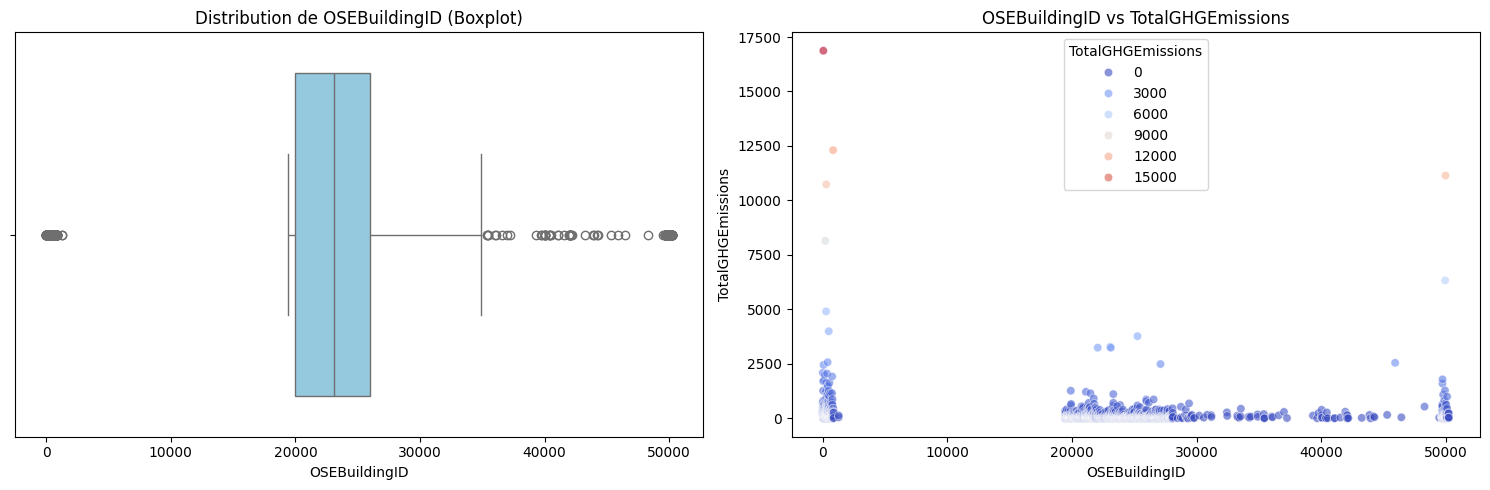

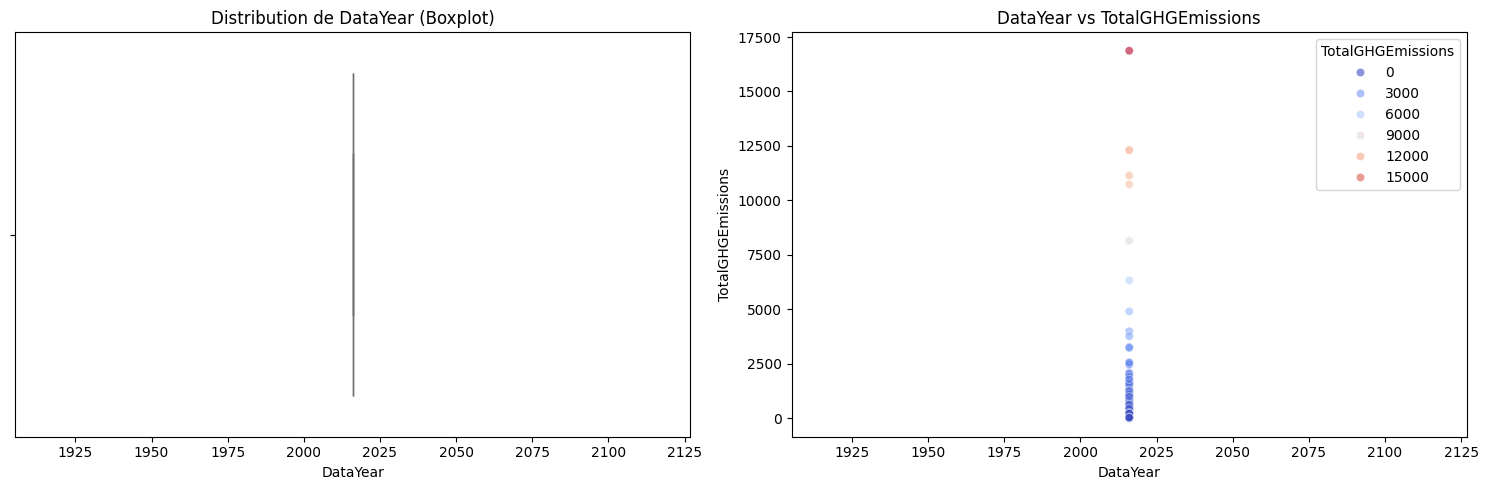

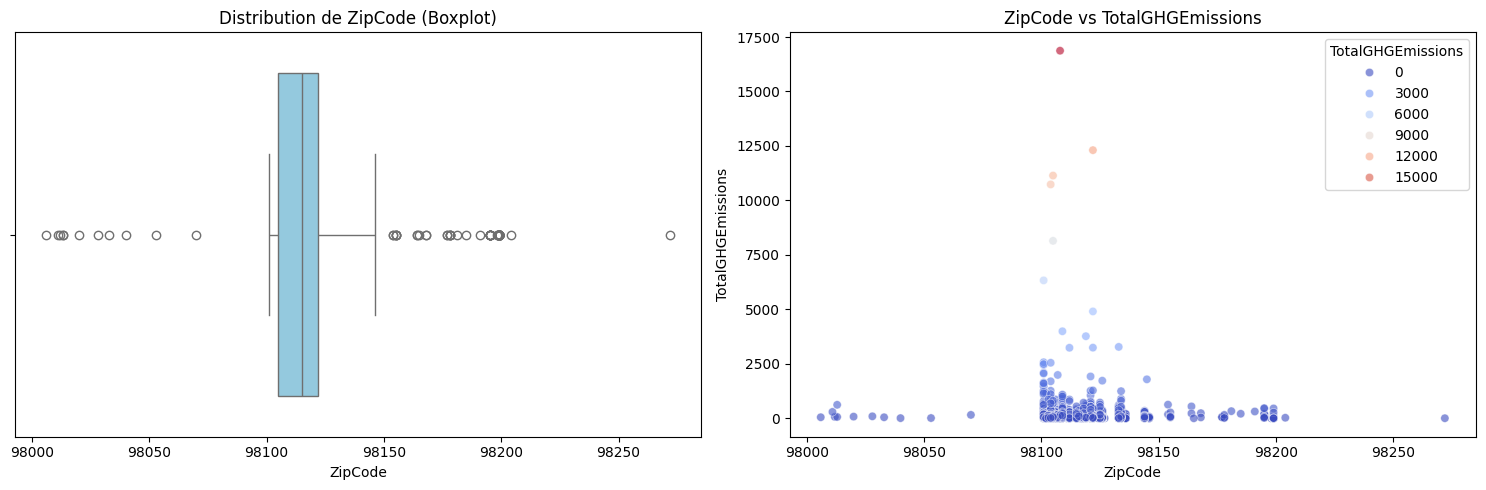

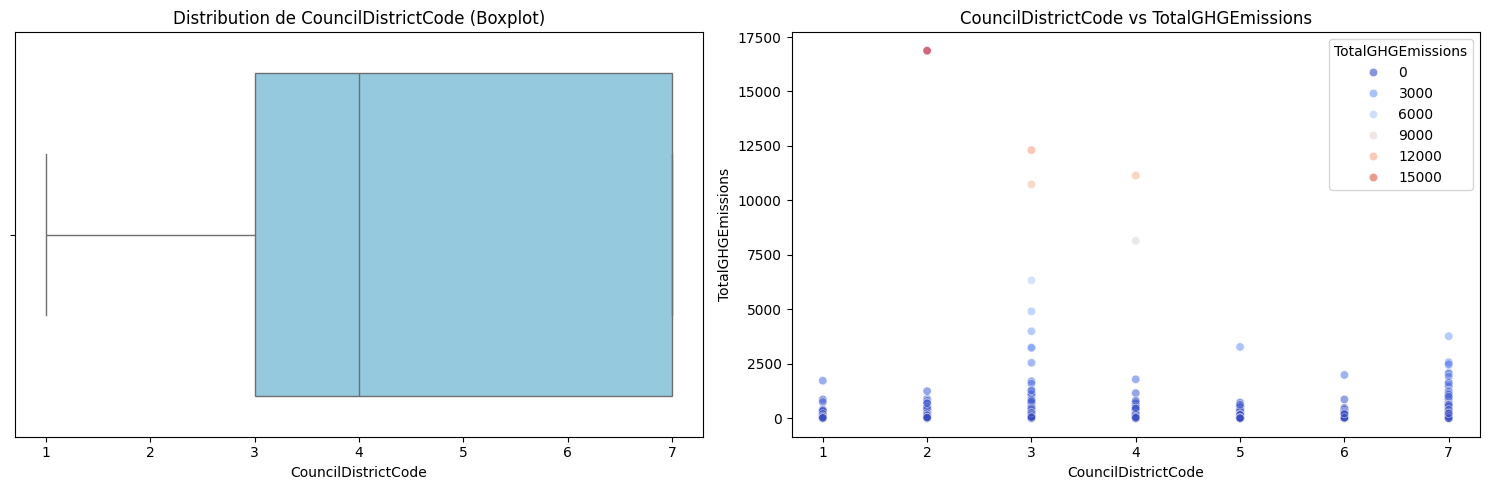

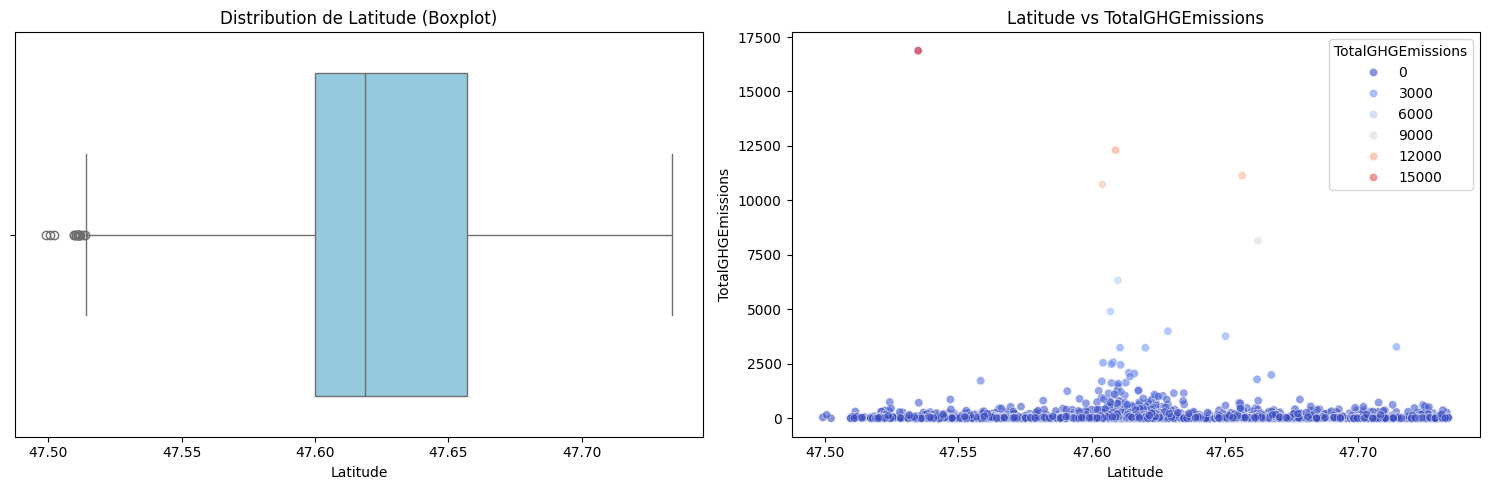

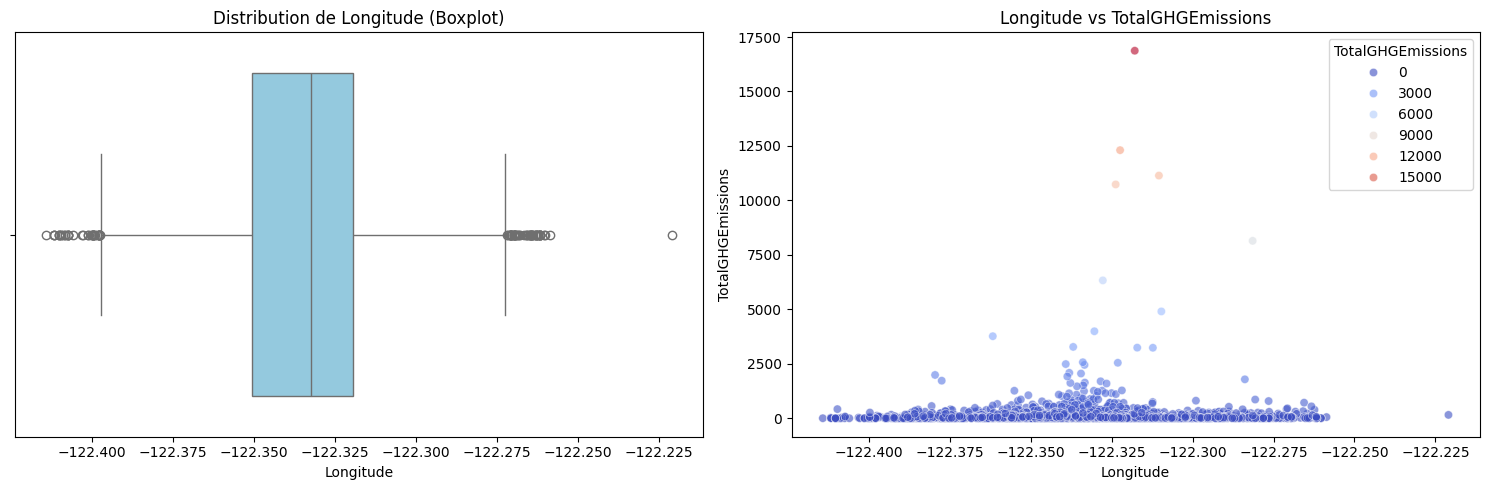

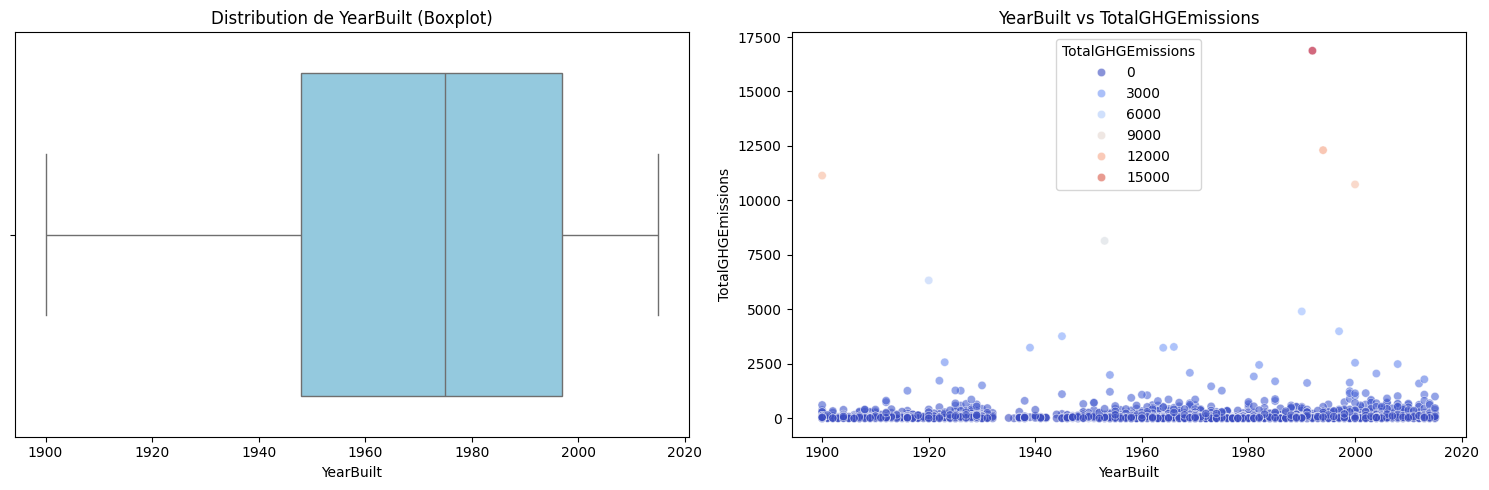

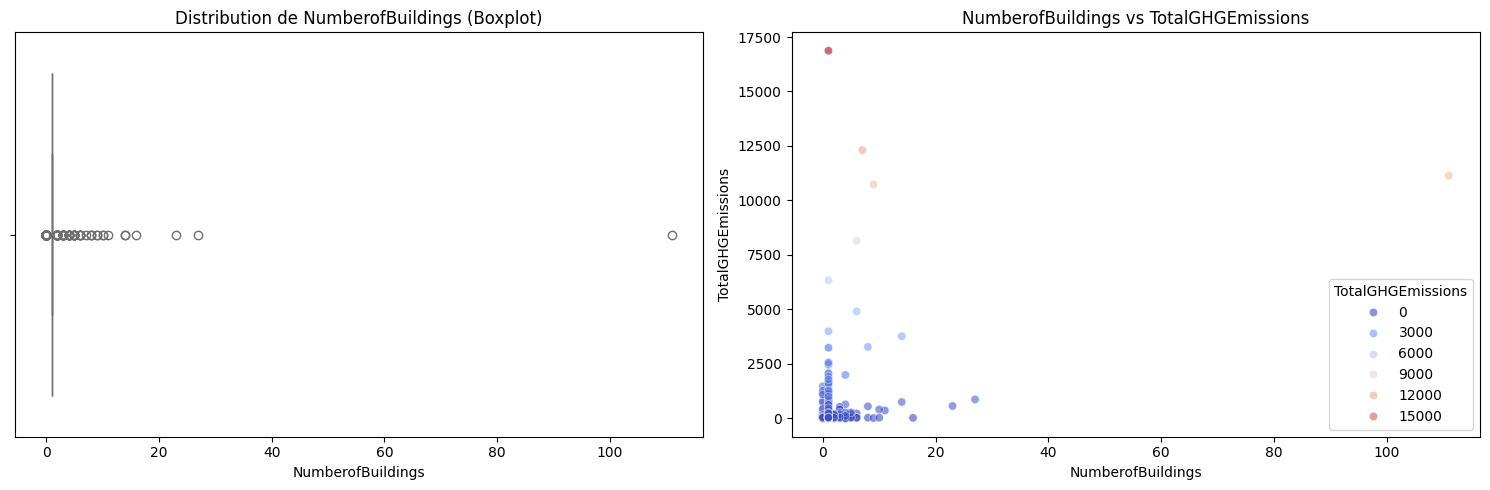

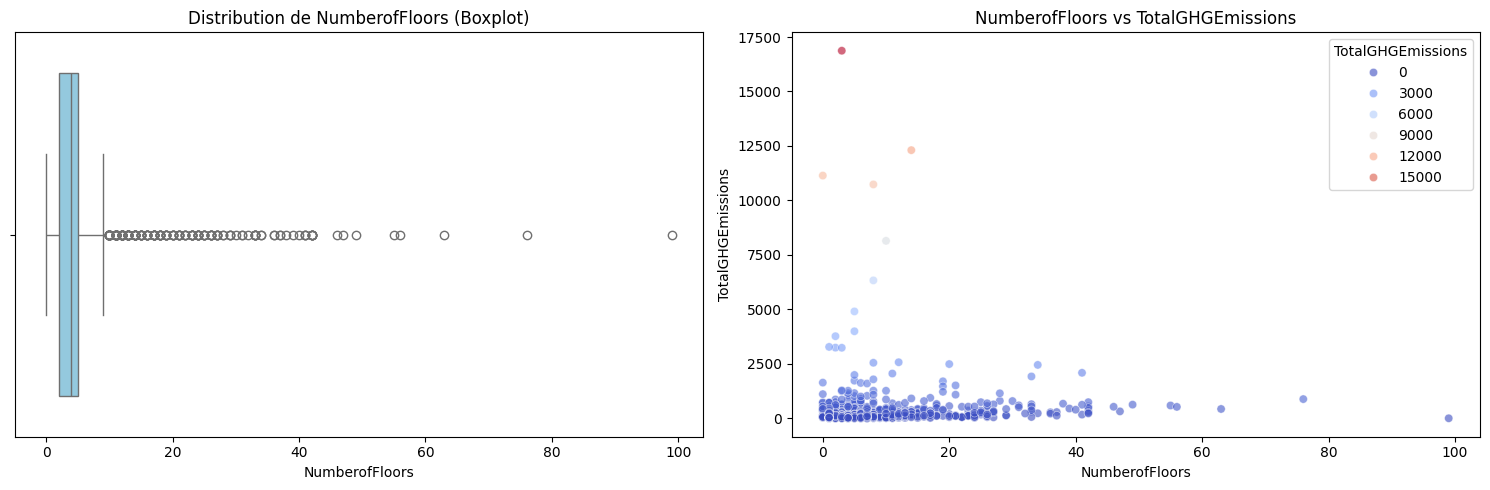

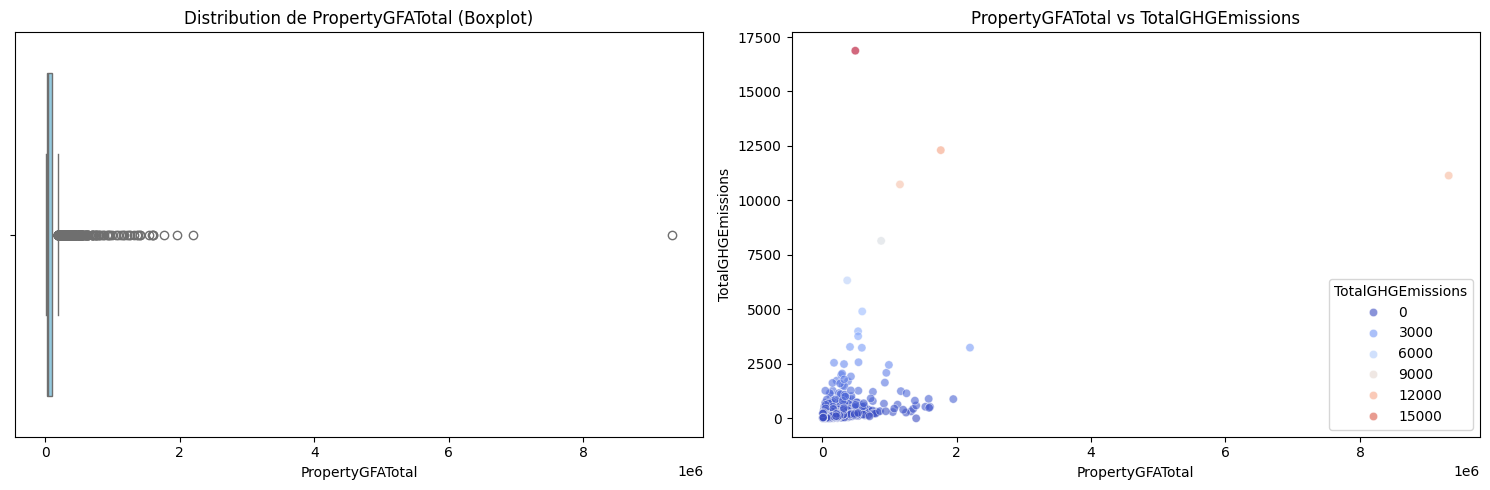

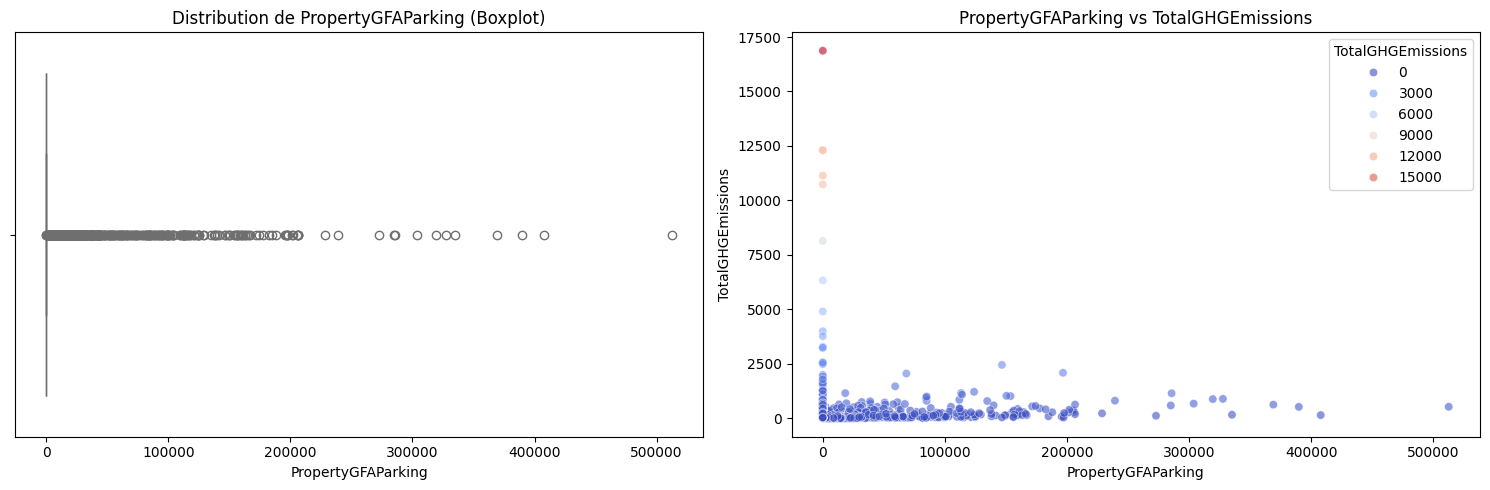

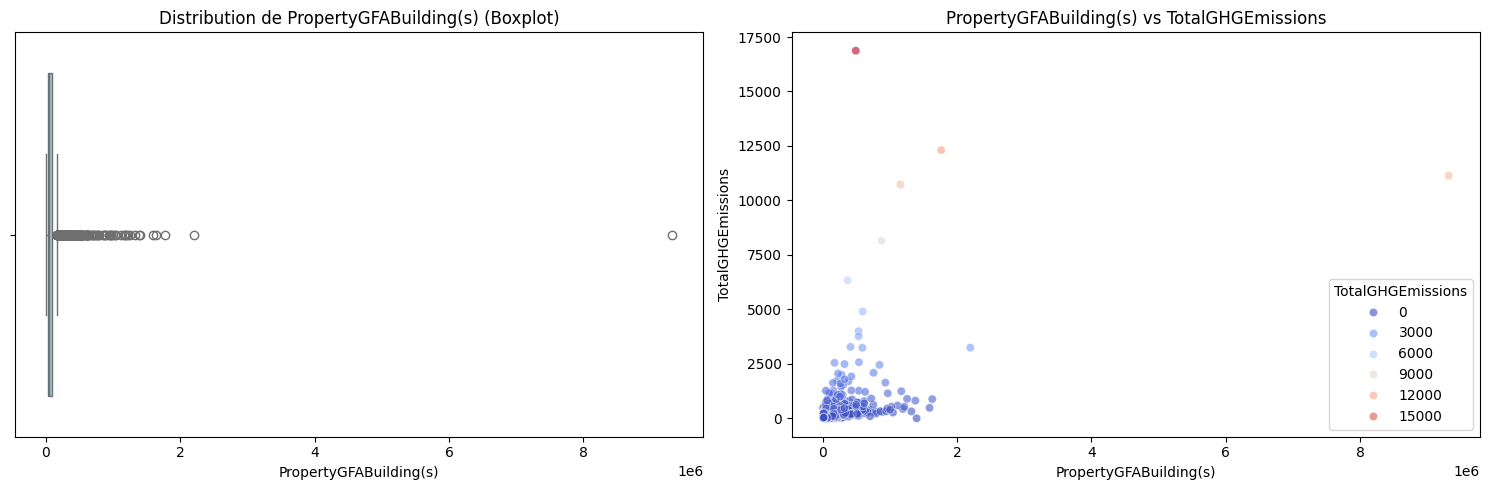

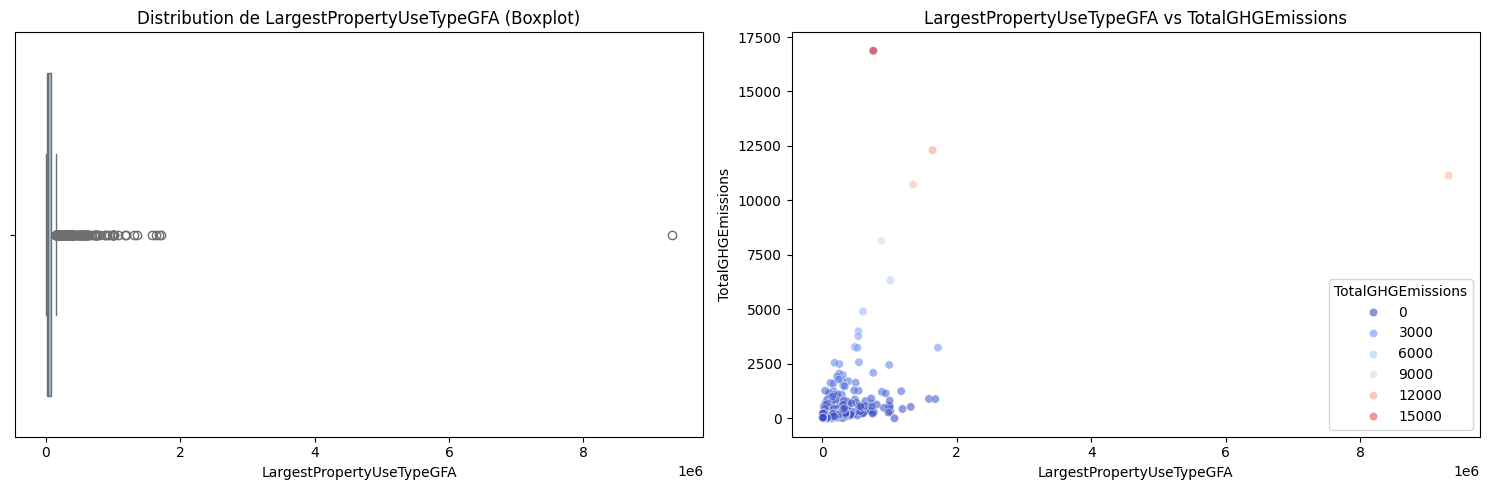

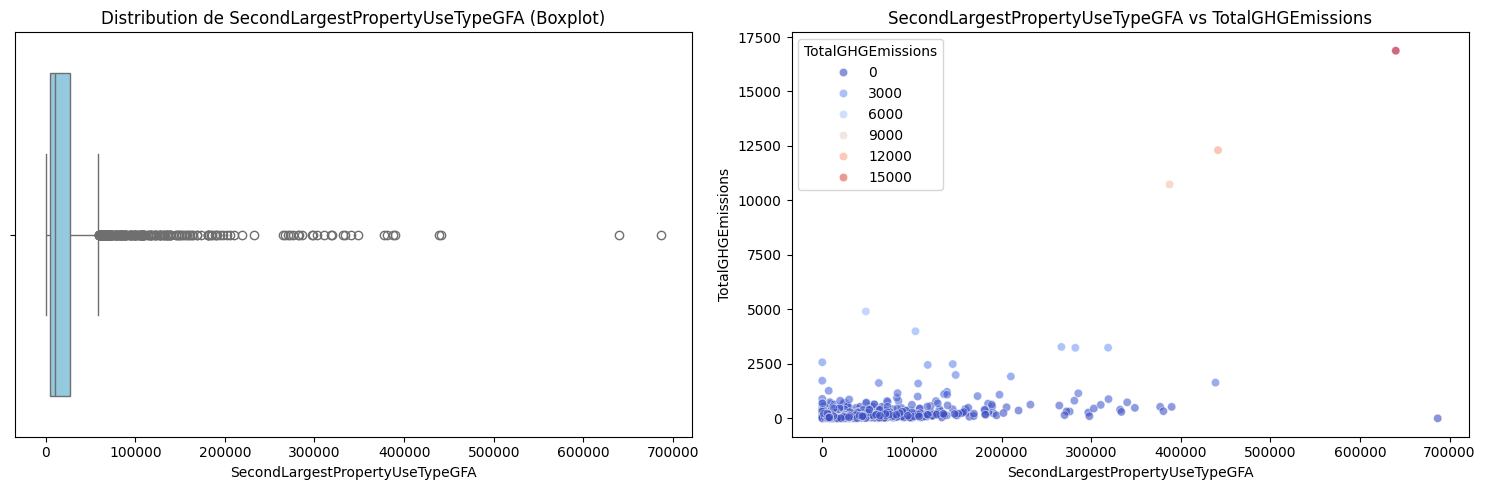

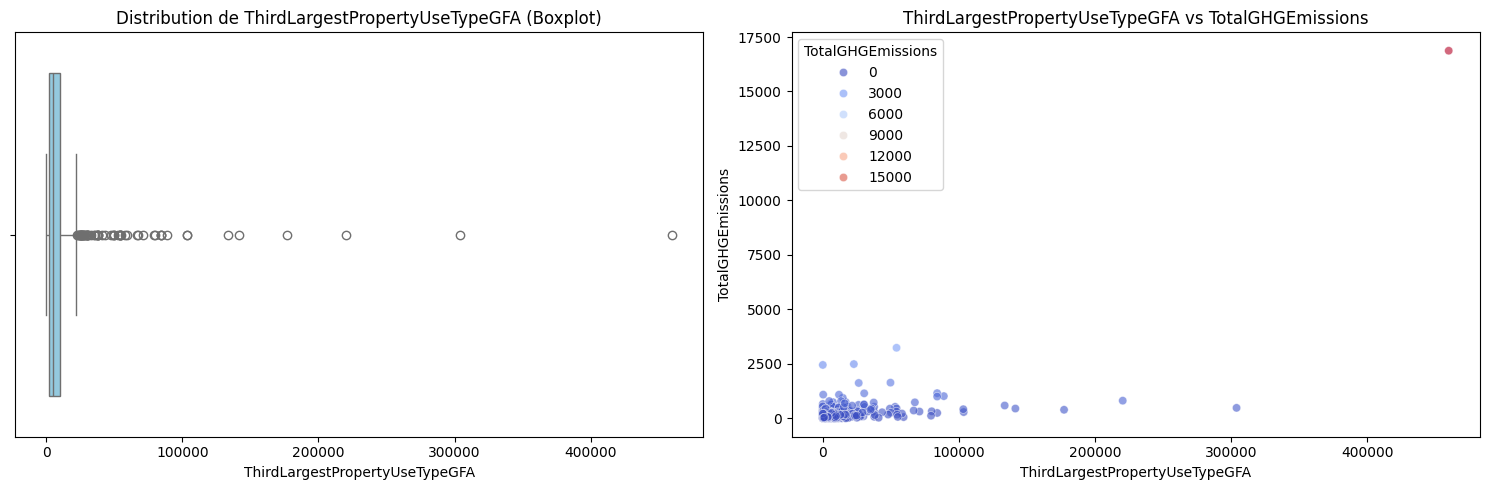

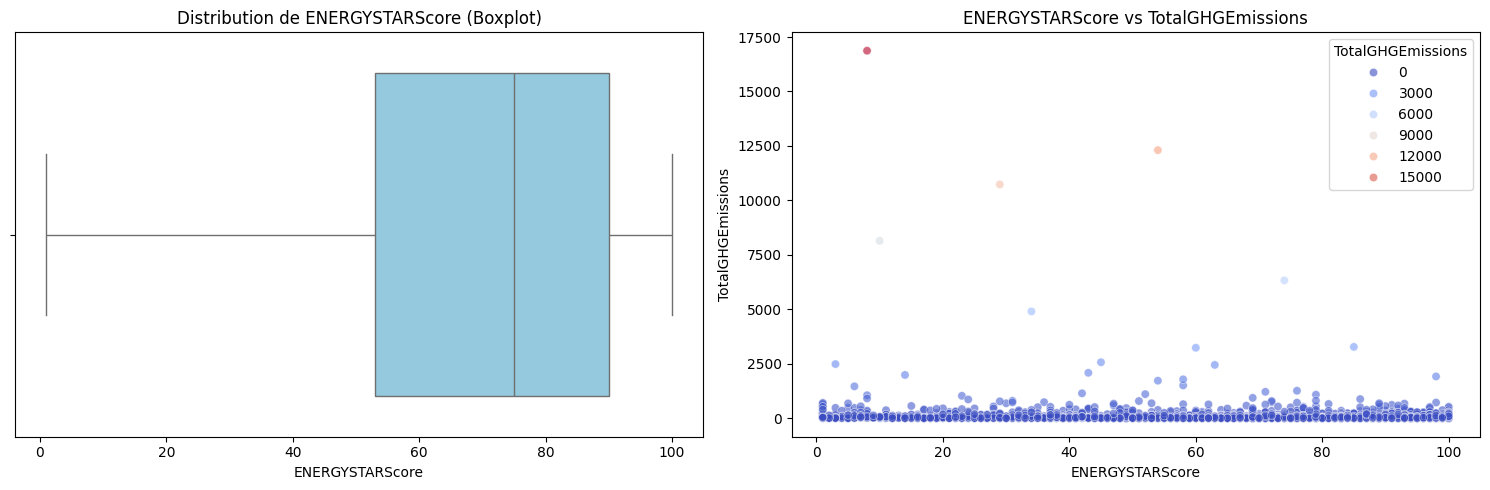

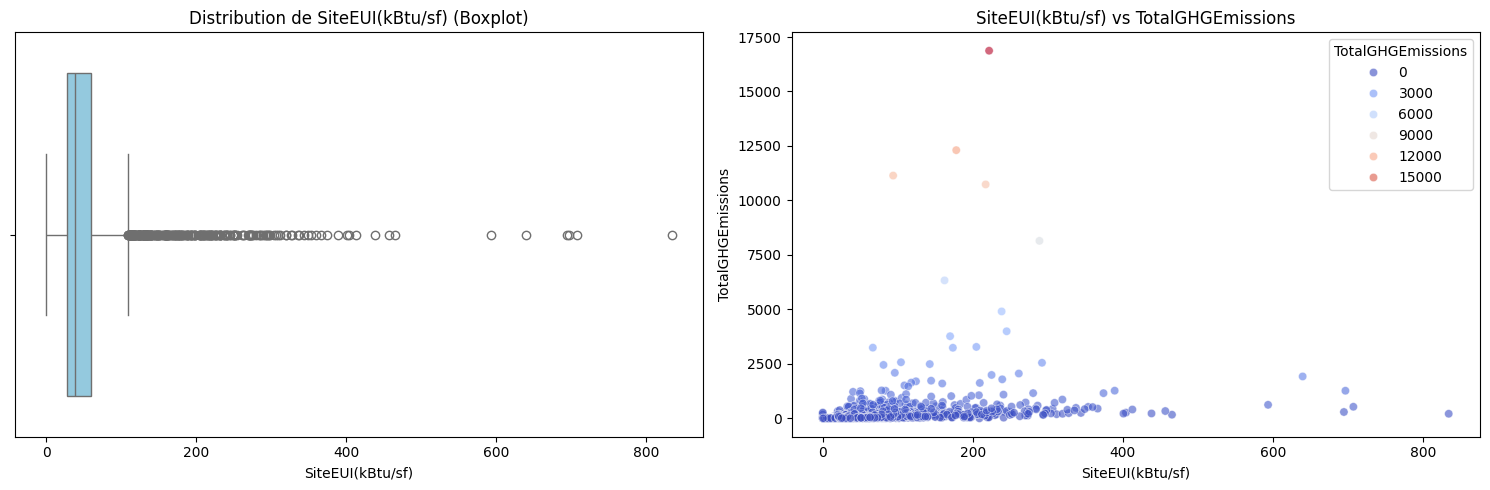

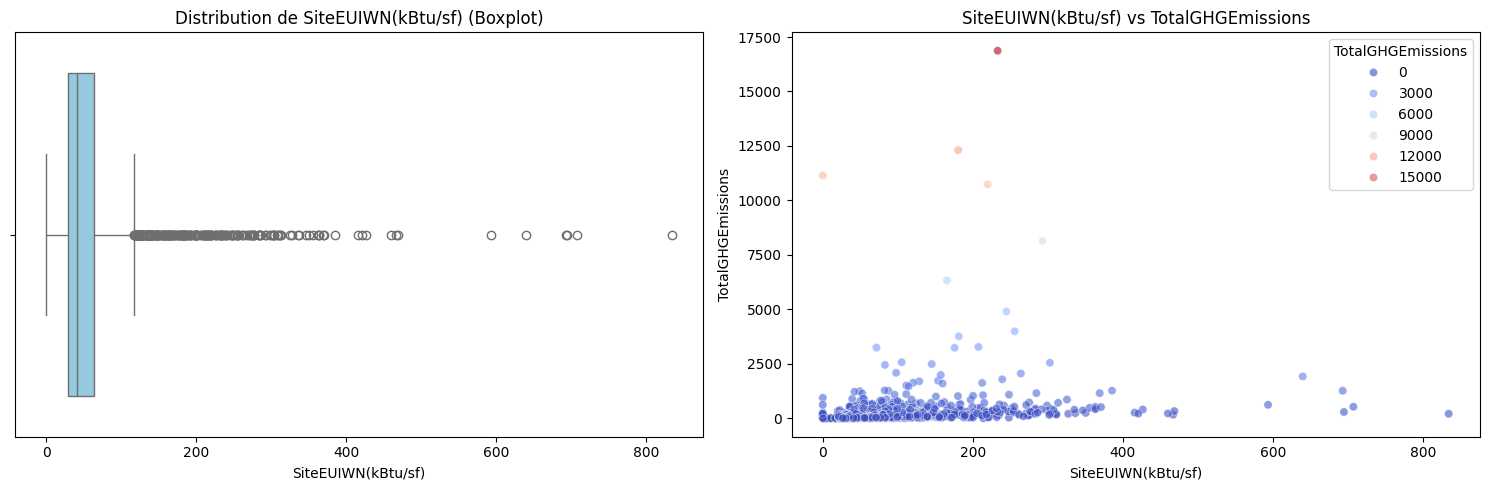

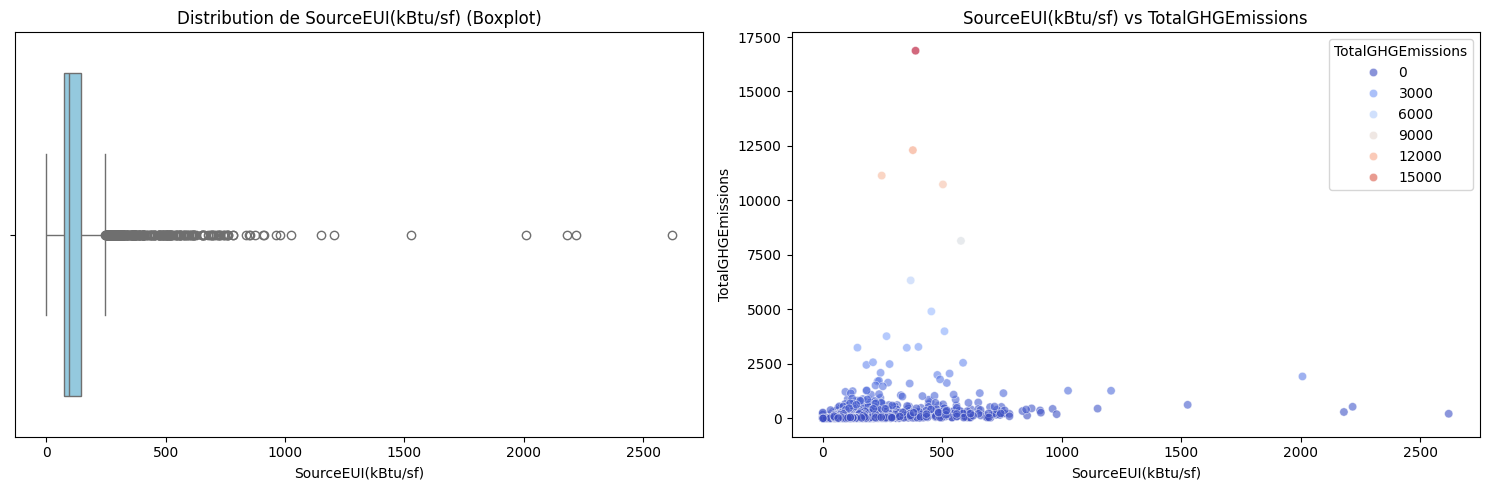

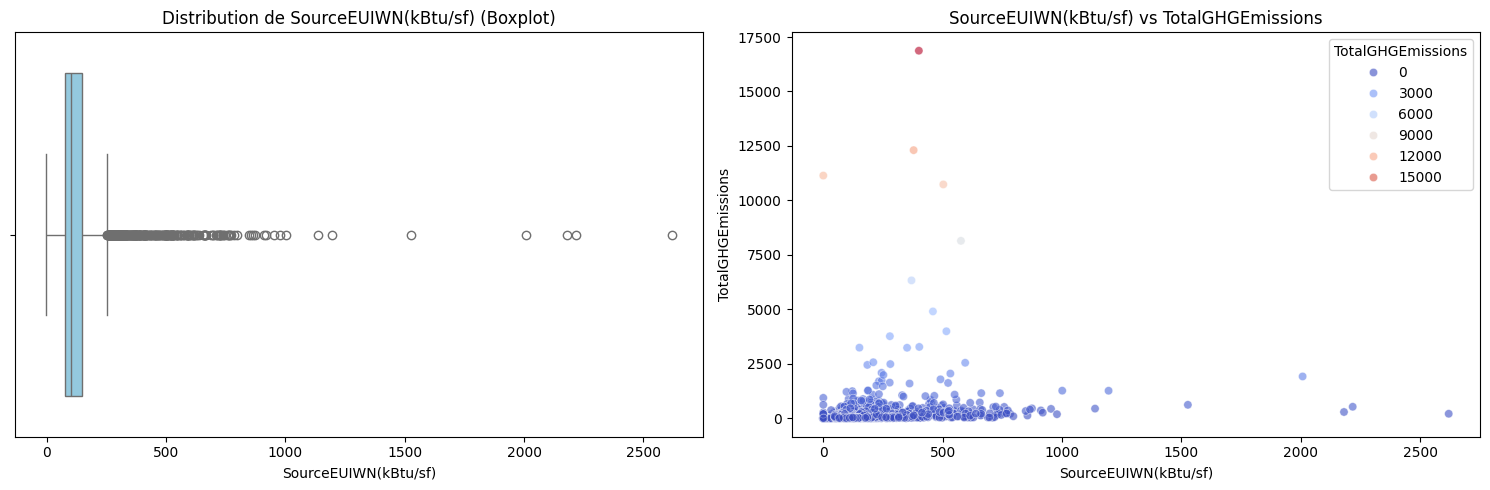

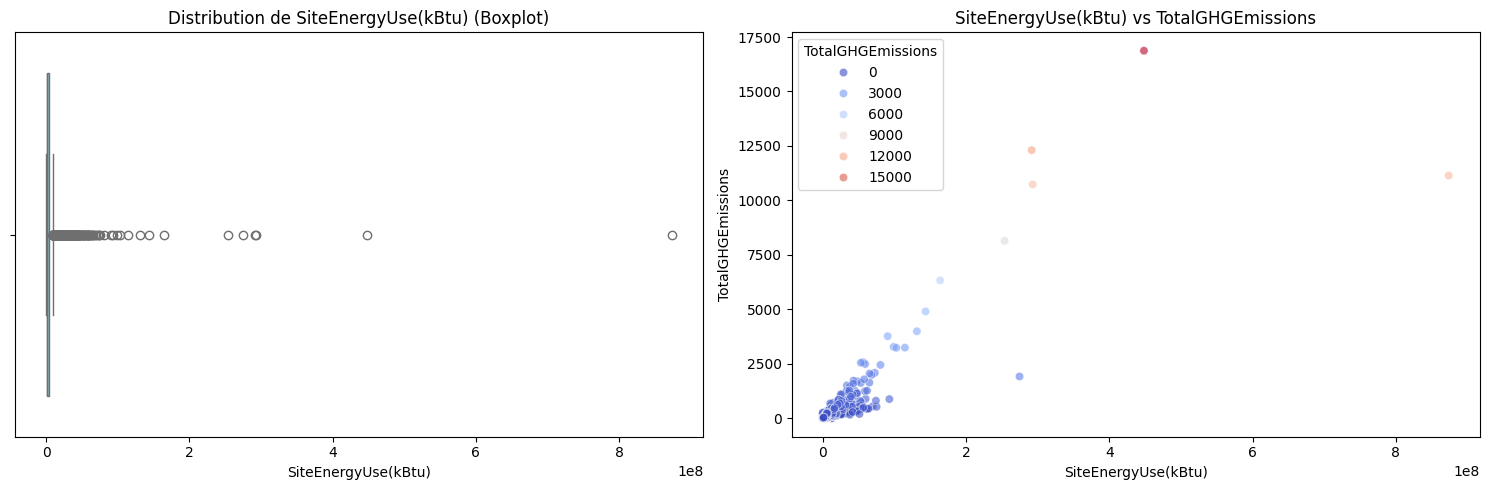

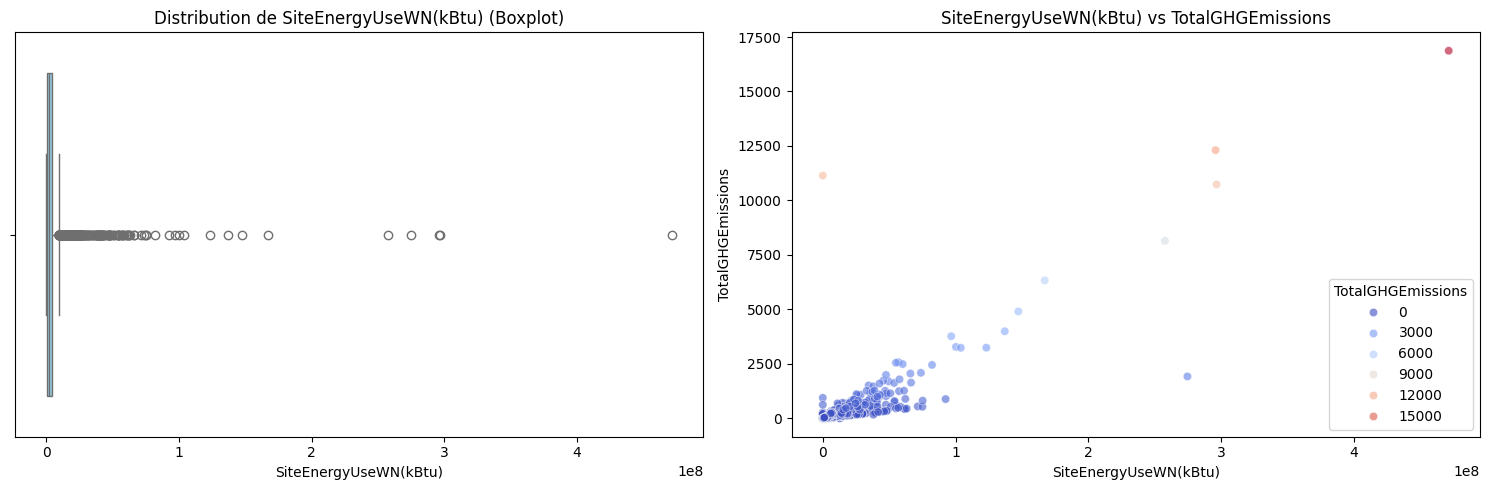

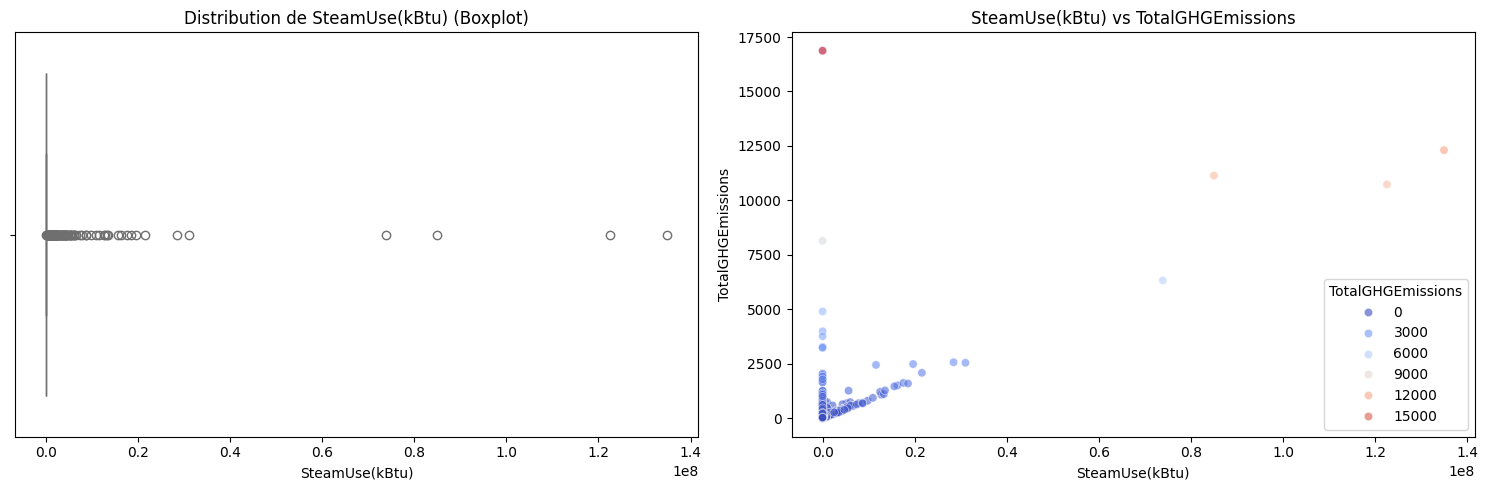

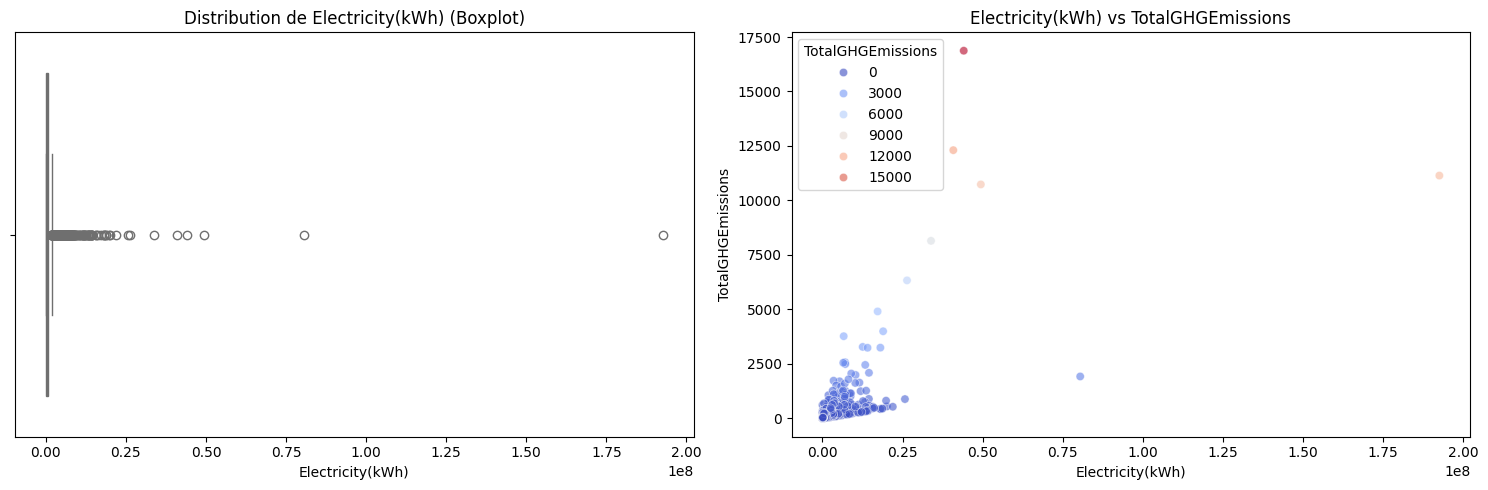

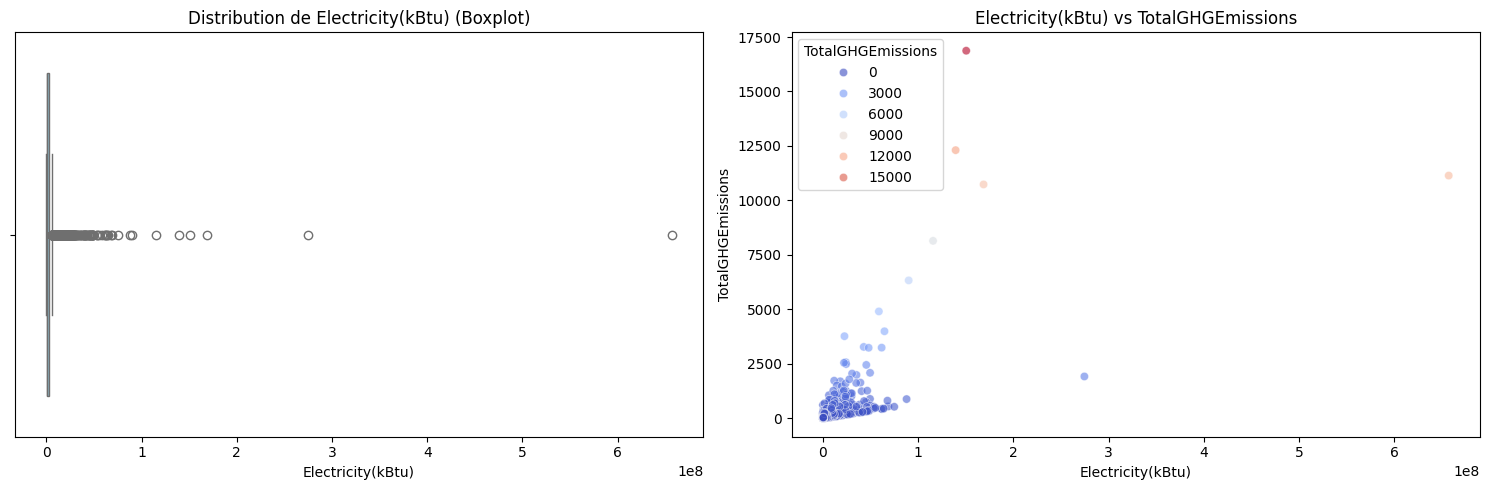

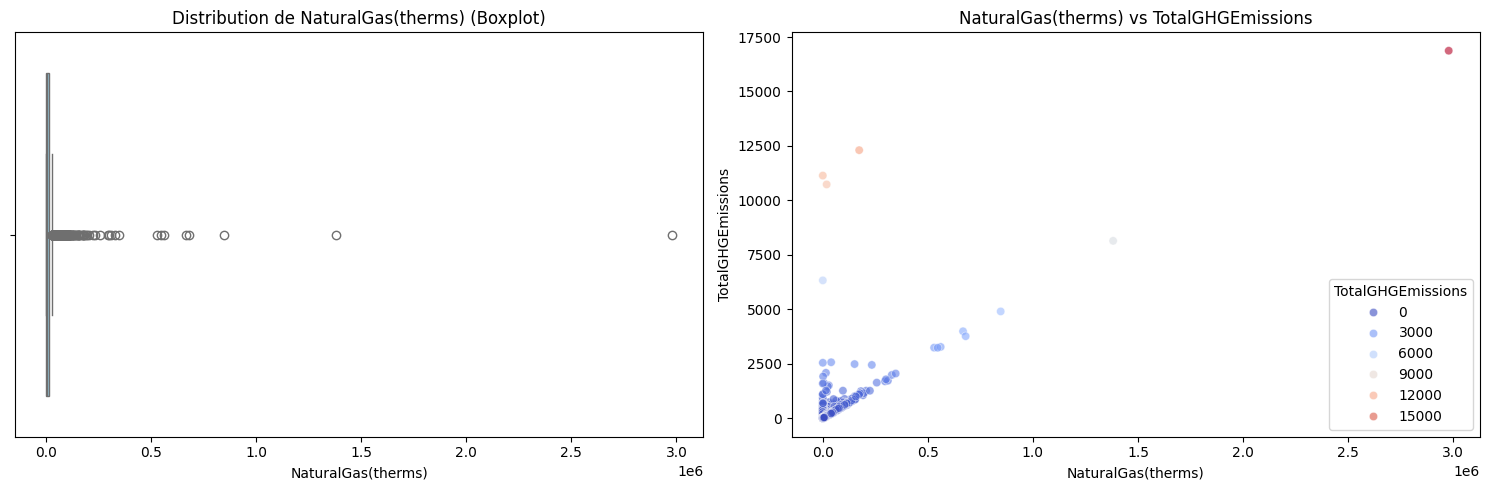

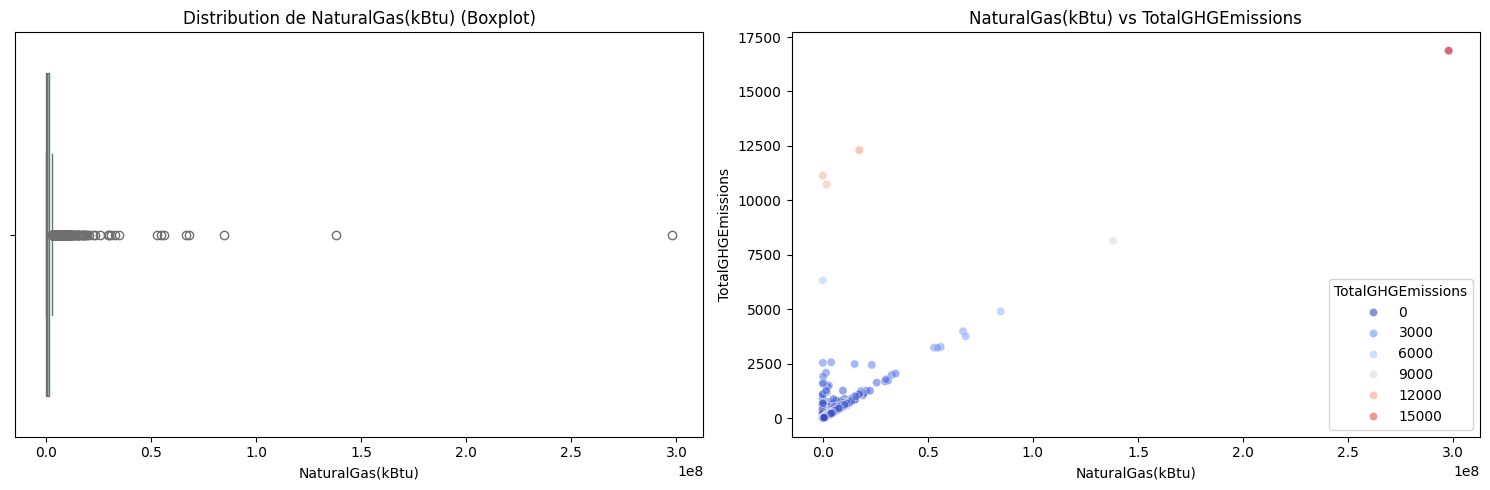

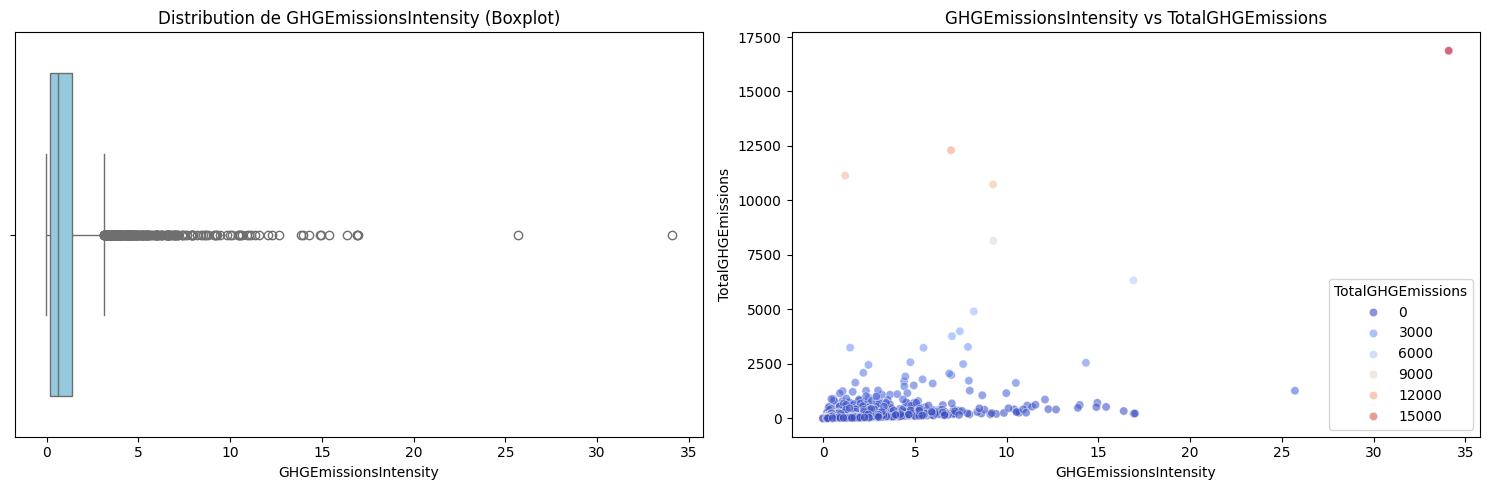

In [7]:
def plot_num(dataframe):
    dataframe = dataframe.select_dtypes(include=['int64', 'float64'])
    target_col = 'TotalGHGEmissions'

    # Filter out columns that are entirely NaN before processing
    valid_numerical_cols = [col for col in dataframe.columns if not dataframe[col].isnull().all()]
    features_num = [col for col in valid_numerical_cols if col != target_col]

    # 2. Boucle sur chaque feature numérique
    for feature in features_num:
        # Création d'une figure avec 2 sous-graphiques (1 ligne, 2 colonnes)
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # --- GRAPHIQUE 1 : Le Boxplot (à gauche) ---
        sns.boxplot(
            data=dataframe,
            x=feature,
            ax=axes[0],
            color='skyblue'
        )
        axes[0].set_title(f'Distribution de {feature} (Boxplot)')

        # --- GRAPHIQUE 2 : Le Scatter Plot (à droite) ---
        sns.scatterplot(
            data=dataframe,
            x=feature,
            y=target_col, # La target est toujours sur l'axe Y
            hue=target_col, # Coloration selon la target
            palette='coolwarm',
            ax=axes[1],
            alpha=0.6 # Rend les points un peu transparents pour mieux voir la densité
        )
        axes[1].set_title(f'{feature} vs {target_col}')

        # Ajustement de l'espacement et affichage
        plt.tight_layout()
        plt.show()
plot_num(building_consumption)

### Fonction de plot Cat data

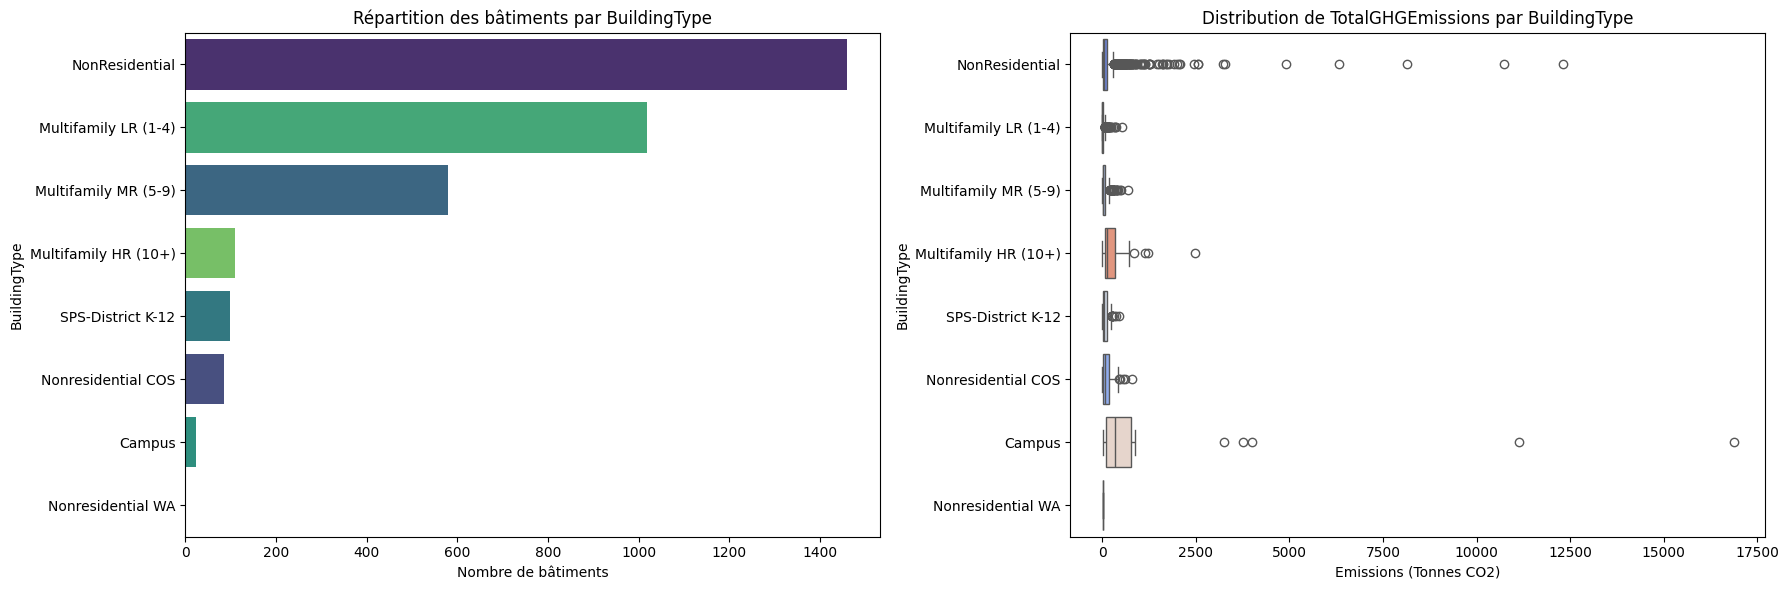

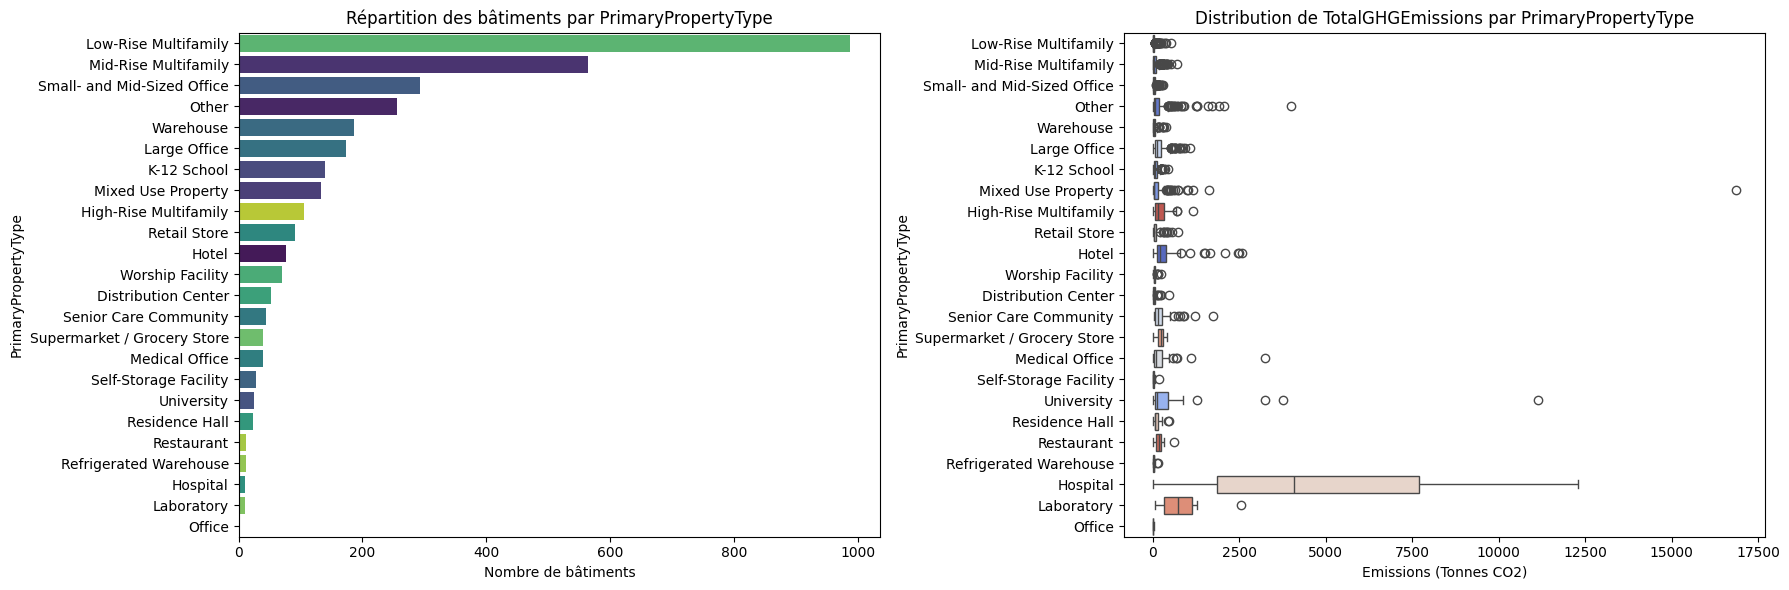

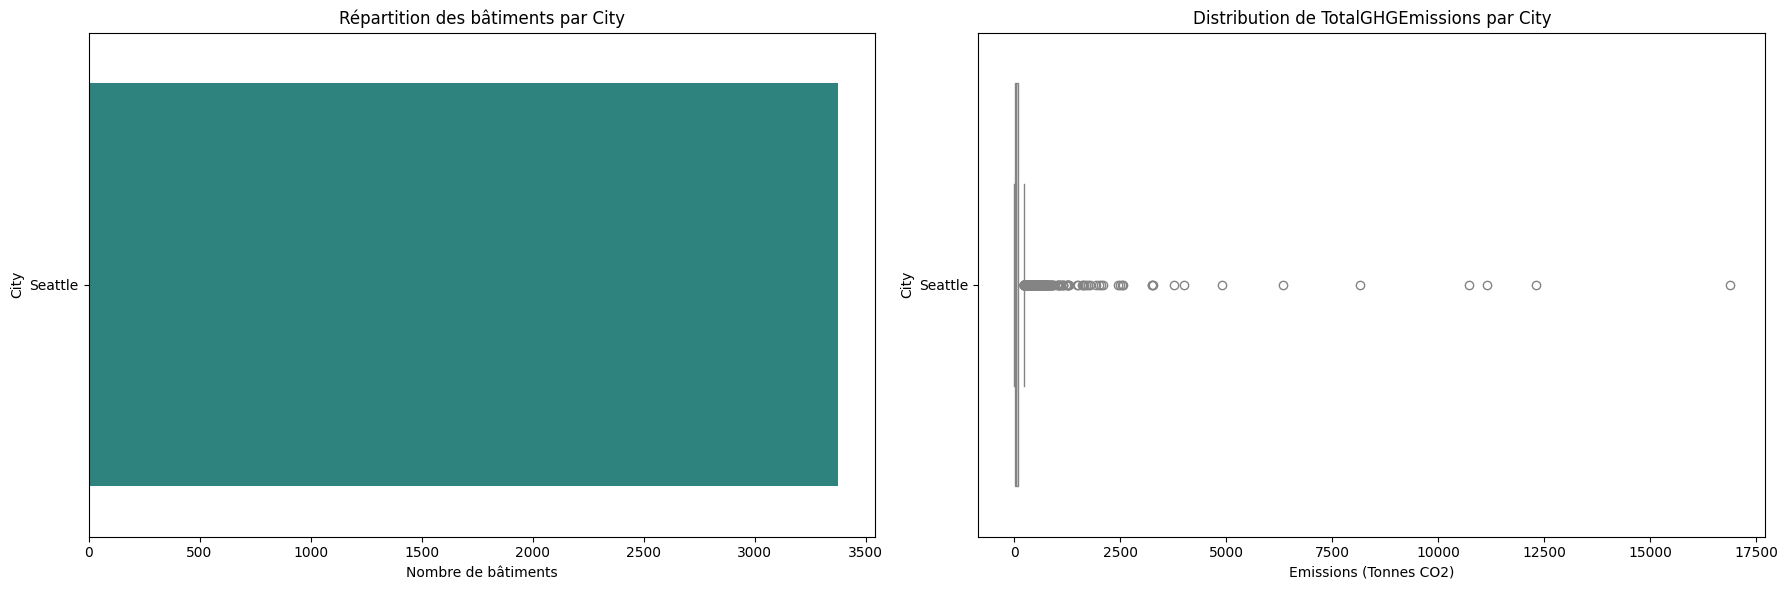

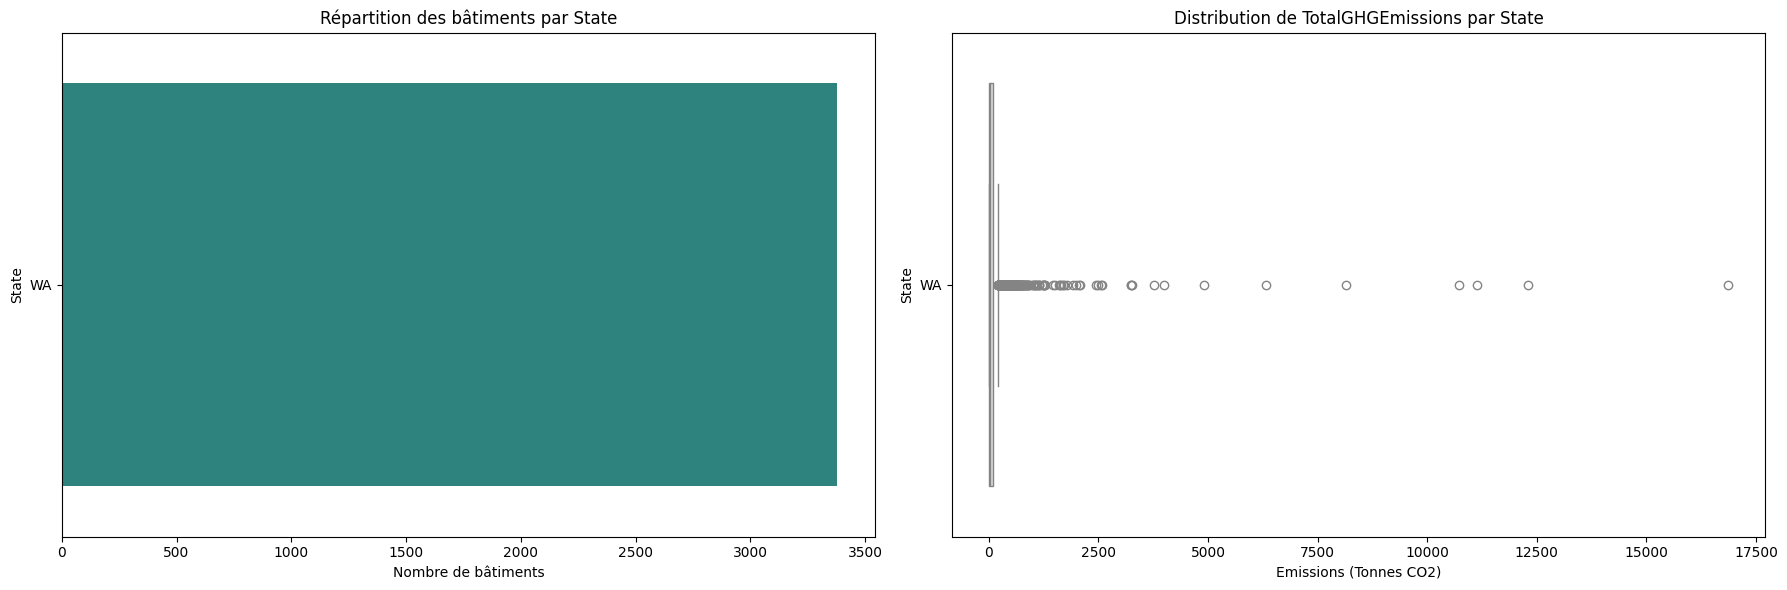

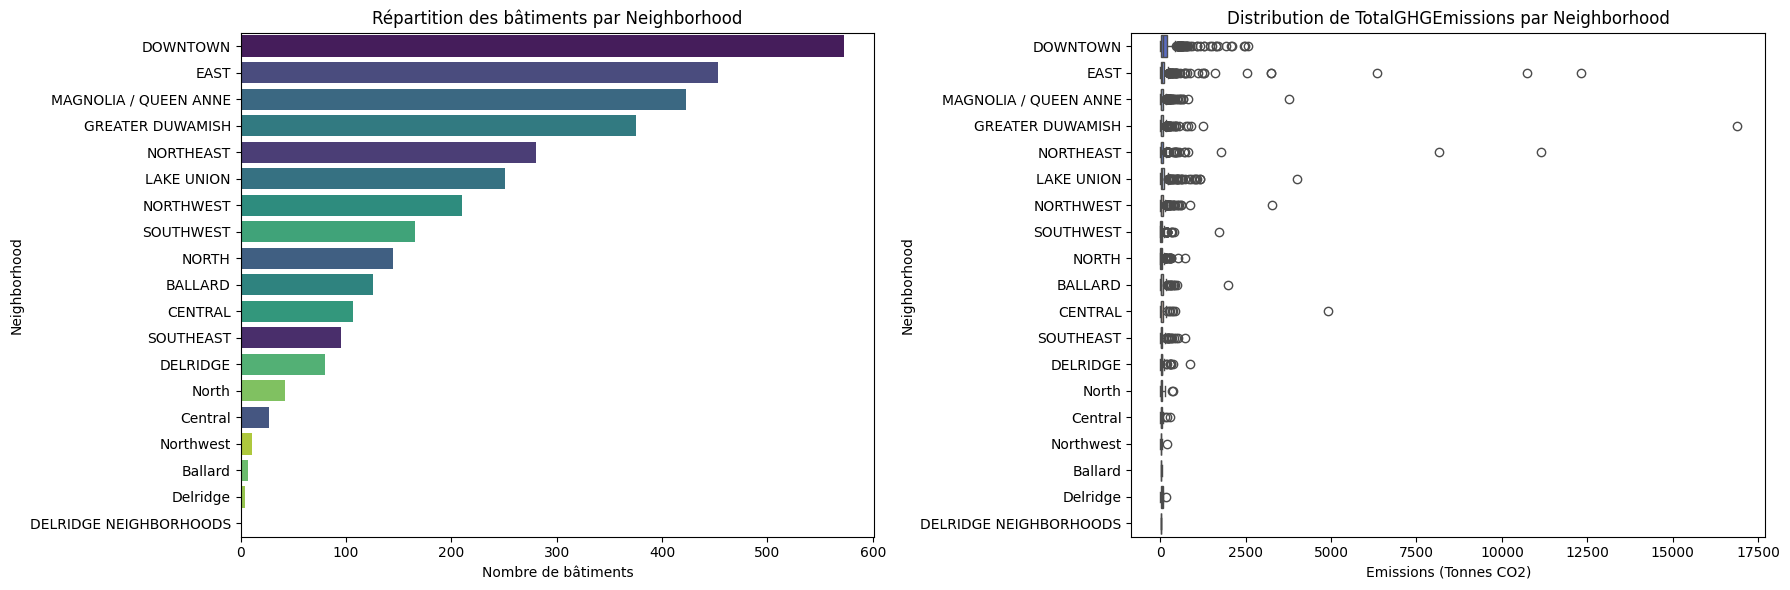

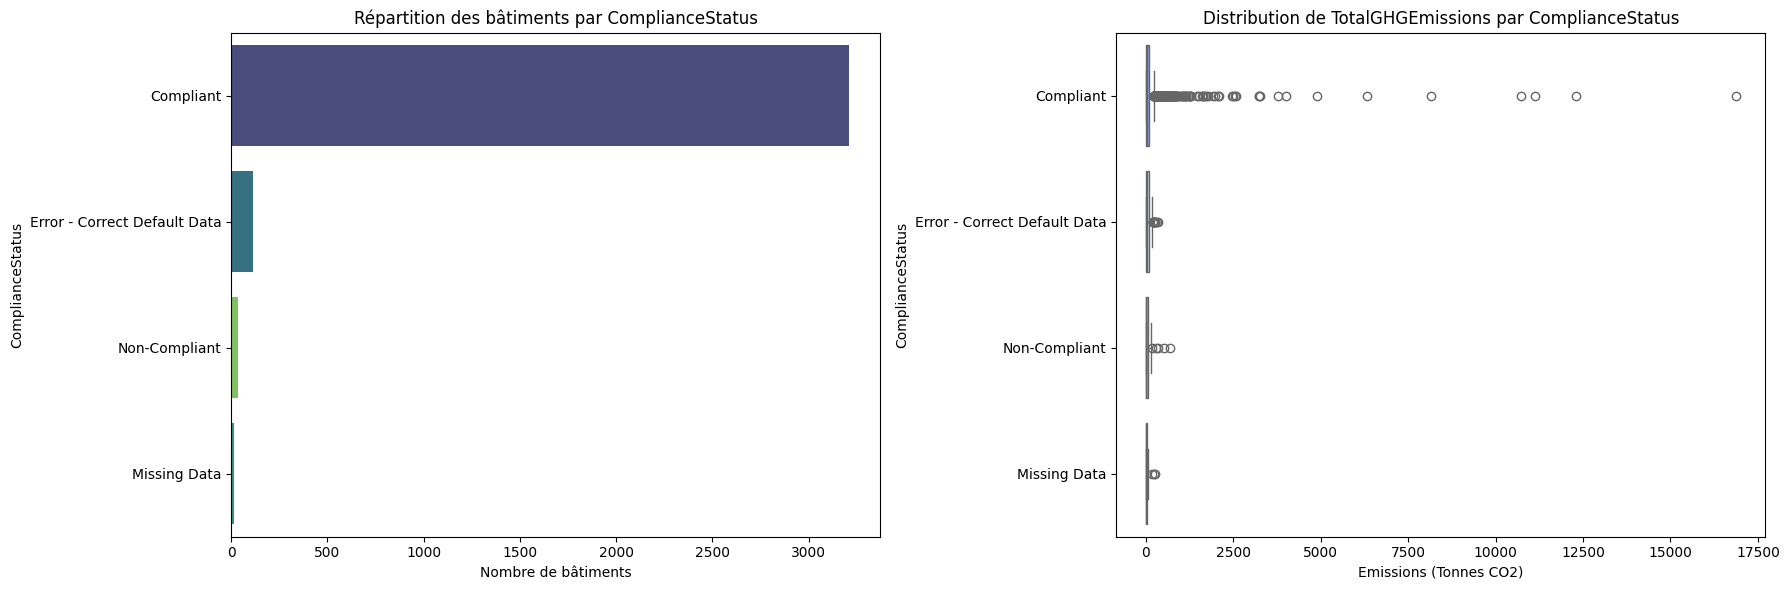

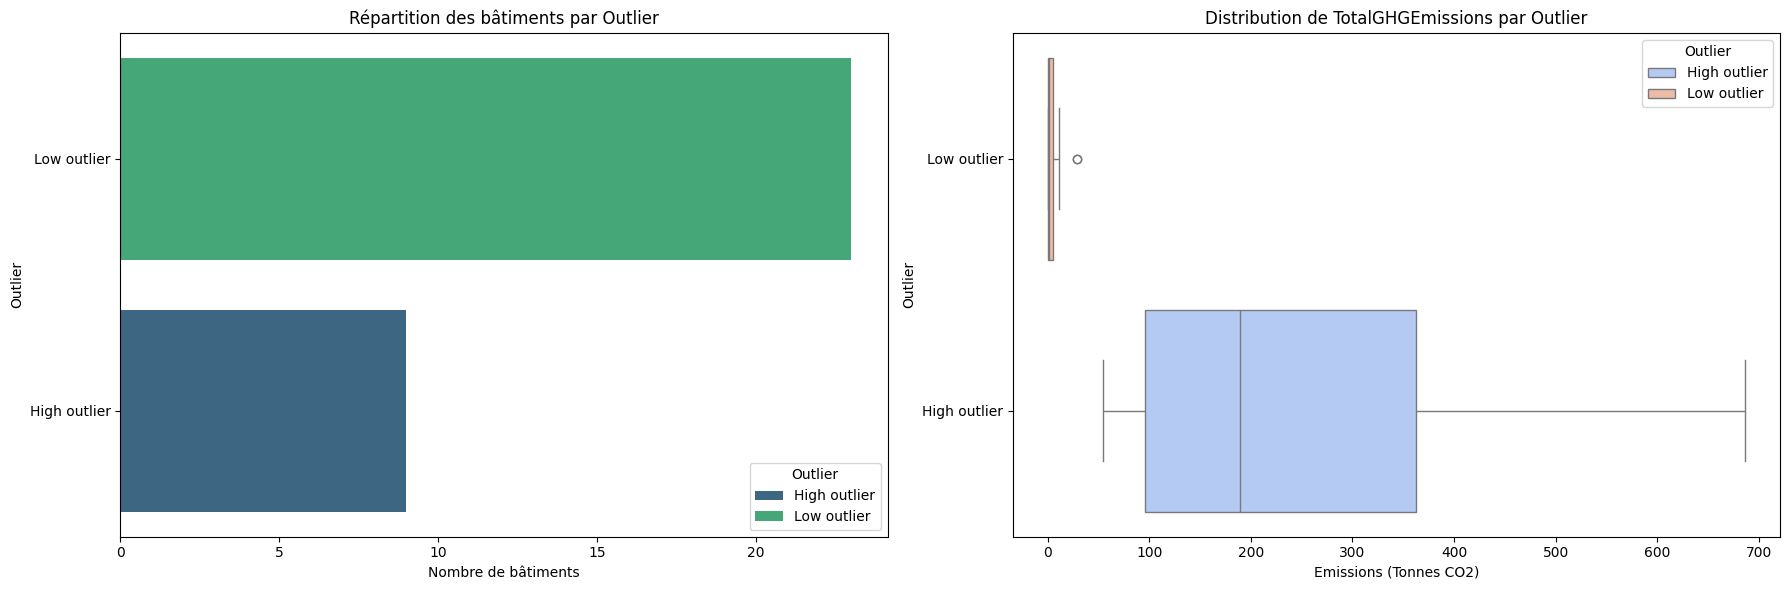

In [8]:
def plot_cat(dataframe):
    # 1. Identifier les colonnes catégorielles
    df_cat = dataframe.select_dtypes(include=['object'])
    target_col = 'TotalGHGEmissions'
    features_cat = df_cat.columns

    # 2. Boucle sur chaque feature catégorielle
    for feature in features_cat:
        nb_categories = dataframe[feature].nunique()

        if nb_categories > 30:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        # --- GRAPHIQUE 1 : Le Countplot ---
        sns.countplot(
            data=dataframe,
            y=feature,
            hue=feature,
            palette='viridis',
            order=dataframe[feature].value_counts().index,
            ax=axes[0]
        )
        axes[0].set_title(f"Répartition des bâtiments par {feature}")
        axes[0].set_xlabel("Nombre de bâtiments")

        # --- GRAPHIQUE 2 : Le Boxplot Catégoriel ---
        sns.boxplot(
            data=dataframe,
            y=feature,
            x=target_col,
            hue=feature,
            palette='coolwarm',
            order=dataframe[feature].value_counts().index,
            ax=axes[1]
        )
        axes[1].set_title(f"Distribution de {target_col} par {feature}")
        axes[1].set_xlabel("Emissions (Tonnes CO2)")

        plt.tight_layout()
        plt.show()
plot_cat(building_consumption)

## Filtrage

### F0 — Périmètre de la mission

La commande porte sur les **bâtiments non destinés à l'habitation**. Ce filtre ne se déduit
d'aucune statistique : il se lit dans l'énoncé, et s'applique donc avant tout le reste.

Convention retenue : on suit `BuildingType`, champ de classification de la Ville, plutôt qu'une
interprétation des usages. Les cas limites (résidences universitaires, résidences seniors)
restent donc dans le périmètre — signalés ci-dessous plutôt qu'arbitrés à la main.

In [9]:
# F0 : périmètre de la mission — « bâtiments non destinés à l'habitation »
print(building_consumption['BuildingType'].value_counts(dropna=False), "\n")

habitation = building_consumption['BuildingType'].str.startswith('Multifamily', na=False)
df_F0 = building_consumption[~habitation].copy()

y_brut = building_consumption['TotalGHGEmissions']
print(f"Logements collectifs écartés : {habitation.sum()} "
      f"({100 * habitation.mean():.0f} % du jeu brut)")
print(f"Bâtiments retenus            : {len(df_F0)}")
print(f"\nAsymétrie de la cible — parc complet    : {y_brut[y_brut > 0].skew():.2f}")
print(f"Asymétrie de la cible — hors habitation : "
      f"{y_brut[(y_brut > 0) & ~habitation].skew():.2f}")

limites = df_F0['PrimaryPropertyType'].value_counts()
limites = limites[limites.index.str.contains('Residence|Senior', case=False)]
print(f"\nCas limites conservés (hébergement collectif classé non résidentiel) :\n"
      f"{limites.to_string() if len(limites) else '  aucun'}")

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64 

Logements collectifs écartés : 1708 (51 % du jeu brut)
Bâtiments retenus            : 1668

Asymétrie de la cible — parc complet    : 19.46
Asymétrie de la cible — hors habitation : 14.19

Cas limites conservés (hébergement collectif classé non résidentiel) :
PrimaryPropertyType
Residence Hall           21
Senior Care Community    20


L'asymétrie reste élevée après ce filtre : elle est intrinsèque au parc bâti, pas causée par
les logements. Le passage au logarithme reste donc justifié — et il l'est désormais aussi par
la nature de la population : comparer une erreur *absolue* entre une supérette et un hôpital
n'a pas de sens, une erreur *relative* si.

### F1 - No variance

In [10]:
# Affichage des colonnes sans variation de valeur dans le dataset = aucune information pour l'apprentissage car aucune diversité = non descriminant à filtrer out.
df_F0[df_F0.columns[df_F0.nunique() <= 1]].columns

Index(['DataYear', 'City', 'State', 'Comments'], dtype='object')

In [11]:
# F1 = Premier filtre sur les features sans variances --> Masquage sur les colonnes à une seule valeur unique
# On part de df_F0 : le périmètre de la mission, pas le jeu brut.
df_F1 = df_F0.filter(items=df_F0.columns[df_F0.nunique() > 1])
df_F1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1668 entries, 0 to 3375
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1668 non-null   int64  
 1   BuildingType                     1668 non-null   object 
 2   PrimaryPropertyType              1668 non-null   object 
 3   PropertyName                     1668 non-null   object 
 4   Address                          1668 non-null   object 
 5   ZipCode                          1652 non-null   float64
 6   TaxParcelIdentificationNumber    1668 non-null   object 
 7   CouncilDistrictCode              1668 non-null   int64  
 8   Neighborhood                     1668 non-null   object 
 9   Latitude                         1668 non-null   float64
 10  Longitude                        1668 non-null   float64
 11  YearBuilt                        1668 non-null   int64  
 12  NumberofBuildings        

### F2 Filtre valeurs nulles

In [12]:
# F2 = Deuxième filtre sur les valeurs nulles --> Masquage de colonnes.
pourcentage_nan = df_F1.isnull().mean()
SEUIL = 0.30

print("=== RATIO DE VALEURS MANQUANTES (> 30 %) ===")
print((pourcentage_nan[pourcentage_nan > 0.30] * 100)
      .sort_values(ascending=False).round(2).to_string())

# --- Avant d'écarter : manquant, ou non applicable ? ----------------------
suspectes = pourcentage_nan[pourcentage_nan > SEUIL].index
print("\n=== EXAMEN MÉTIER DES COLONNES AU-DESSUS DU SEUIL ===")
for col in suspectes:
    print(f"\n--- {col} — {df_F1[col].isna().sum()} manquants "
          f"({100 * pourcentage_nan[col]:.1f} %) ---")
    # is_numeric_dtype plutôt que dtype == 'object' : selon la version de pandas,
    # une colonne texte porte le dtype 'object' ou 'str'.
    if not pd.api.types.is_numeric_dtype(df_F1[col]):
        print(f"  {df_F1[col].nunique()} modalités, les 8 plus fréquentes :")
        print("  " + df_F1[col].value_counts().head(8).to_string().replace('\n', '\n  '))
    else:
        stats = df_F1[col].describe()
        garde = [k for k in ['count', 'mean', '50%', 'max'] if k in stats.index]
        print("  " + stats[garde].round(1).to_string().replace('\n', '\n  '))


=== RATIO DE VALEURS MANQUANTES (> 30 %) ===
Outlier                            98.98
YearsENERGYSTARCertified           94.12
ThirdLargestPropertyUseType        78.84
ThirdLargestPropertyUseTypeGFA     78.84
SecondLargestPropertyUseType       48.74
SecondLargestPropertyUseTypeGFA    48.74
ENERGYSTARScore                    34.41

=== EXAMEN MÉTIER DES COLONNES AU-DESSUS DU SEUIL ===

--- SecondLargestPropertyUseType — 813 manquants (48.7 %) ---
  47 modalités, les 8 plus fréquentes :
  SecondLargestPropertyUseType
  Parking                           336
  Office                            167
  Retail Store                       85
  Other                              45
  Non-Refrigerated Warehouse         30
  Restaurant                         29
  Fitness Center/Health Club/Gym     16
  Data Center                        13

--- SecondLargestPropertyUseTypeGFA — 813 manquants (48.7 %) ---
  count       855.0
  mean      36804.2
  50%       12000.0
  max      686750.0

--- ThirdLar

#### Analyse métier sur les colonnes à gros volumes de valeur nulles

Outlier <-- Flag sur les valeurs abérrantes </br>
YearsENERGYSTARCertified <-- DataLeak à écarter </br>
ThirdLargestPropertyUseType <-- Info utile, à fixer </br>
ThirdLargestPropertyUseTypeGFA <-- Info utile, à fixer </br>
SecondLargestPropertyUseType <-- Info utile, à fixer </br>
SecondLargestPropertyUseTypeGFA <-- Info utile, à fixer </br>
ENERGYSTARScore <-- DataLeak à écarter </br>

##### Traitement de la colonne "Outlier"

Bien que "Outlier" soit absent du dataset source, le [rapport d'analyse](https://seattle.gov/documents/Departments/OSE/Seattle%20Energy%20Benchmarking%20Analysis%202016%20for%20web.pdf) décrit : </br>
<i>Buildings identified as outliers by EUI. Buildings in the lowest or highest one percent by
EUI among major building types were excluded as outliers.</br>
<i>This is the set of
buildings used for most analyses that are specific to 2016.</br>
This check could only be applied to categories with at least 100 buildings.

In [13]:
# Selection basé sur le critère EUI décrit dans la section "Data Cleaning..." du rapport d'analyse
MIN_CAT, CAT = 100, 'PrimaryPropertyType'
b = df_F1
tailles = b[CAT].value_counts()
elig = b[b[CAT].isin(tailles[tailles >= MIN_CAT].index)]

# Les signalés sont-ils aux extrémités de l'EUI DE LEUR CATÉGORIE ?
rang = elig.groupby(CAT)['SiteEUI(kBtu/sf)'].rank(pct=True)
print(rang.groupby(elig['Outlier'].fillna('Non signalé'))
         .describe()[['count', 'mean', 'min', 'max']].round(3))

               count   mean    min    max
Outlier                                  
High outlier     2.0  0.997  0.994  1.000
Low outlier      9.0  0.095  0.003  0.572
Non signalé   1141.0  0.505  0.004  1.000


La variable Outlier de notre dataset correspond donc à la variable décritre dans le rapport d'analyse. Elle est donc écartée.

In [14]:
# 1. je drop les 17 lignes où la valeur d'Outlier est "High outlier" et/ou "Low outlier"
df_F2 = df_F1.drop(index=df_F1[df_F1['Outlier'].isin(['High outlier','Low outlier'])].index)
print(df_F2.info()) # il ne me reste que les lignes avec valeurs Nan je peux donc nettoyer la colonne du dataset
df_F2 = df_F2.drop(columns=['Outlier'])
print(df_F2.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 1651 entries, 0 to 3375
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1651 non-null   int64  
 1   BuildingType                     1651 non-null   object 
 2   PrimaryPropertyType              1651 non-null   object 
 3   PropertyName                     1651 non-null   object 
 4   Address                          1651 non-null   object 
 5   ZipCode                          1635 non-null   float64
 6   TaxParcelIdentificationNumber    1651 non-null   object 
 7   CouncilDistrictCode              1651 non-null   int64  
 8   Neighborhood                     1651 non-null   object 
 9   Latitude                         1651 non-null   float64
 10  Longitude                        1651 non-null   float64
 11  YearBuilt                        1651 non-null   int64  
 12  NumberofBuildings        

##### Traitement de la colonne YearsENERGYSTAR

ENERGY STAR Award for Excellence in Data Innovation
Many of these program accomplishments led to an ENERGY STAR Award for Excellence in Data
Innovation in 2017 from the U.S. Environmental Protection Agency's (EPA) ENERGY STAR program.
EPA recognized the Office of Sustainability's "strategic approach to data innovation" and highlighted
the City's efforts to increase the accessibility of building performance information and motivate
city-wide energy efficiency improvements. EPA gives this award annually to recognize partners who
increase the use of Portfolio Manager and use these metrics and data to drive energy performance
improvements

In [15]:
df_F2 = df_F2.copy()
# On vient regarder seulement les valeurs non nulle
mask = df_F2[df_F2['YearsENERGYSTARCertified'].notna()]
print(mask['YearsENERGYSTARCertified'].head(1))
mask = df_F2[df_F2['ENERGYSTARScore'].notna()]
print(mask['ENERGYSTARScore'].head(1))
# Valeur informative métier forte basé sur un scoring issu des performance energétique du batime = Data Leakage = à retiré du dataset
df_F2 = df_F2.drop(columns=['YearsENERGYSTARCertified'])
df_F2 = df_F2.drop(columns=['ENERGYSTARScore'])
print(df_F2.shape)

37    2016
Name: YearsENERGYSTARCertified, dtype: object
0    60.0
Name: ENERGYSTARScore, dtype: float64
(1651, 39)


##### Traitement des colonnes PropertyUseType 2nd et 3th

   size  median  mean
1   786    46.0  65.1
2   496    56.4  80.1
3   351    57.8  81.1
SecondLargestPropertyUseType
Parking         332
Office          167
Retail Store     85
Name: count, dtype: int64


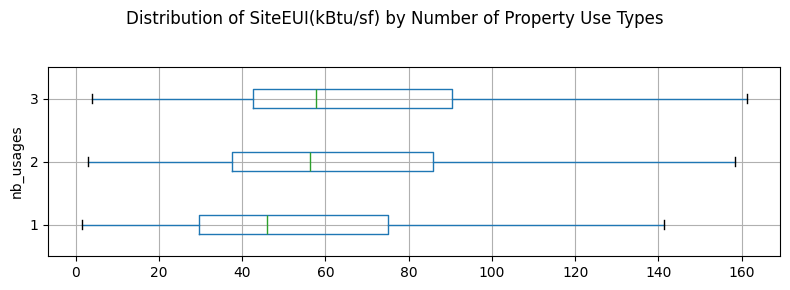

In [16]:
df_F2 = df_F2.copy()
# Valeur métier forte pour ces colonnes. Etudions l'impact de ces colonnes en regardant l'EUI pour 3 groupes. Groupe 1 = groupe mono type / Groupe 2 = Groupe bi-type / Groupe 3 = Groupe à 3 ou plus de types renseignés.
d = df_F2[df_F2['SiteEUI(kBtu/sf)'] > 0]
nb = 1 + d[['SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']].notna().sum(axis=1)
print(d.groupby(nb)['SiteEUI(kBtu/sf)'].agg(['size', 'median', 'mean']).round(1))
print(d['SecondLargestPropertyUseType'].value_counts().head(3))

# Create the figure and axes explicitly for better control
fig, ax = plt.subplots(figsize=(8, 3))

# Generate the boxplot on the created axes
d.assign(nb_usages=nb).boxplot(column='SiteEUI(kBtu/sf)', by='nb_usages', vert=False, showfliers=False, ax=ax)

# Clear the automatically generated title that overlaps the x-axis label
ax.set_title('')

# Set a new, descriptive title for the entire figure
fig.suptitle('Distribution of SiteEUI(kBtu/sf) by Number of Property Use Types')

# Adjust layout to prevent elements from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to leave space for suptitle

plt.show()

Le découpage par nombre d'usages ne démontre pas d'effet exploitable : l'écart plateaue et les quartiles se chevauchent.

Mais ces vides ne sont pas des données manquantes : `NaN` = « un seul usage ». On répare la sémantique, on n'impute pas — `fillna('Non déclaré')`, puis One-Hot avec la cardinalité plafonnée au top-N par fréquence (calculé sur le train).

Réparées, ces colonnes passent F2 sans exception à la règle des 20 %.

Décision différée : l'apport sera mesuré par ablation en modélisation, famille par famille — un arbre ignore une variable inutile sans coût, un noyau RBF non.

In [17]:
COLS_USAGE = ['SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']
df_F2[COLS_USAGE] = df_F2[COLS_USAGE].fillna('Non déclaré')
print("Valeur uniques de ThirdLargestPropertyUseType :")
print(df_F2['ThirdLargestPropertyUseType'].unique())

Valeur uniques de ThirdLargestPropertyUseType :
['Non déclaré' 'Restaurant' 'Swimming Pool' 'Data Center' 'Office'
 'Retail Store' 'Other - Entertainment/Public Assembly'
 'Non-Refrigerated Warehouse' 'Other' 'Distribution Center' 'Food Service'
 'Other - Services' 'Medical Office' 'Parking' 'Other - Utility'
 'K-12 School' 'Fitness Center/Health Club/Gym' 'Social/Meeting Hall'
 'Pre-school/Daycare' 'Convenience Store without Gas Station'
 'Financial Office' 'Other - Restaurant/Bar' 'Other - Education'
 'Multifamily Housing' 'Laboratory' 'Bank Branch' 'Hotel'
 'Personal Services (Health/Beauty, Dry Cleaning, etc)'
 'Other - Recreation' 'Self-Storage Facility' 'Other - Technology/Science'
 'Refrigerated Warehouse' 'Bar/Nightclub' 'Manufacturing/Industrial Plant'
 'Other/Specialty Hospital' 'Fast Food Restaurant' 'Worship Facility'
 'Supermarket/Grocery Store' 'Strip Mall' 'Vocational School']


##### Traitement des colonnes PropertyUseTypeGFA 2nd et 3th

In [18]:
df_F2 = df_F2.copy()
# Problématique simple. NaN = 0 car le batiment ne possede pas de seconde ou troisieme type donc pas de surface.
COLS_GFA = ['SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']
df_F2[COLS_GFA] = df_F2[COLS_GFA].fillna(0)
df_F2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1651 entries, 0 to 3375
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1651 non-null   int64  
 1   BuildingType                     1651 non-null   object 
 2   PrimaryPropertyType              1651 non-null   object 
 3   PropertyName                     1651 non-null   object 
 4   Address                          1651 non-null   object 
 5   ZipCode                          1635 non-null   float64
 6   TaxParcelIdentificationNumber    1651 non-null   object 
 7   CouncilDistrictCode              1651 non-null   int64  
 8   Neighborhood                     1651 non-null   object 
 9   Latitude                         1651 non-null   float64
 10  Longitude                        1651 non-null   float64
 11  YearBuilt                        1651 non-null   int64  
 12  NumberofBuildings        

In [19]:
df_F2 = df_F2.copy()
# Problématique simple. NaN = 0 car le batiment ne possede pas de seconde ou troisieme type donc pas de surface.
COLS_GFA = ['SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']
df_F2[COLS_GFA] = df_F2[COLS_GFA].fillna(0)
df_F2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1651 entries, 0 to 3375
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1651 non-null   int64  
 1   BuildingType                     1651 non-null   object 
 2   PrimaryPropertyType              1651 non-null   object 
 3   PropertyName                     1651 non-null   object 
 4   Address                          1651 non-null   object 
 5   ZipCode                          1635 non-null   float64
 6   TaxParcelIdentificationNumber    1651 non-null   object 
 7   CouncilDistrictCode              1651 non-null   int64  
 8   Neighborhood                     1651 non-null   object 
 9   Latitude                         1651 non-null   float64
 10  Longitude                        1651 non-null   float64
 11  YearBuilt                        1651 non-null   int64  
 12  NumberofBuildings        

#### Analyse métier sur les lignes à valeur nulles

In [20]:
# A — cibler explicitement les targets
df_F2 = df_F2.copy()
TARGETS = ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)']
df_F2 = df_F2.dropna(subset=TARGETS)
df_F2.shape

(1649, 39)

### F3 Filtre sur les features PII/metadata

In [21]:
# F3 : quatrième filtre sur les features à caractère d'identification/PII, Metadata
df_F2 = df_F2.copy()
pii_columns=['OSEBuildingID','PropertyName', 'Address', 'TaxParcelIdentificationNumber', 'ZipCode', 'CouncilDistrictCode']
df_F3 = df_F2.drop(columns=pii_columns, errors='ignore')
print(df_F3.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1649 entries, 0 to 3375
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BuildingType                     1649 non-null   object 
 1   PrimaryPropertyType              1649 non-null   object 
 2   Neighborhood                     1649 non-null   object 
 3   Latitude                         1649 non-null   float64
 4   Longitude                        1649 non-null   float64
 5   YearBuilt                        1649 non-null   int64  
 6   NumberofBuildings                1649 non-null   float64
 7   NumberofFloors                   1649 non-null   int64  
 8   PropertyGFATotal                 1649 non-null   int64  
 9   PropertyGFAParking               1649 non-null   int64  
 10  PropertyGFABuilding(s)           1649 non-null   int64  
 11  ListOfAllPropertyUseTypes        1649 non-null   object 
 12  LargestPropertyUseType   

### F4 Filtre sur les meta-data

In [22]:
df_F4 = df_F3.copy()
META_COLUMNS = ['DefaultData', 'ComplianceStatus']

for col in META_COLUMNS:
    print(f"Valeurs uniques pour '{col}':")
    print(df_F4[col].unique())
    print("\n")

subset_default_true = df_F4[df_F4['DefaultData'] == True]
print("Valeur de Compliance status quand DefaultData est True : \n {} \n".format(subset_default_true['ComplianceStatus'].unique()))
# Il vient d'être démontré que une colinéarité parfait entre la valeur 'Error - Correct Default Data' de la colonne ComplianceStatus et la valeur True de DefaultData
subset_missing_data = df_F4[df_F4['ComplianceStatus'] == 'Missing Data']
print("Nombre de batiment quand ComplianceStatus est Missing Data : {} \n".format(len(subset_missing_data['DefaultData'])))
subset_non_compliant = df_F4[df_F4['ComplianceStatus'] == 'Non-Compliant']
print("Nombre de batiment quand ComplianceStatus est Non Compliant : {} \n".format(len(subset_non_compliant['DefaultData'])))
# OK appliquer le filtre pour ne garder que les batiments Compliant permet de se rapprocher du dataset du rapport d'analyse du benchmark de 2016, cela représente 15 batiments.
subset_complient = df_F4[df_F4['ComplianceStatus'] == 'Compliant']
df_F4 = df_F4[df_F4['ComplianceStatus'].eq('Compliant')].drop(columns=META_COLUMNS)
print(f"{len(df_F3)} -> {len(df_F4)} bâtiments conformes")

Valeurs uniques pour 'DefaultData':
[False  True]


Valeurs uniques pour 'ComplianceStatus':
['Compliant' 'Error - Correct Default Data' 'Missing Data' 'Non-Compliant']


Valeur de Compliance status quand DefaultData est True : 
 ['Error - Correct Default Data'] 

Nombre de batiment quand ComplianceStatus est Missing Data : 14 

Nombre de batiment quand ComplianceStatus est Non Compliant : 1 

1649 -> 1548 bâtiments conformes


### F5 Filtre sur les features target / Data Leakage

> **Note.** F5 écarte les mesures de la campagne 2016 mais **conserve les deux cibles** :
> `TotalGHGEmissions` et `SiteEnergyUse(kBtu)` sont modélisées en parallèle à partir de la
> section Modélisation.

In [23]:
# F5 : cinquième filtre sur les features target / Data Leakage
# y = ['TotalGHGEmissions','SiteEnergyUse(kBtu)'] # ne pas supprimer les targets
data_leakage_columns = [
    'GHGEmissionsIntensity', 'SourceEUIWN(kBtu/sf)',
    'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
    'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)',
]
df_F5 = df_F4.copy()
df_F5 = df_F4.drop(columns=data_leakage_columns)
print(df_F5.shape)

(1548, 20)


### F6 Filtre sur les colinéarités

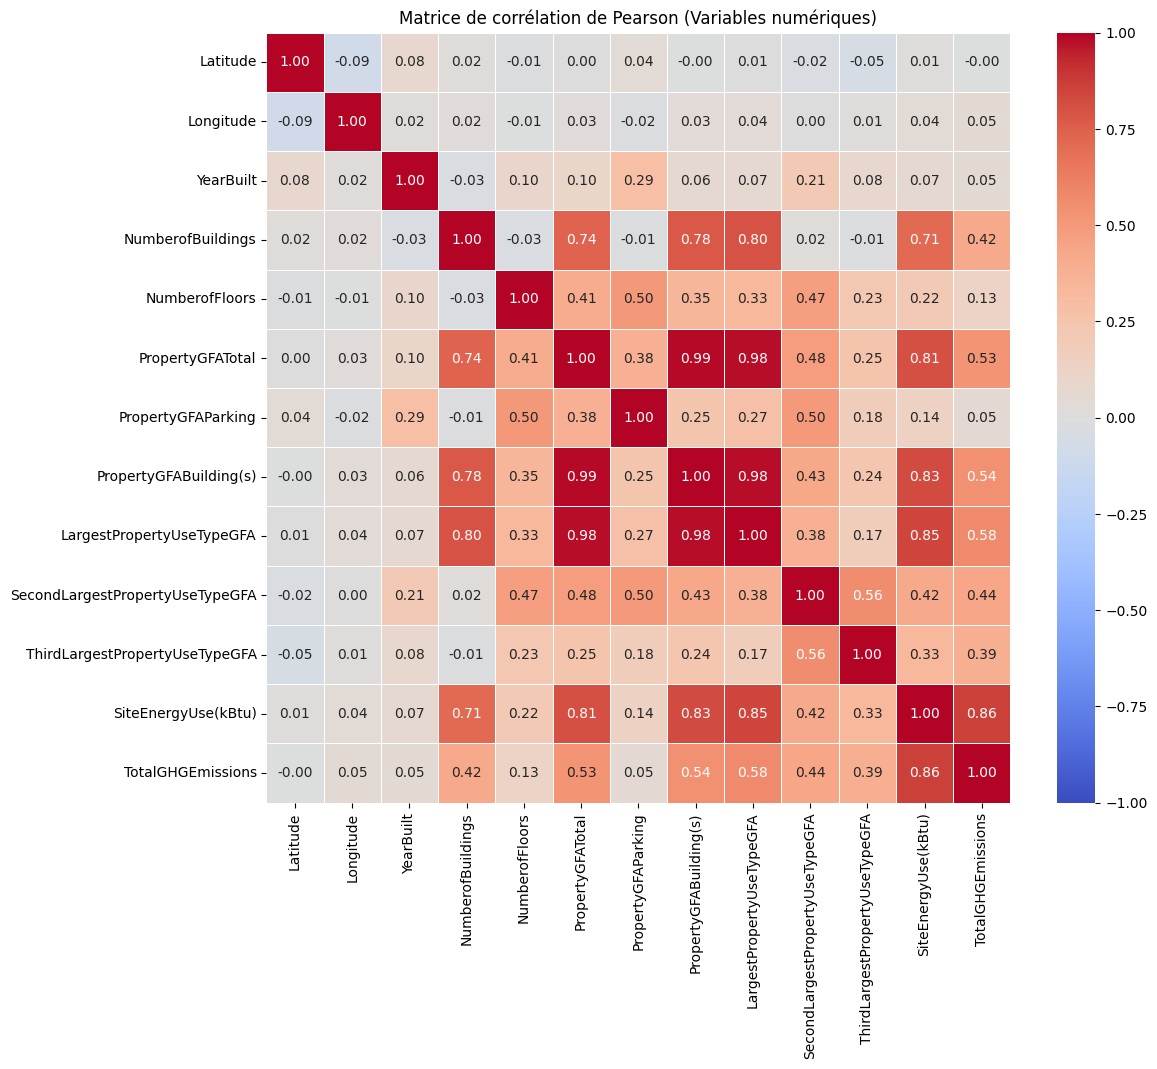

In [24]:
df_F6 = df_F5.copy()
# On isole uniquement les variables numériques (incluant la nouvelle Target)
df_num = df_F6.select_dtypes(include=['float64', 'int64'])

# Calcul de la matrice de corrélation
matrice_corr = df_num.corr()

# Affichage graphique
plt.figure(figsize=(12, 10))
sns.heatmap(
    matrice_corr,
    annot=True,       # Affiche les chiffres dans les cases
    fmt=".2f",        # 2 chiffres après la virgule
    cmap="coolwarm",  # Rouge pour corrélation positive, bleu pour négative
    vmin=-1, vmax=1,  # L'échelle va de -1 à 1
    linewidths=0.5
)
plt.title("Matrice de corrélation de Pearson (Variables numériques)")
plt.show()

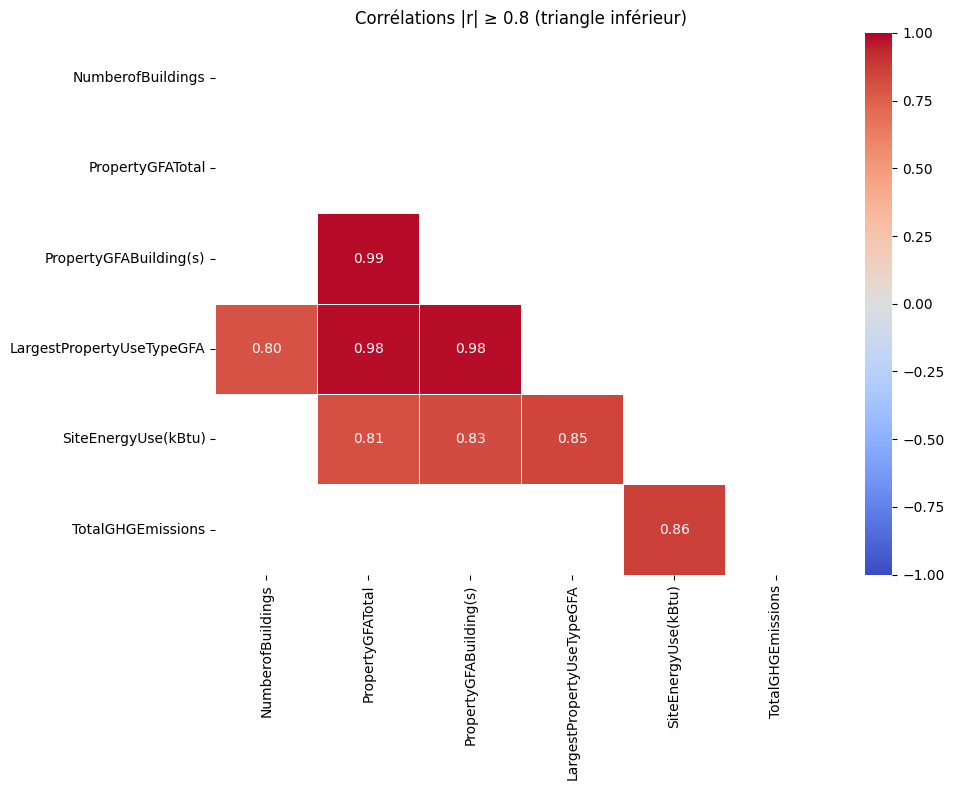

,var_1,var_2,r
26,PropertyGFABuilding(s),PropertyGFATotal,0.990378
35,LargestPropertyUseTypeGFA,PropertyGFABuilding(s),0.982383
33,LargestPropertyUseTypeGFA,PropertyGFATotal,0.977735
77,TotalGHGEmissions,SiteEnergyUse(kBtu),0.860023
63,SiteEnergyUse(kBtu),LargestPropertyUseTypeGFA,0.846843
62,SiteEnergyUse(kBtu),PropertyGFABuilding(s),0.826227
60,SiteEnergyUse(kBtu),PropertyGFATotal,0.809627
31,LargestPropertyUseTypeGFA,NumberofBuildings,0.801144


In [25]:
SEUIL = 0.80
corr = df_F6.select_dtypes('number').corr()
haut = np.triu(np.ones_like(corr, dtype=bool))       # triangle supérieur + diagonale
fort = (corr.abs() >= SEUIL) & ~haut
garde = fort.any(axis=1) | fort.any(axis=0)          # ne garder que les variables concernées
c = corr.loc[garde, garde]

plt.figure(figsize=(10, 8))
sns.heatmap(c, mask=np.triu(np.ones_like(c, dtype=bool)) | (c.abs() < SEUIL),
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=.5)
plt.title(f"Corrélations |r| ≥ {SEUIL} (triangle inférieur)")
plt.tight_layout(); plt.show()

# La liste de paires est plus actionnable que la carte pour arbitrer
paires = (corr.where(~haut).stack().rename('r').reset_index()
            .rename(columns={'level_0': 'var_1', 'level_1': 'var_2'}))
display(paires[paires['r'].abs() >= SEUIL]
        .reindex(paires['r'].abs().sort_values(ascending=False).index).dropna())

L'étude de la matrice de corrélation nous révèles les variables redondantes qui n'apportent aucunes informations **supplémentaires**.

|var\_1|var\_2|Action|
|---|---|---|
|PropertyGFABuilding\(s\)|PropertyGFATotal|drop GFA Total car non atomique|
|LargestPropertyUseTypeGFA|PropertyGFABuilding\(s\)|Drop de LargestPropertyUseTypeGFA car non atomique|
|LargestPropertyUseTypeGFA|PropertyGFATotal|les deux sont drops|
|TotalGHGEmissions|SiteEnergyUse\(kBtu\)|ceux sont les targets pas de prob|

In [26]:
df_F6.drop(columns=['PropertyGFATotal', 'LargestPropertyUseTypeGFA'], inplace=True)
print(df_F6.shape)

(1548, 18)


## Etude graphique

In [27]:
df_graph = df_F6.copy()

### Etude graphique des variables numériques

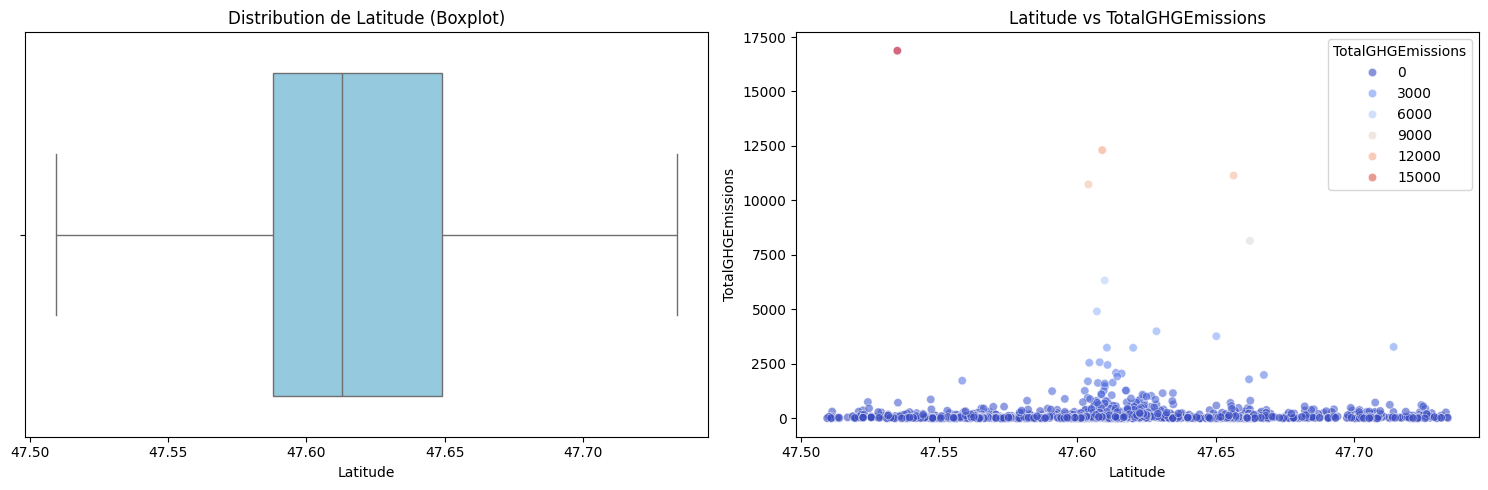

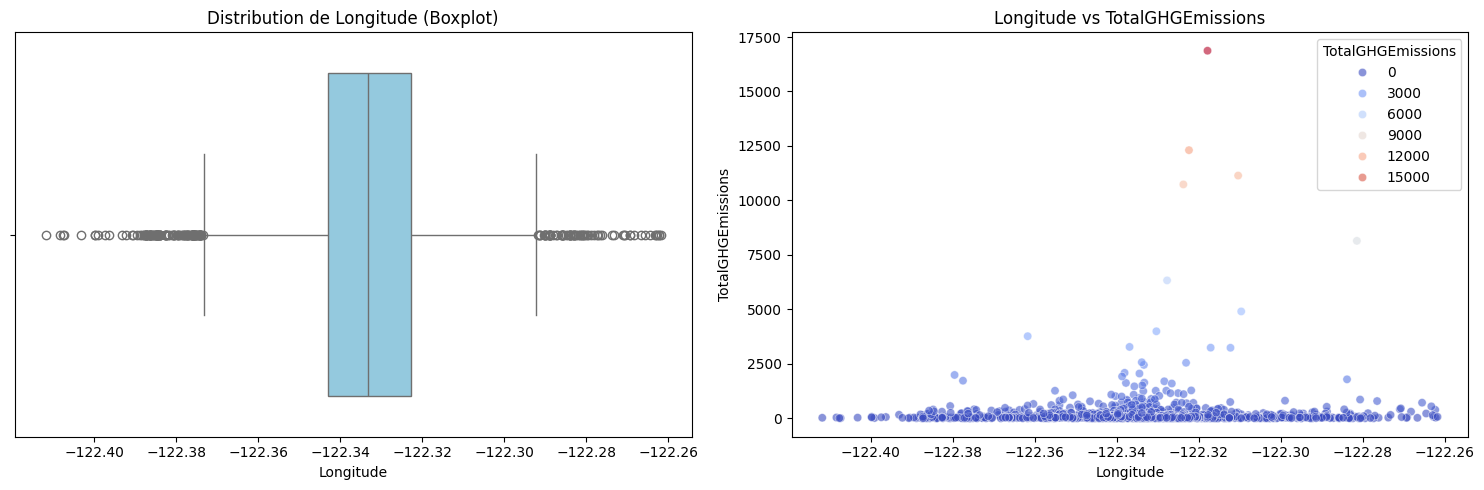

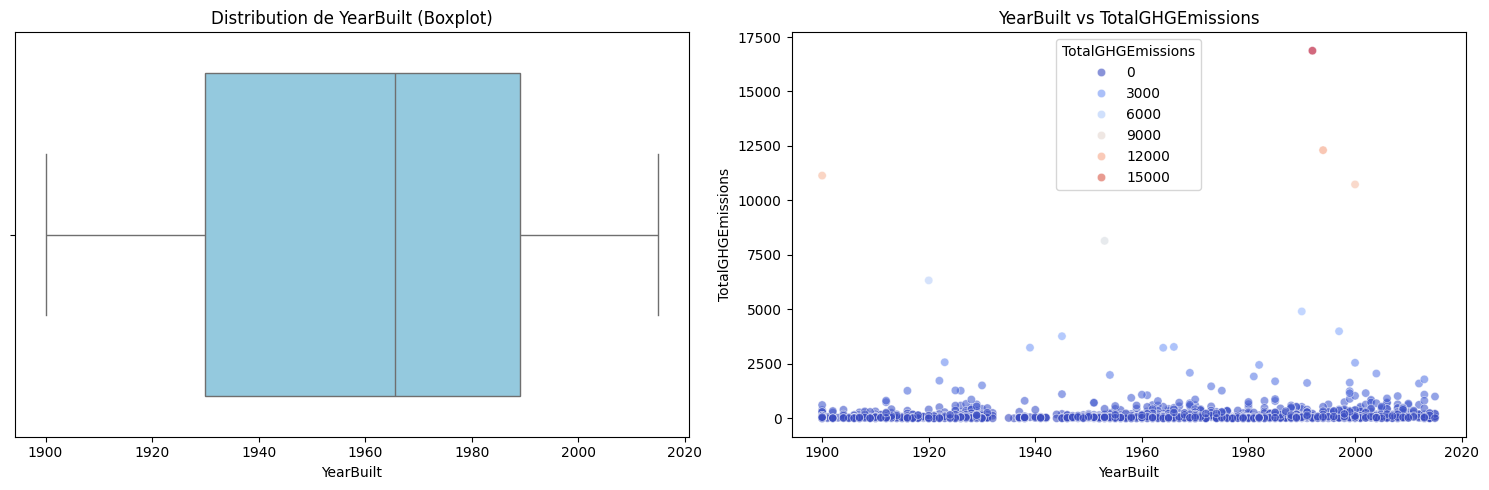

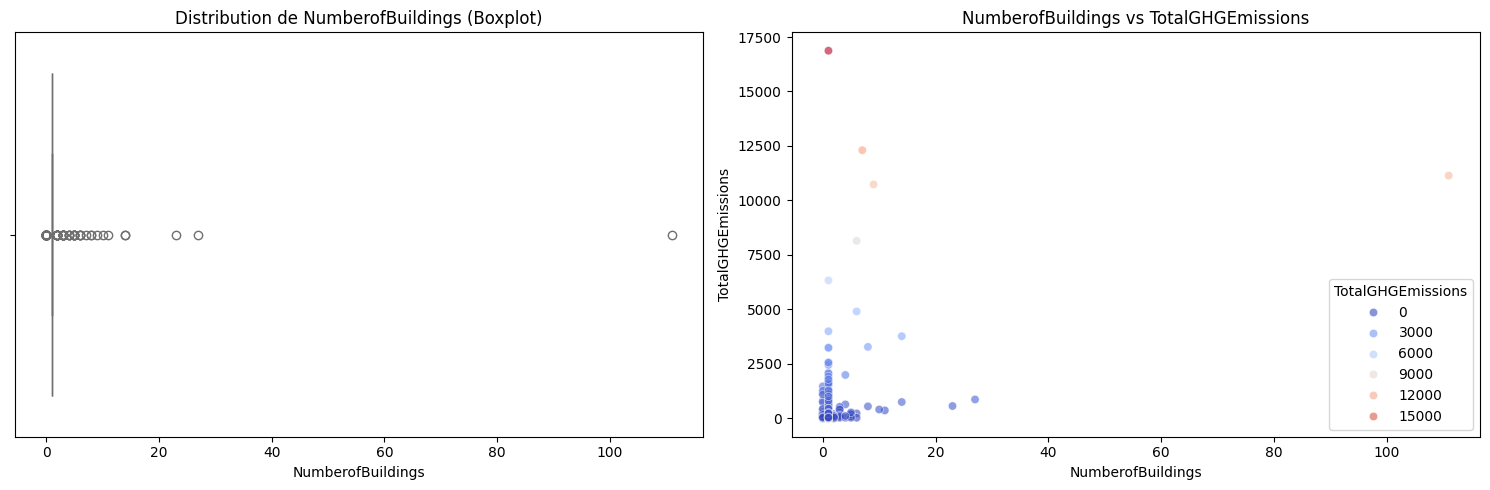

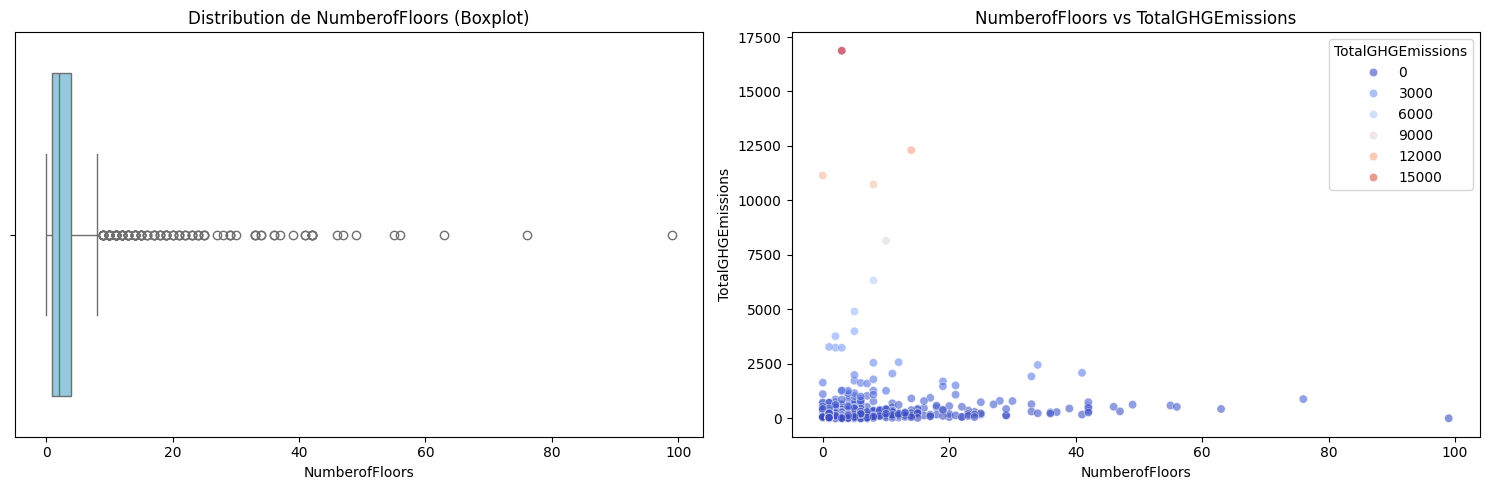

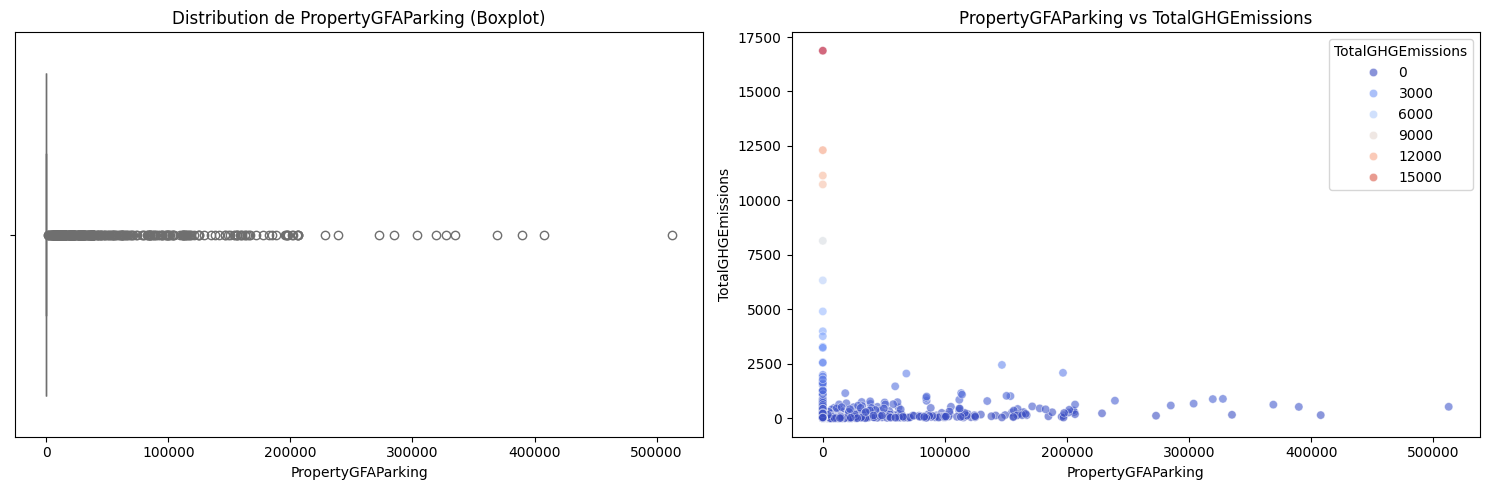

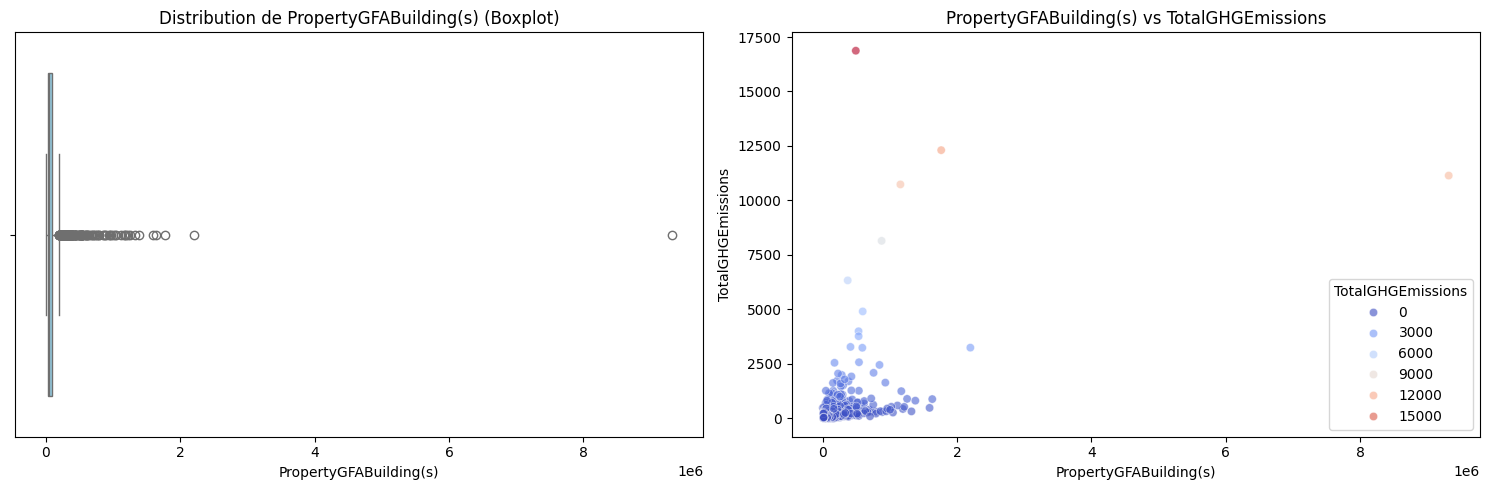

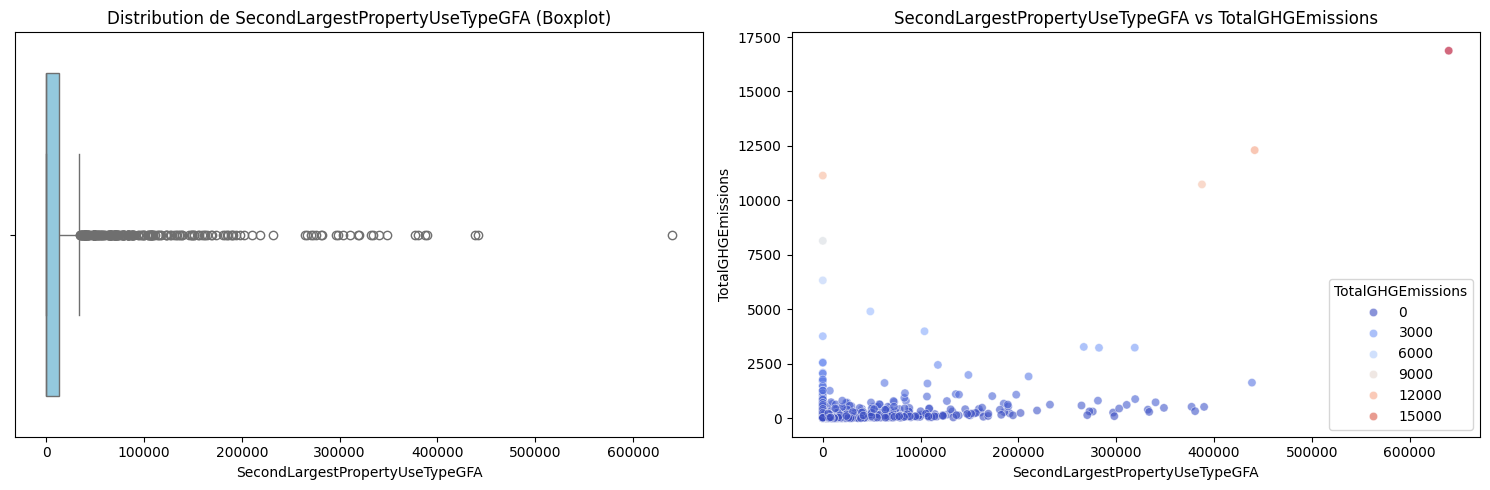

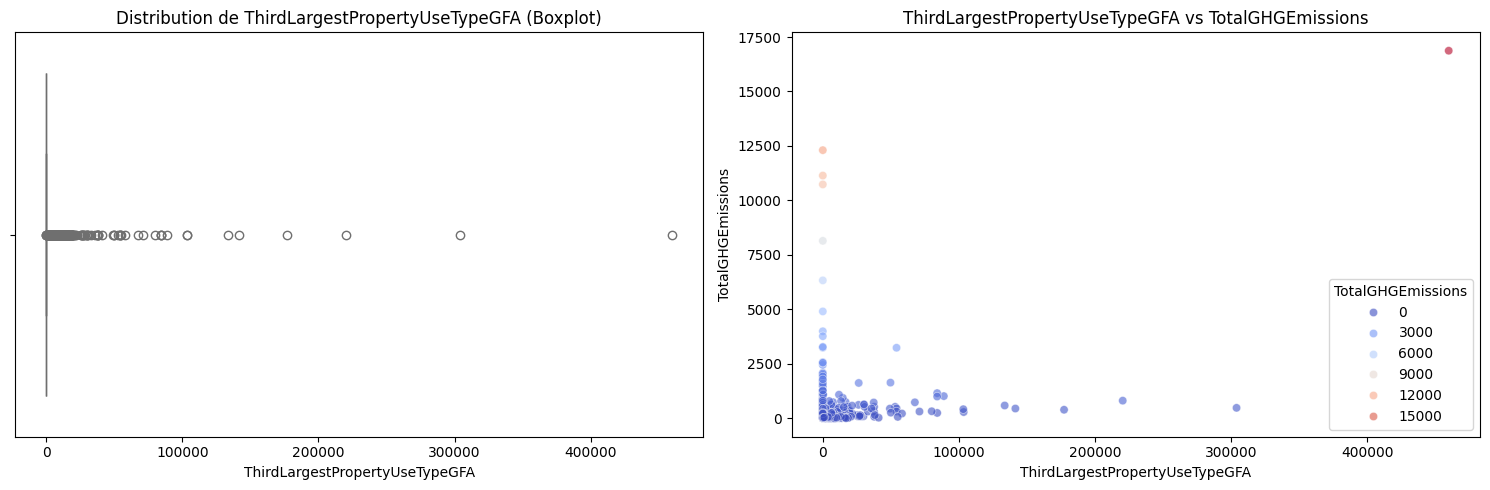

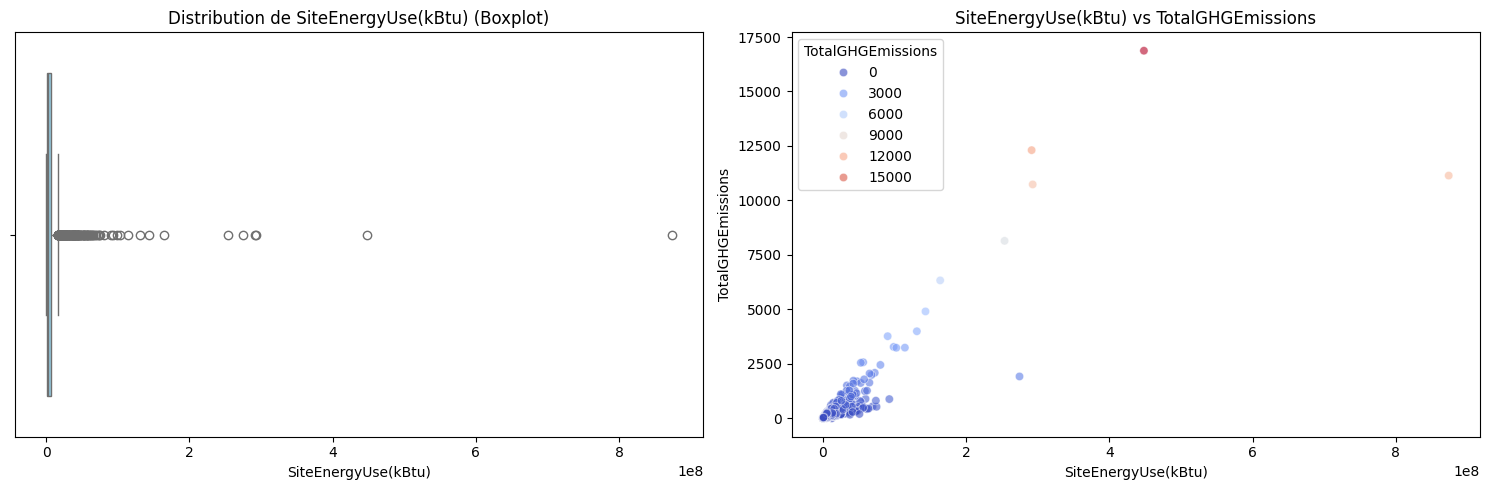

In [28]:
plot_num(df_graph)

In [29]:
# Calculer le coefficient d'asymétrie pour toutes les variables numériques
asymetrie = df_graph.select_dtypes(include=['float64', 'int64']).skew()

# Afficher les variables qui dépassent le seuil critique de 1
print(asymetrie[asymetrie > 1].sort_values(ascending=False))

NumberofBuildings                  31.360672
PropertyGFABuilding(s)             21.306812
SiteEnergyUse(kBtu)                17.475184
ThirdLargestPropertyUseTypeGFA     14.966445
TotalGHGEmissions                  13.723389
NumberofFloors                      5.841853
SecondLargestPropertyUseTypeGFA     5.043432
PropertyGFAParking                  5.025097
dtype: float64


### Etude graphique des variables catégorielles

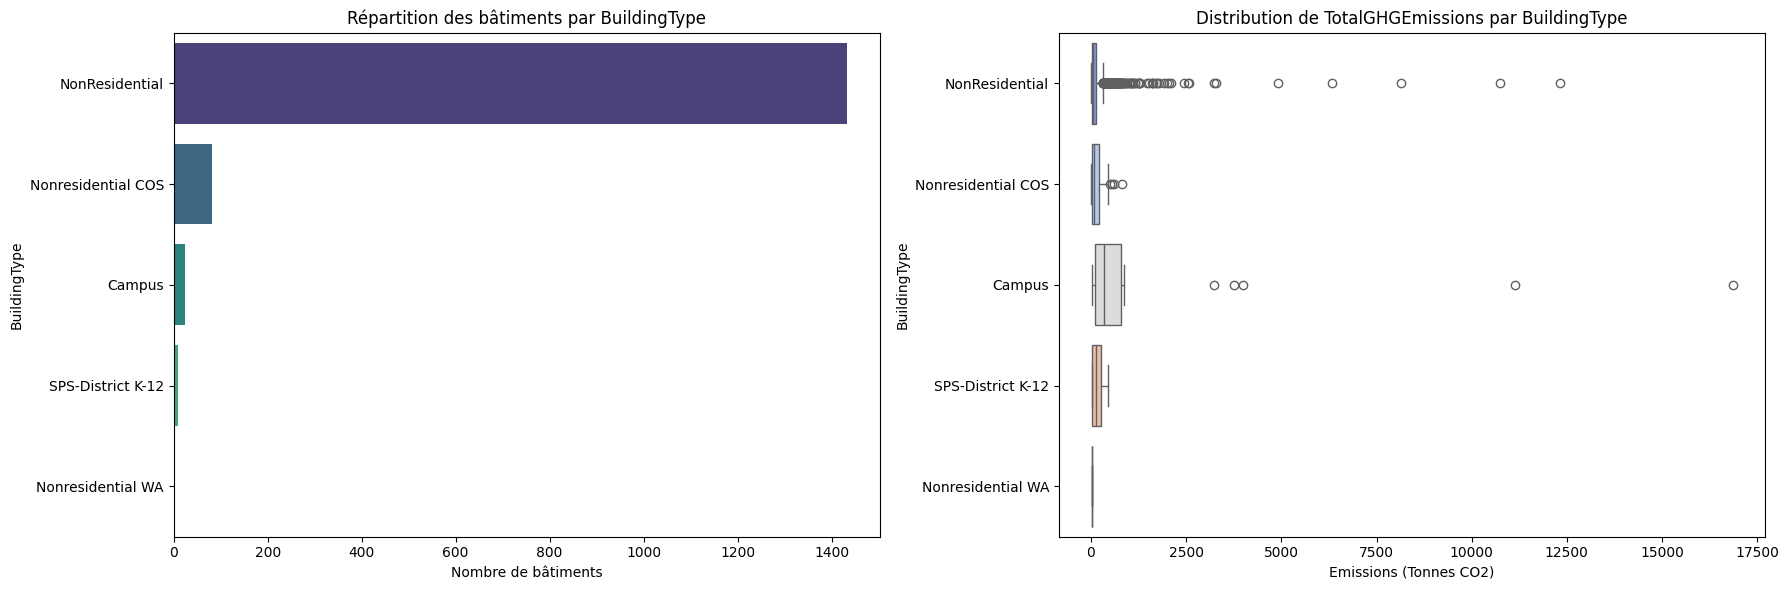

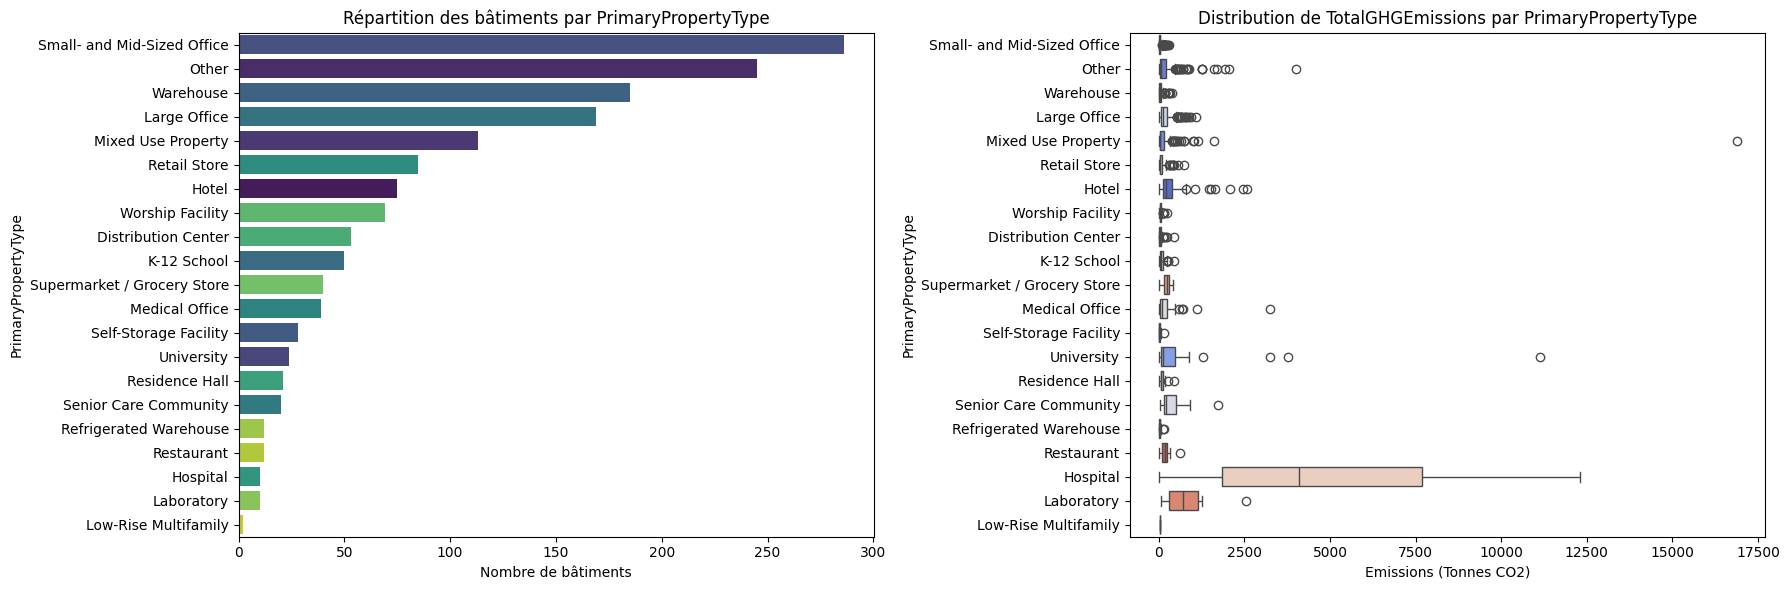

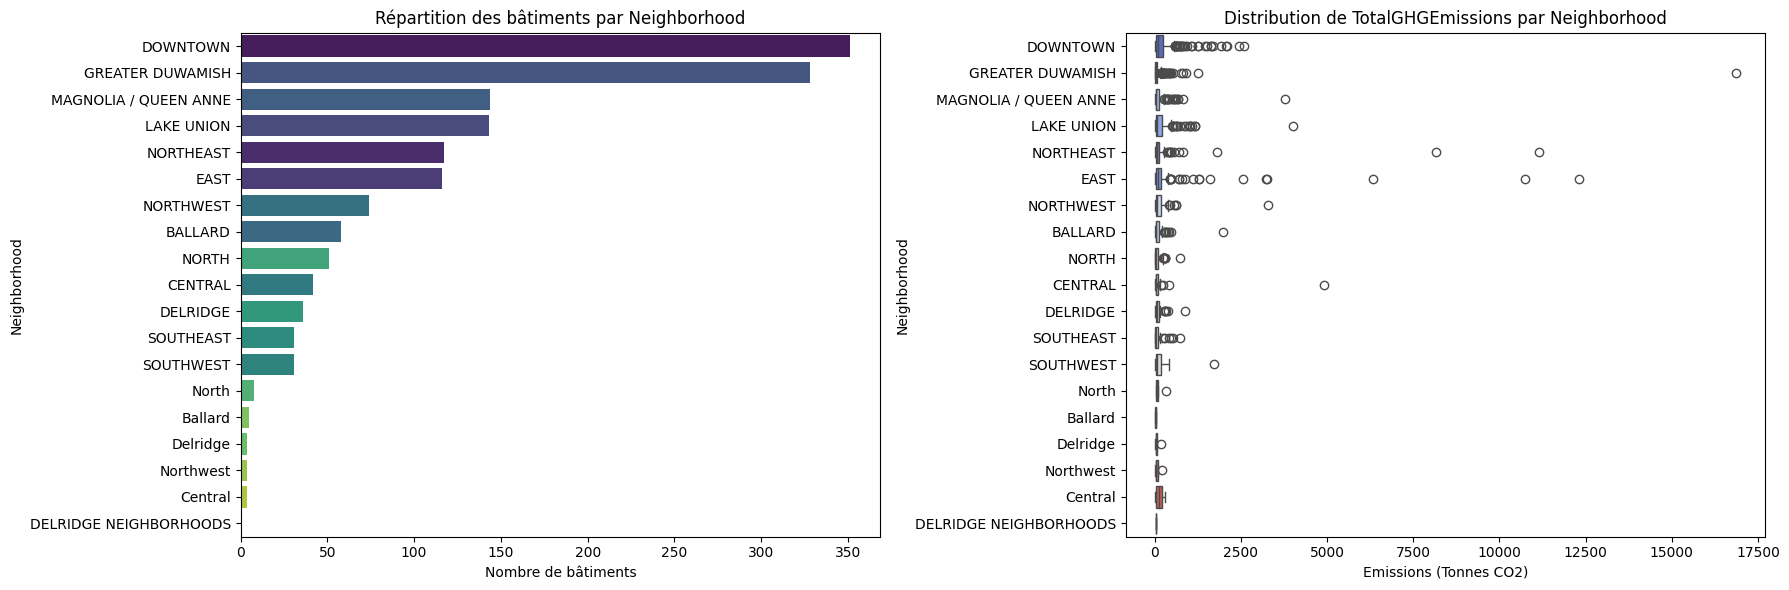

In [30]:
plot_cat(df_graph)

#### F8 Correction des doublons de case sensitivity pour 'Neighborhood'

Dataframe shape avant : (1548, 18)
Neighborhood
DOWNTOWN                  351
GREATER DUWAMISH          328
MAGNOLIA / QUEEN ANNE     144
LAKE UNION                143
NORTHEAST                 117
EAST                      116
NORTHWEST                  78
BALLARD                    63
NORTH                      59
CENTRAL                    46
DELRIDGE                   40
SOUTHWEST                  31
SOUTHEAST                  31
DELRIDGE NEIGHBORHOODS      1
Name: count, dtype: int64
Dataframe shape après : (1548, 18)


<Axes: xlabel='count', ylabel='Neighborhood'>

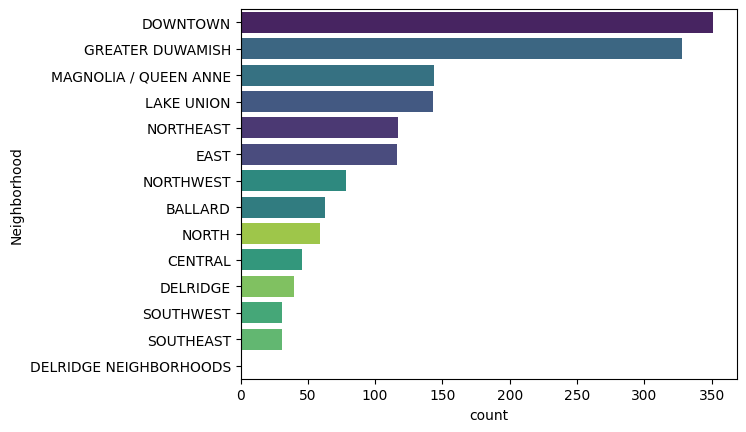

In [31]:
print("Dataframe shape avant : {}".format(df_graph.shape))
df_F8 = df_graph.copy()
# On met tout en majuscules et on enlève les espaces invisibles avant/après
df_F8['Neighborhood'] = df_F8['Neighborhood'].str.upper().str.strip()
target_col = 'TotalGHGEmissions'
feature = 'Neighborhood'
# Vérifions le nouveau compte (vous verrez que la traîne a disparu !)
print(df_F8['Neighborhood'].value_counts())
print("Dataframe shape après : {}".format(df_F8.shape))
sns.countplot(
    data=df_F8,
    y=feature,
    hue=feature,
    palette='viridis',
    order=df_F8[feature].value_counts().index,
)

/tmp/ipykernel_3530/2330909617.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


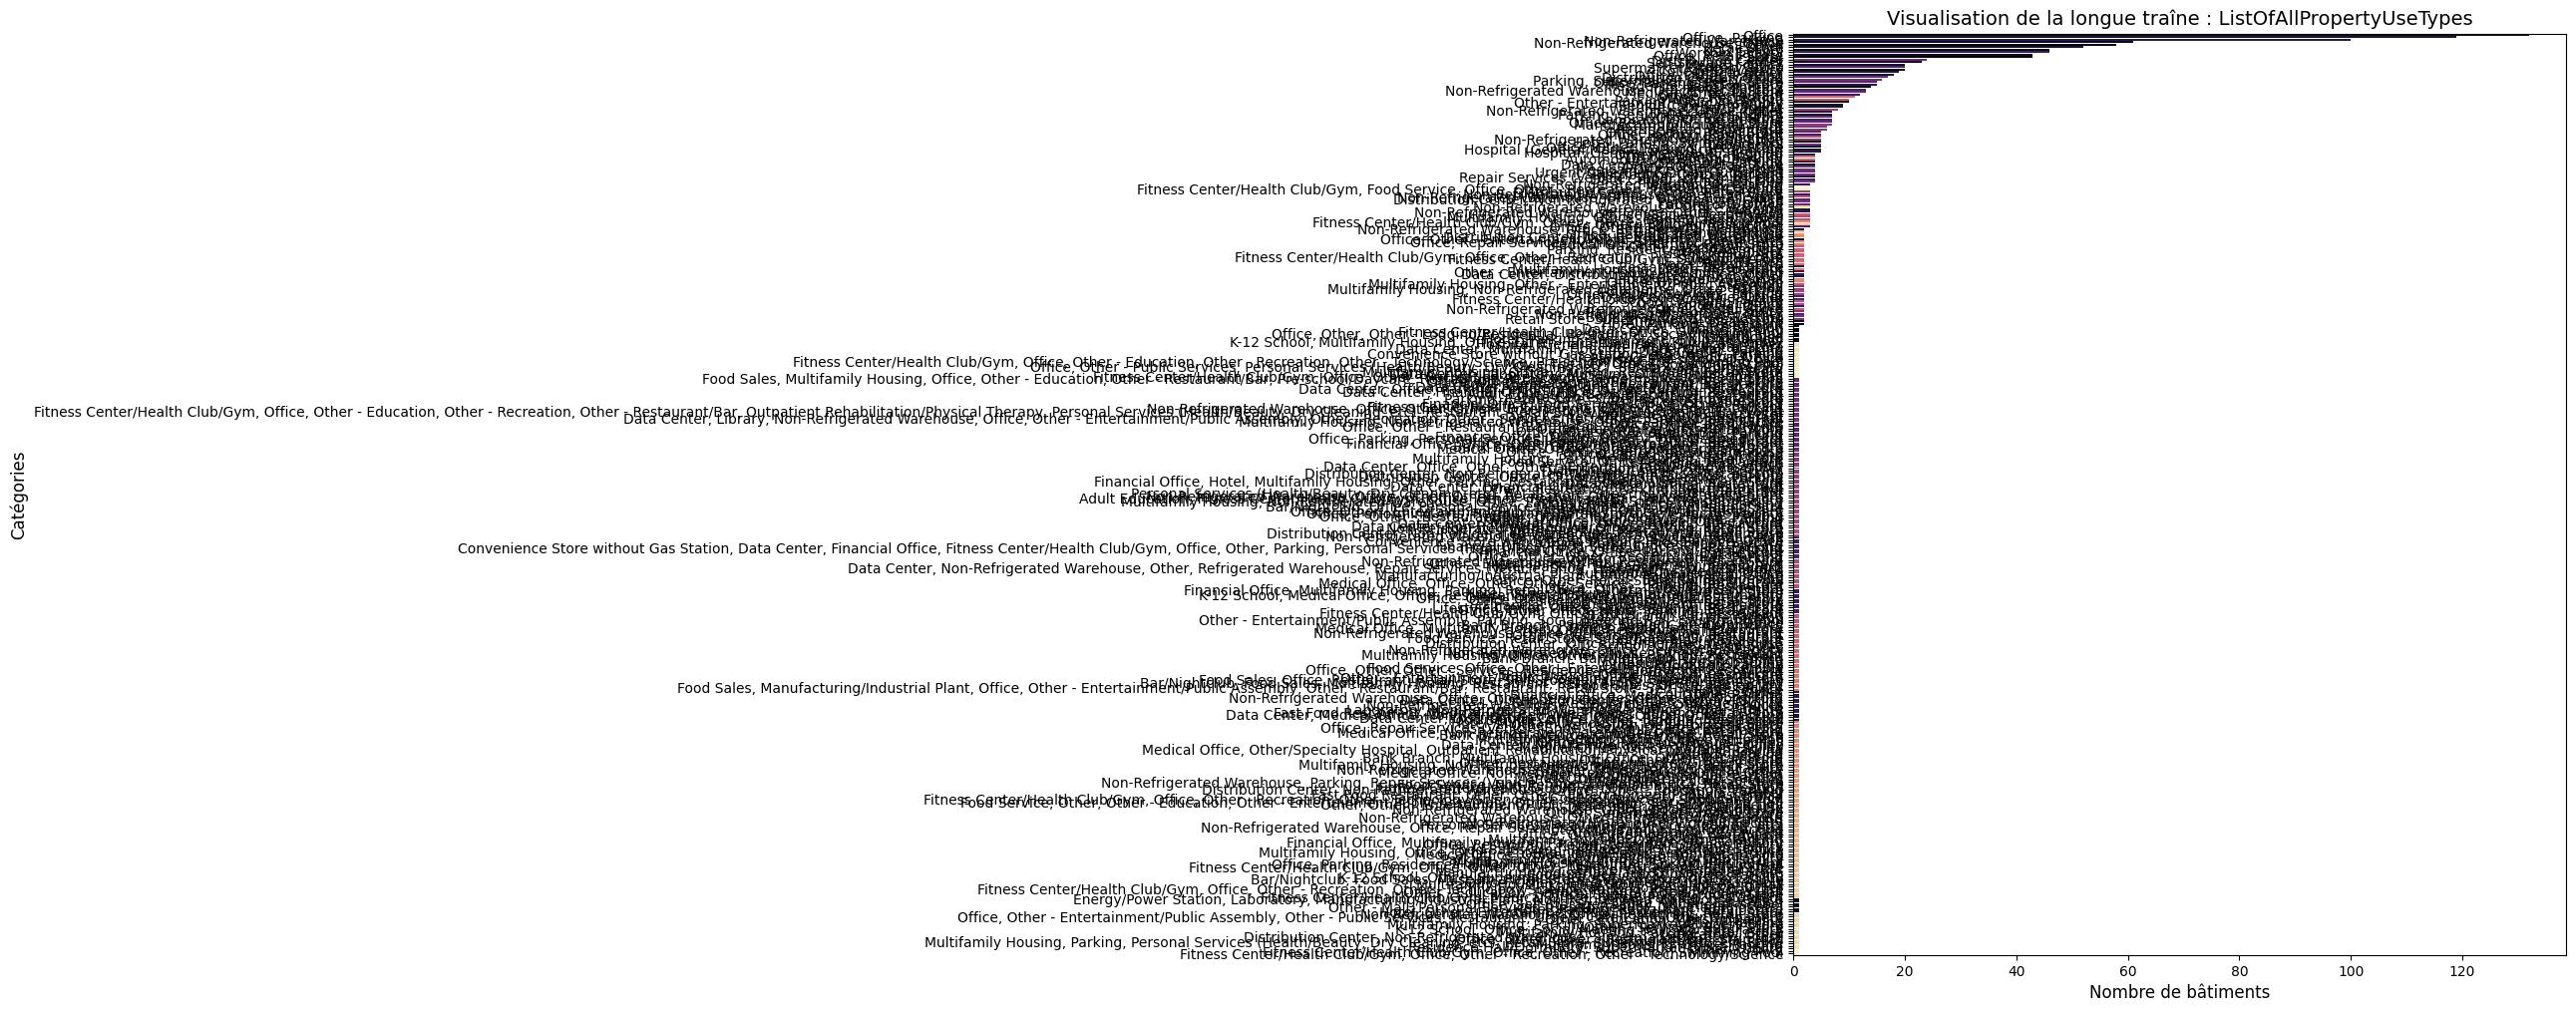

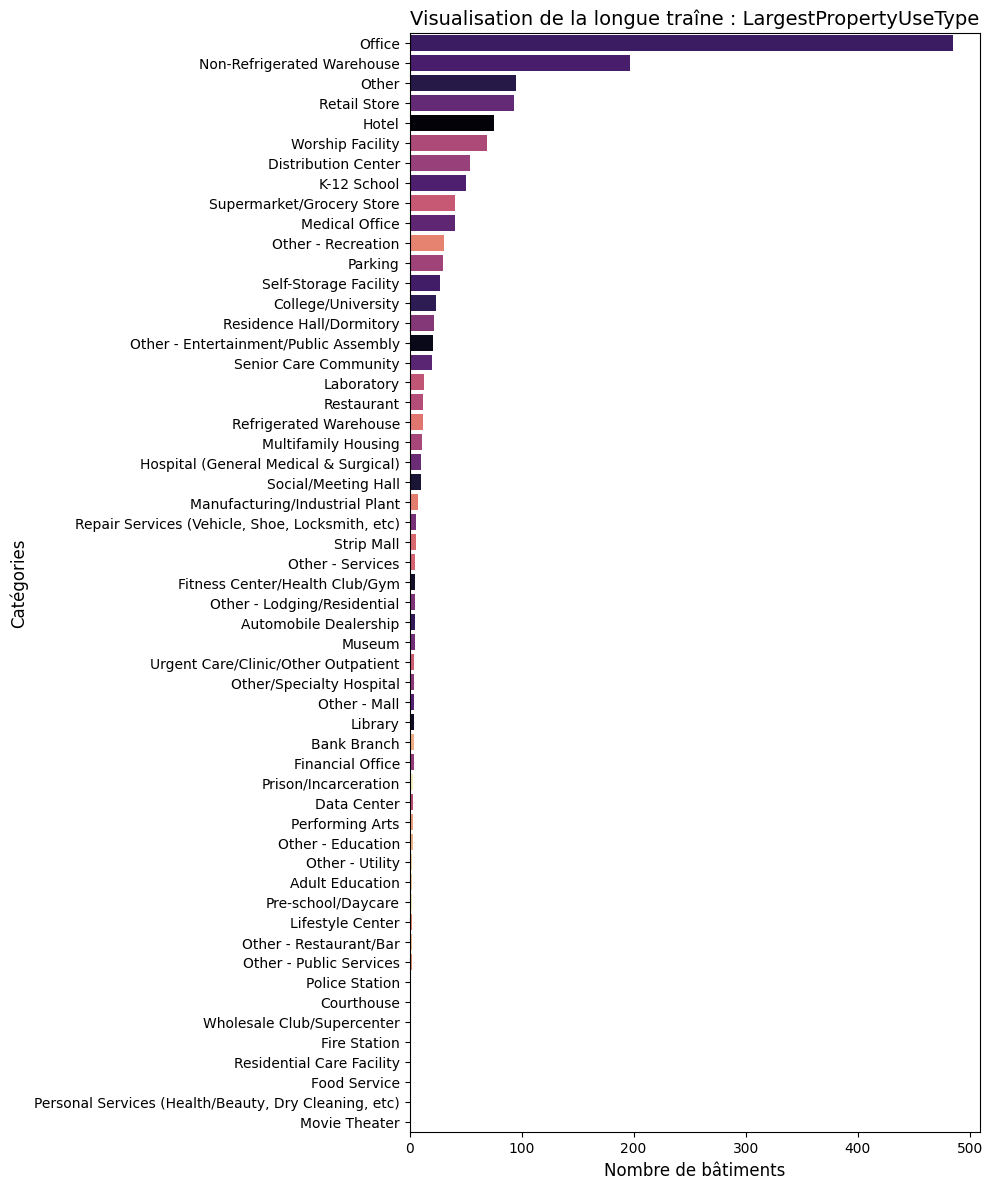

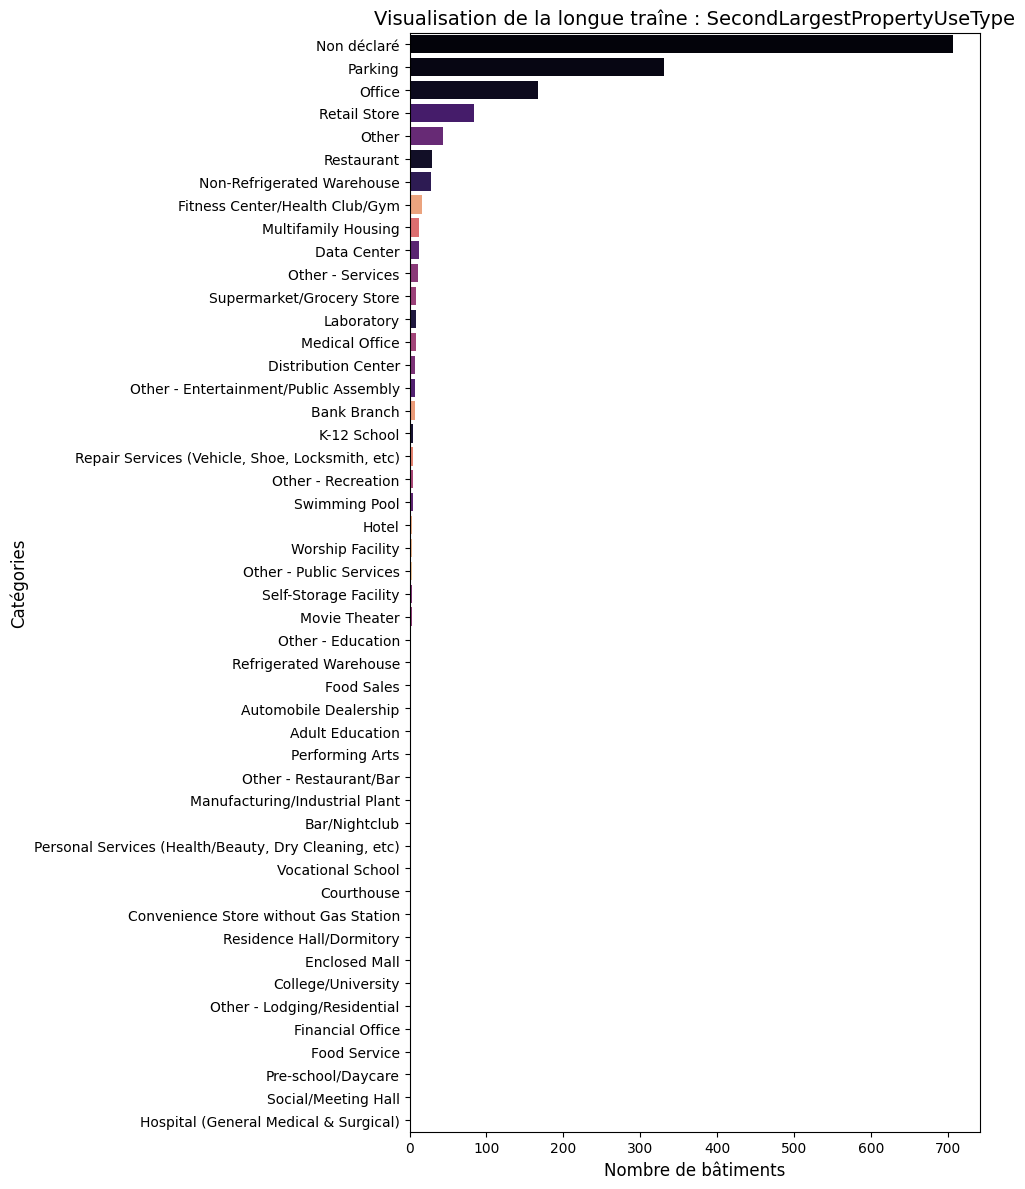

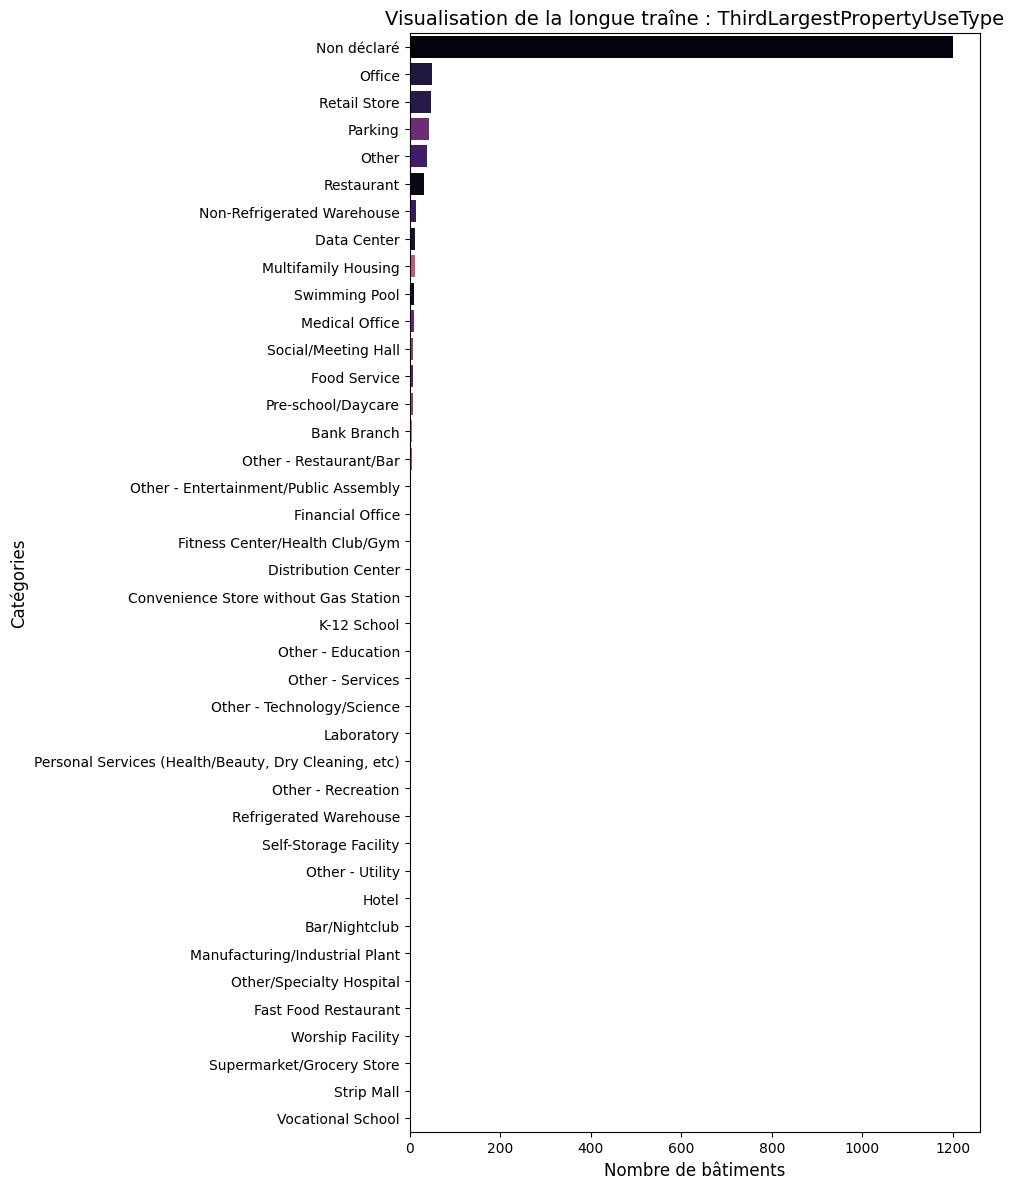

In [32]:
# 1. Isoler les variables textuelles
df_cat = df_F8.select_dtypes(include=['object'])

# 2. Garder UNIQUEMENT celles qui ont plus de 30 catégories
colonnes_longue_traine = [col for col in df_cat.columns if df_F8[col].nunique() > 30]

# 3. Tracer la distribution pour chacune d'elles
for feature in colonnes_longue_traine:
    # On crée une figure très haute (ex: 12 pouces) pour que le texte ne se chevauche pas
    plt.figure(figsize=(10, 12))

    # On récupère l'ordre exact du plus fréquent au moins fréquent
    ordre_categories = df_F8[feature].value_counts().index

    # Le Countplot horizontal
    sns.countplot(
        data=df_F8,
        y=feature,
        order=ordre_categories,
        hue=feature,
        legend=False,
        palette='magma' # Palette avec un beau dégradé pour souligner la traînée
    )

    plt.title(f"Visualisation de la longue traîne : {feature}", fontsize=14)
    plt.xlabel("Nombre de bâtiments", fontsize=12)
    plt.ylabel("Catégories", fontsize=12)

    plt.tight_layout()
    plt.show()

#### F9 Filtre sur le bruit d'une variable non atomique

`ListOfAllPropertyUseTypes` est ensembliste : ses valeurs sont des combinaisons, d'où la
cardinalité du graphique ci-dessus. Par rapport aux trois colonnes d'usage, elle n'ajoute que
les usages au-delà du 3ᵉ (X % des bâtiments) et perd l'ordre et les surfaces. Cardinalité
élevée ne vaut pas information : je l'écarte comme métadonnée.

In [33]:
print("Dataframe shape avant : {}".format(df_F8.shape))
df_F9 = df_F8.copy()
df_F9 = df_F9.drop(columns=['ListOfAllPropertyUseTypes'])
print("Dataframe shape après : {}".format(df_F9.shape))

Dataframe shape avant : (1548, 18)
Dataframe shape après : (1548, 17)


### Etude de la Target

In [34]:
df_target_focus = df_F9.copy()

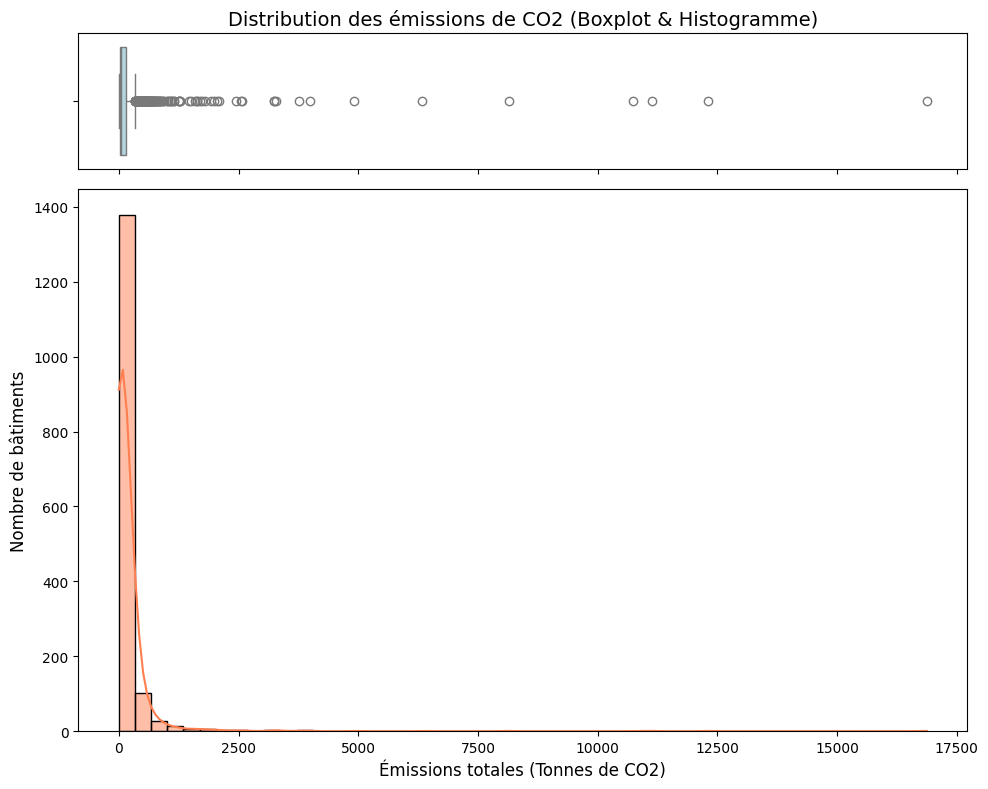

In [35]:
# Création d'une figure avec 2 lignes (une petite pour le boxplot, une grande pour l'histogramme)
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 4]} # Le boxplot prend 1/5 de la hauteur, l'histo 4/5
)

# --- GRAPHIQUE 1 : Le Boxplot (En haut) ---
sns.boxplot(
    data=df_target_focus,
    x='TotalGHGEmissions',
    ax=ax_box,
    color='lightblue'
)
ax_box.set_title("Distribution des émissions de CO2 (Boxplot & Histogramme)", fontsize=14)
ax_box.set_xlabel('') # On cache le texte de l'axe X du boxplot pour ne pas faire doublon

# --- GRAPHIQUE 2 : L'Histogramme (En bas) ---
sns.histplot(
    data=df_target_focus,
    x='TotalGHGEmissions',
    bins=50,
    kde=True,
    ax=ax_hist,
    color='coral'
)
ax_hist.set_xlabel("Émissions totales (Tonnes de CO2)", fontsize=12)
ax_hist.set_ylabel("Nombre de bâtiments", fontsize=12)

# Affichage propre
plt.tight_layout()
plt.show()

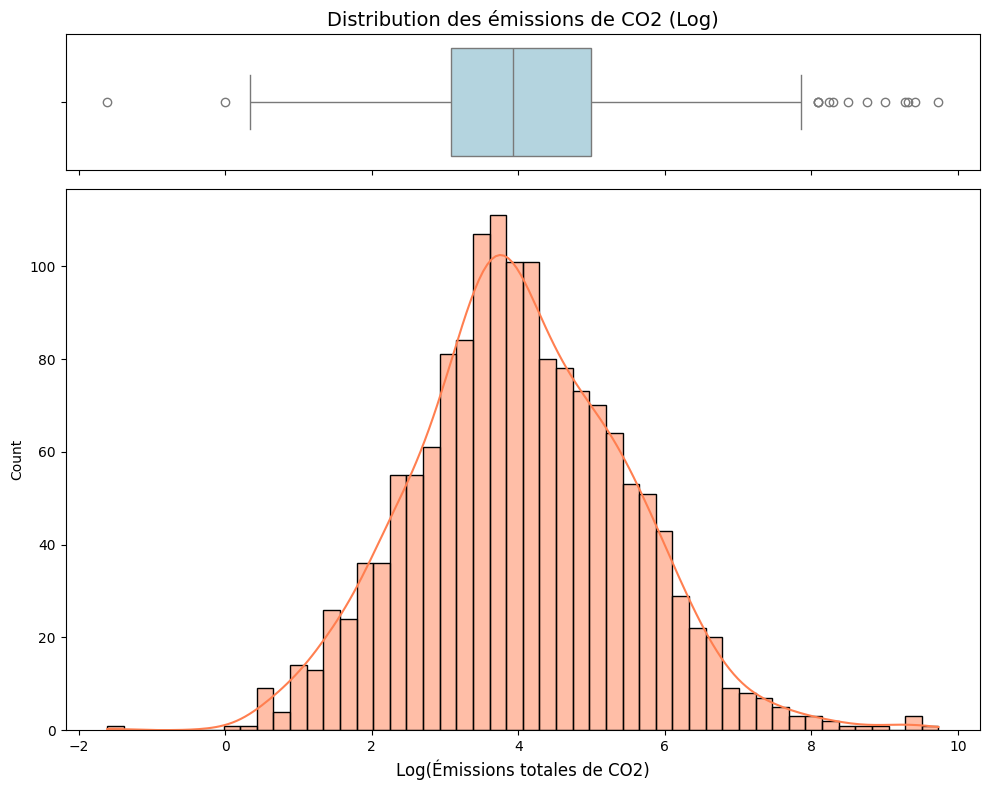

In [36]:
# Dans l'EDA : On calcule le log "à la volée" juste pour le graphique, sans modifier df_target_focus
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [1, 4]})

# On passe np.log1p() directement dans la donnée du graphique
sns.boxplot(x=np.log1p(df_target_focus['TotalGHGEmissions']), ax=ax_box, color='lightblue')
ax_box.set_title("Distribution des émissions de CO2 (Log)", fontsize=14)

sns.histplot(x=np.log1p(df_target_focus['TotalGHGEmissions']), bins=50, kde=True, ax=ax_hist, color='coral')
ax_hist.set_xlabel("Log(Émissions totales de CO2)", fontsize=12)

plt.tight_layout()
plt.show()

#### F10 Filtre les outliers de la target

In [37]:
df_target_focus['TotalGHGEmissions'].describe()

,TotalGHGEmissions
count,1548.000000
mean,193.608908
std,779.105278
min,-0.800000
25%,20.655000
50%,49.845000
75%,147.227500
max,16870.980000


##### Etude des valeurs min et max de la target

In [38]:
ext = df_target_focus.loc[[df_target_focus['TotalGHGEmissions'].idxmin(), df_target_focus['TotalGHGEmissions'].idxmax()]].copy()
ext['maps'] = 'https://maps.google.com/?q=' + ext['Latitude'].astype(str) + ',' + ext['Longitude'].astype(str)
display(ext[['TotalGHGEmissions', 'PrimaryPropertyType', 'PropertyGFABuilding(s)', 'maps']])

,TotalGHGEmissions,PrimaryPropertyType,PropertyGFABuilding(s),maps
3206,-0.80,Small- and Mid-Sized Office,52000,"https://maps.google.com/?q=47.61432,-122.31257"
35,16870.98,Mixed Use Property,494835,"https://maps.google.com/?q=47.53493,-122.31788"


[Batiment emission min](https://maps.google.com/?q=47.61432,-122.31257) --> Bullitt Center ultra Green Workplace
</br>
[Batiment emission max](https://maps.google.com/?q=47.53493,-122.31788)  --> Boeing Factory massive CO2 emetteur

Pour la valeur Max, le cas est particulier cependant je préfère d'abords regarder la distance de valeur entre le top 5 pour reperé le point max parmis les valeurs extrèmes.

Pour la valeur min je la retire bien qu'interessante une valeur négatives va me causer des soucis et le cas est si particulier qu'il n'est pas vraiment représentatif.

max/2e = 1.4× | 2e/3e = 1.1× | 3e/4e = 1.0×


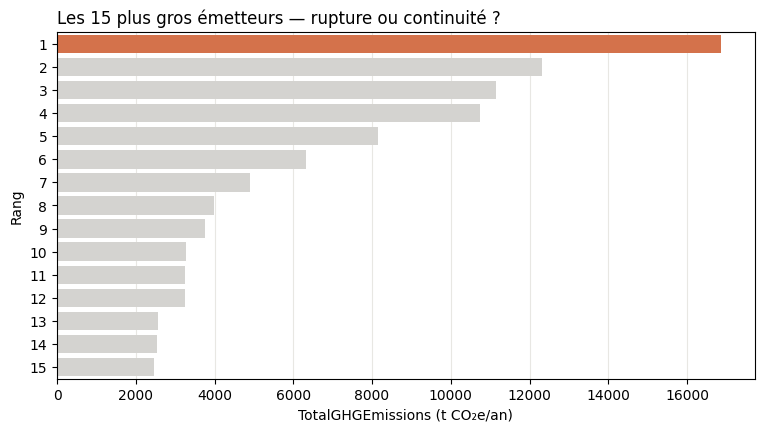

In [39]:
top = df_target_focus.nlargest(15, 'TotalGHGEmissions')['TotalGHGEmissions'].reset_index(drop=True)
print(f"max/2e = {top[0]/top[1]:.1f}× | 2e/3e = {top[1]/top[2]:.1f}× | 3e/4e = {top[2]/top[3]:.1f}×")
plt.figure(figsize=(9, 4.5))
sns.barplot(x=top.values, y=(top.index + 1).astype(str), hue=(top.index == 0),
            palette={True: '#eb6834', False: '#d5d4cf'}, legend=False)
plt.xlabel('TotalGHGEmissions (t CO₂e/an)'); plt.ylabel('Rang')
plt.title("Les 15 plus gros émetteurs — rupture ou continuité ?", loc='left')
plt.grid(axis='x', color='#e8e7e3'); plt.gca().set_axisbelow(True); plt.show()

Ok on garde le max et on retire le min. Cependant je jette un dernier coup d'oeil au batiments avec zéro de renseignés en valeur d'émissions

In [40]:
z = df_F4[df_F4['TotalGHGEmissions'] == 0]
print(f"{len(z)} bâtiments à 0 tonne")
display(z[['SiteEnergyUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)',
           'SteamUse(kBtu)', 'PrimaryPropertyType', 'PropertyGFABuilding(s)']])

1 bâtiments à 0 tonne


,SiteEnergyUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),SteamUse(kBtu),PrimaryPropertyType,PropertyGFABuilding(s)
513,12525174.0,0.0,0.0,0.0,Supermarket / Grocery Store,57176


Ok c'est clair dernier filtre sur TotalGHGEmissions strictement supérieur à 0

In [41]:
print("Dataframe shape avant : {}".format(df_F9.shape))
df_F10 = df_F9.copy()
df_F10 = df_F10[df_F10['TotalGHGEmissions'] > 0]
print("Dataframe shape après : {}".format(df_F10.shape))


Dataframe shape avant : (1548, 17)
Dataframe shape après : (1546, 17)


**Filtre final sur la cible — `TotalGHGEmissions > 0`**

Deux bâtiments écartés, chacun pour une raison identifiée :

- **La valeur minimale (−0,80 t)** est le **Bullitt Center** (1501 E Madison St), bâtiment
  à énergie nette positive : sa production solaire dépasse sa consommation annuelle. La mesure
  est juste, mais aucune caractéristique du registre municipal ne décrit une centrale
  photovoltaïque en toiture — ce bâtiment est hors du domaine physique du modèle.
- **La valeur nulle** est un supermarché déclarant 12,5 M kBtu d'énergie totale mais zéro sur
  toutes ses sources. Les émissions étant calculées à partir des sources, le zéro est un
  artefact d'une ventilation énergétique absente, pas une performance.

La valeur maximale est conservée : la distribution ne présente aucune rupture au sommet

#### F11 Filtre sur les valeurs 0

In [42]:
df_F11 = df_F10.copy()
# 1. On isole d'abord les colonnes numériques pour éviter l'erreur avec le texte
df_numerique = df_F11.select_dtypes(include='number')

# 2. On identifie uniquement les colonnes dont le minimum est exactement 0
colonnes_cibles = df_numerique.columns[df_numerique.min() == 0]

# 3. On génère l'étude statistique sur ces colonnes précises
df_F11[colonnes_cibles].describe()

,NumberofBuildings,NumberofFloors,PropertyGFAParking,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA
count,1546.000000,1546.000000,1546.000000,1546.000000,1546.000000
mean,1.179172,4.277490,13860.244502,19783.559700,3372.647735
std,3.041181,6.784427,43747.273567,52389.987138,18637.518881
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,2.000000,0.000000,0.000000,0.000000
75%,1.000000,4.000000,0.000000,13593.250000,0.000000
max,111.000000,99.000000,512608.000000,639931.000000,459748.000000


NumberOfBuildings et NumberofFloors avec min 0 est étrange.

In [43]:
print(df_F11[df_F11['NumberofFloors'] <= 1]
      .groupby('NumberofFloors')['PropertyGFABuilding(s)']
      .agg(n='size', gfa_mediane='median'))

                  n  gfa_mediane
NumberofFloors                  
0                16     228476.5
1               422      34808.5


In [44]:
# Créer un filtre pour les lignes où les bâtiments OU les étages sont à 0
filtre_zero = (df_F11['NumberofBuildings'] == 0) | (df_F11['NumberofFloors'] == 0)

# Extraire ces lignes dans un nouveau DataFrame
df_anomalies = df_F11[filtre_zero]

# Afficher ces lignes.
# Astuce : Sélectionnez quelques colonnes clés pour voir le contexte (ajustez les noms selon vos colonnes réelles)
colonnes_cles = ['NumberofBuildings', 'NumberofFloors']

# Si vous avez des colonnes comme 'PrimaryPropertyType' ou 'SiteEnergyUse(kBtu)', ajoutez-les à la liste :
# colonnes_cles = ['NumberofBuildings', 'NumberofFloors', 'PrimaryPropertyType', 'SiteEnergyUse(kBtu)']

df_anomalies[colonnes_cles].head(20)

,NumberofBuildings,NumberofFloors
63,0.0,3
76,0.0,2
160,0.0,4
166,1.0,0
201,0.0,3
241,0.0,5
264,0.0,1
278,0.0,10
280,0.0,19
291,0.0,4


In [45]:
print(f"Nombre total d'anomalies : {len(df_anomalies)}")
print(f"Bâtiments à 0 : {(df_F11['NumberofBuildings'] == 0).sum()}")
print(f"Étages à 0 : {(df_F11['NumberofFloors'] == 0).sum()}")

Nombre total d'anomalies : 67
Bâtiments à 0 : 52
Étages à 0 : 16


In [46]:
print("Dataframe shape avant : {}".format(df_F10.shape))
# Remplace les 0 par 1 uniquement pour les bâtiments
df_F11.loc[df_F11['NumberofBuildings'] == 0, 'NumberofBuildings'] = 1
print("Dataframe shape après : {}".format(df_F11.shape))

Dataframe shape avant : (1546, 17)
Dataframe shape après : (1546, 17)


Une propriété déclarant une surface bâtie compte au moins un bâtiment. Attention en revanche il faudra traiter la problématique de l'étage aussi après le split pour corrigé les 16 valeurs manquantes avec un approximation basé sur la moyenne des cas les plus proches.

### FIN EDA DATASET final avant modélisation

In [47]:
df_clean = df_F11.copy()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1546 entries, 0 to 3375
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BuildingType                     1546 non-null   object 
 1   PrimaryPropertyType              1546 non-null   object 
 2   Neighborhood                     1546 non-null   object 
 3   Latitude                         1546 non-null   float64
 4   Longitude                        1546 non-null   float64
 5   YearBuilt                        1546 non-null   int64  
 6   NumberofBuildings                1546 non-null   float64
 7   NumberofFloors                   1546 non-null   int64  
 8   PropertyGFAParking               1546 non-null   int64  
 9   PropertyGFABuilding(s)           1546 non-null   int64  
 10  LargestPropertyUseType           1542 non-null   object 
 11  SecondLargestPropertyUseType     1546 non-null   object 
 12  SecondLargestPropertyUseT

In [48]:
df_clean.describe()

,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),TotalGHGEmissions
count,1546.000000,1546.000000,1546.000000,1546.000000,1546.000000,1546.000000,1.546000e+03,1546.000000,1546.000000,1.546000e+03,1546.00000
mean,47.616476,-122.333503,1961.580854,1.212807,4.277490,13860.244502,1.075582e+05,19783.559700,3372.647735,8.863197e+06,193.85989
std,0.046981,0.023246,32.861033,3.033469,6.784427,43747.273567,2.928104e+05,52389.987138,18637.518881,3.132504e+07,779.57810
min,47.509590,-122.411820,1900.000000,1.000000,0.000000,0.000000,3.636000e+03,0.000000,0.000000,5.713320e+04,0.40000
25%,47.587825,-122.342945,1930.000000,1.000000,1.000000,0.000000,2.793425e+04,0.000000,0.000000,1.252679e+06,20.76000
50%,47.612615,-122.333160,1965.000000,1.000000,2.000000,0.000000,4.606350e+04,0.000000,0.000000,2.732167e+06,49.94000
75%,47.649080,-122.322745,1988.750000,1.000000,4.000000,0.000000,9.585275e+04,13593.250000,0.000000,7.286407e+06,147.40250
max,47.733870,-122.261800,2015.000000,111.000000,99.000000,512608.000000,9.320156e+06,639931.000000,459748.000000,8.739237e+08,16870.98000


In [49]:
for col in ['NumberofBuildings', 'NumberofFloors']:
    z = df_clean[df_clean[col] < 1]
    print(f"\n--- {col} : {len(z)} lignes ---")
    print(z['PrimaryPropertyType'].value_counts().head(4).to_string())
    print(f"avec parking déclaré : {(z['PropertyGFAParking'] > 0).sum()} / {len(z)}")


--- NumberofBuildings : 0 lignes ---
Series([], )
avec parking déclaré : 0 / 0

--- NumberofFloors : 16 lignes ---
PrimaryPropertyType
Other             4
Residence Hall    4
Medical Office    3
Hotel             1
avec parking déclaré : 0 / 16


# Modélisation

### Import des modules

In [50]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Séparation des données

In [51]:
TARGETS = {'TotalGHGEmissions':   ('Émissions de GES', 't CO₂e/an'),
           'SiteEnergyUse(kBtu)': ("Consommation d'énergie", 'kBtu/an')}

X = df_clean.drop(columns=list(TARGETS), errors='ignore')
Y = df_clean[list(TARGETS)]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.2, random_state=42)
print(f"train {X_train.shape} | test {X_test.shape} | cibles : {list(TARGETS)}")

train (1236, 15) | test (310, 15) | cibles : ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)']


In [52]:
X_train.head(3)

,BuildingType,PrimaryPropertyType,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
591,NonResidential,Small- and Mid-Sized Office,GREATER DUWAMISH,47.55695,-122.33176,1950,1.0,1,0,93610,Office,Data Center,502.0,Non déclaré,0.0
2214,NonResidential,Small- and Mid-Sized Office,GREATER DUWAMISH,47.58462,-122.33470,1910,1.0,3,0,49052,Office,Retail Store,10057.0,Non déclaré,0.0
1333,NonResidential,Worship Facility,LAKE UNION,47.62010,-122.34071,1960,1.0,1,0,27338,Worship Facility,Non déclaré,0.0,Non déclaré,0.0


In [53]:
Y_train.head(3)

,TotalGHGEmissions,SiteEnergyUse(kBtu)
591,152.28,6235947.000
2214,10.05,1441445.625
1333,4.05,581289.000


### Feature Engineering

In [54]:
CAT = ['BuildingType', 'PrimaryPropertyType', 'Neighborhood',
       'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']
A_LOGGER = ['NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking',
            'PropertyGFABuilding(s)', 'SecondLargestPropertyUseTypeGFA',
            'ThirdLargestPropertyUseTypeGFA']

def transformer(X):
    """One-Hot des catégorielles. Aucune transformation numérique."""
    return pd.get_dummies(X, columns=CAT, drop_first=True, dtype=int)

X_tr = transformer(X_train)
X_te = transformer(X_test).reindex(columns=X_tr.columns, fill_value=0)
X_tr.head(1)

,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,BuildingType_NonResidential,...,"ThirdLargestPropertyUseType_Personal Services (Health/Beauty, Dry Cleaning, etc)",ThirdLargestPropertyUseType_Pre-school/Daycare,ThirdLargestPropertyUseType_Refrigerated Warehouse,ThirdLargestPropertyUseType_Restaurant,ThirdLargestPropertyUseType_Retail Store,ThirdLargestPropertyUseType_Self-Storage Facility,ThirdLargestPropertyUseType_Social/Meeting Hall,ThirdLargestPropertyUseType_Swimming Pool,ThirdLargestPropertyUseType_Vocational School,ThirdLargestPropertyUseType_Worship Facility
591,47.55695,-122.33176,1950,1.0,1,0,93610,502.0,0.0,1,...,0,0,0,0,0,0,0,0,0,0


### Comparaison de différents modèles supervisés

In [55]:
# ==========================================
# 1. PRÉTRAITEMENT — log de forme, puis normalisation d'échelle
# ==========================================
VOLUME     = ['NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking',
              'PropertyGFABuilding(s)', 'SecondLargestPropertyUseTypeGFA',
              'ThirdLargestPropertyUseTypeGFA']
AUTRES_NUM = ['Latitude', 'Longitude', 'YearBuilt']

# log1p puis normalisation sur les volumes ; normalisation seule sur le reste.
# Les colonnes One-Hot passent telles quelles : les normaliser amplifierait
# les modalités rares et dégraderait le SVR.
preprocessor = ColumnTransformer([
    ('volume', make_pipeline(FunctionTransformer(np.log1p), StandardScaler()), VOLUME),
    ('autres', StandardScaler(), AUTRES_NUM),
], remainder='passthrough')

# ==========================================
# 2. REGISTRE DES MODÈLES
# ==========================================
# Les arbres reçoivent le jeu brut : invariants aux transformations monotones.
# Ridge et SVR reçoivent le même jeu, log et normalisation appliqués dans leur pipeline.
modeles_registry = {
    'Dummy':        {'nom_complet': 'Baseline naïve', 'famille': 'Référence',
                     'pipeline': DummyRegressor(strategy='mean'), 'metriques': {}},
    'Ridge':        {'nom_complet': 'Régression Ridge', 'famille': 'Linéaire',
                     'pipeline': Pipeline([('prep', preprocessor), ('model', Ridge())]),
                     'metriques': {}},
    'SVR':          {'nom_complet': 'Support Vector Regressor', 'famille': 'SVM',
                     'pipeline': Pipeline([('prep', preprocessor), ('model', SVR())]),
                     'metriques': {}},
    'RandomForest': {'nom_complet': 'Random Forest', 'famille': 'Arbres',
                     'pipeline': RandomForestRegressor(random_state=42, n_jobs=-1),
                     'metriques': {}},
}
print(f"{len(modeles_registry)} modèles | {preprocessor.fit_transform(X_tr).shape[1]} colonnes")

4 modèles | 177 colonnes


In [56]:
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score, KFold

# ==========================================
# 3. ENTRAÎNEMENT ET ENREGISTREMENT
# ==========================================
CV = KFold(5, shuffle=True, random_state=42)

def metriques_reelles(y_vrai, y_pred):
    """Métriques en unités réelles : c'est ce qui rend 'brute' et 'log1p' comparables."""
    err = np.abs(y_vrai - y_pred)
    return {'R2': r2_score(y_vrai, y_pred), 'MAE': err.mean(),
            'MedAE': np.median(err), 'MedAPE_%': np.median(err / y_vrai) * 100}

for key, data in modeles_registry.items():
    print(f"Entraînement en cours : {data['nom_complet']}...")
    data['metriques'] = {}

    for cible in TARGETS:
        for transfo in ['brute', 'log1p']:
            # clone : sinon le même objet du registre est réajusté à chaque itération
            modele = clone(data['pipeline'])
            if transfo == 'log1p':
                modele = TransformedTargetRegressor(modele, func=np.log1p, inverse_func=np.expm1)

            y_tr, y_te = Y_train[cible], Y_test[cible]
            cv_scores = cross_validate(modele, X_tr, y_tr, cv=CV, scoring='r2')
            modele.fit(X_tr, y_tr)

            m_train = metriques_reelles(y_tr, modele.predict(X_tr))
            m_test  = metriques_reelles(y_te, modele.predict(X_te))
            data['metriques'][(cible, transfo)] = {
                'R2_CV':         round(cv_scores['test_score'].mean(), 3),
                'R2_Train':      round(m_train['R2'], 3),
                'R2_Test':       round(m_test['R2'], 3),
                'MAE_Test':      round(m_test['MAE'], 1),
                'MedAE_Test':    round(m_test['MedAE'], 1),
                'MedAPE_Test_%': round(m_test['MedAPE_%'], 1),
            }

Entraînement en cours : Baseline naïve...
Entraînement en cours : Régression Ridge...
Entraînement en cours : Support Vector Regressor...
Entraînement en cours : Random Forest...


In [57]:
# ==========================================
# 4. GÉNÉRATION DU RAPPORT FINAL
# ==========================================
def gen_report():
    lignes_rapport = []
    for key, data in modeles_registry.items():
        for (cible, transfo), metriques in data['metriques'].items():
            lignes_rapport.append({
                'ID_Modele': key,
                'Nom': data['nom_complet'],
                'Famille': data['famille'],
                'Cible': TARGETS[cible][0],
                'Cible_transfo': transfo,
                **metriques
            })

    df_rapport = pd.DataFrame(lignes_rapport).sort_values(
        ['Cible', 'Cible_transfo', 'MedAPE_Test_%'], ascending=[True, True, True])

    display(df_rapport)

gen_report()
# df_rapport.to_csv('rapport_modeles.csv', index=False)

,ID_Modele,Nom,Famille,Cible,Cible_transfo,R2_CV,R2_Train,R2_Test,MAE_Test,MedAE_Test,MedAPE_Test_%
14,RandomForest,Random Forest,Arbres,Consommation d'énergie,brute,0.588,0.941,0.332,5274557.8,1175015.3,40.6
10,SVR,Support Vector Regressor,SVM,Consommation d'énergie,brute,-0.081,-0.037,-0.040,8163936.3,1909549.1,71.2
6,Ridge,Régression Ridge,Linéaire,Consommation d'énergie,brute,-0.208,0.534,0.139,9595349.6,5094380.0,163.9
2,Dummy,Baseline naïve,Référence,Consommation d'énergie,brute,-0.015,0.000,-0.000,10666376.0,6929256.0,250.5
7,Ridge,Régression Ridge,Linéaire,Consommation d'énergie,log1p,0.706,0.912,0.403,4663768.5,975547.8,37.7
15,RandomForest,Random Forest,Arbres,Consommation d'énergie,log1p,0.537,0.804,0.201,5363057.9,996712.5,38.0
11,SVR,Support Vector Regressor,SVM,Consommation d'énergie,log1p,0.424,0.333,0.181,5591456.7,897724.4,38.8
3,Dummy,Baseline naïve,Référence,Consommation d'énergie,log1p,-0.068,-0.032,-0.035,8212819.8,2166999.2,78.3
12,RandomForest,Random Forest,Arbres,Émissions de GES,brute,0.295,0.950,0.270,163.0,34.7,68.2
8,SVR,Support Vector Regressor,SVM,Émissions de GES,brute,-0.031,-0.020,-0.013,191.8,36.2,73.9


### 1. Glossaire des métriques

Toutes les métriques ci-dessous sont exprimées en **unités réelles** — tonnes de CO₂e ou kBtu.
C'est indispensable pour que les variantes `brute` et `log1p` soient comparables : un R² calculé
en espace logarithmique et un R² calculé en espace réel ne mesurent pas la même chose.

| Métrique | Ce qu'elle mesure | Sensible aux gros bâtiments |
|---|---|---|
| **R²** | Part de la variance de la cible expliquée par le modèle. 1 = parfait, 0 = équivalent à prédire la moyenne, négatif = pire que la moyenne | ✅ très |
| **MAE** | Erreur absolue **moyenne**. « En moyenne, le modèle se trompe de X tonnes » | ✅ oui |
| **MedAE** | Erreur absolue **médiane** : l'erreur du bâtiment typique, insensible à la poignée de géants | ❌ non |
| **MedAPE** | Erreur **relative** médiane, en %. Seule métrique comparable entre deux cibles d'unités différentes | ❌ non |

$$\text{MedAPE} = \text{médiane}\left(\frac{|y_i - \hat{y}_i|}{y_i}\right) \times 100$$

L'écart entre **MAE et MedAE** joue le rôle que jouait celui entre MAE et RMSE : si la MAE est
très supérieure à la MedAE, le modèle commet quelques erreurs énormes sur des bâtiments
particuliers, que la médiane ignore.

### 2. Les trois R² du tableau

* **`R2_CV`** — moyenne sur 5 plis de validation croisée, calculée sur le **train seul**. C'est
  l'estimation la plus stable de la performance, celle qui sert à comparer les modèles entre eux.
* **`R2_Train`** — sur les données d'apprentissage. Il ne mesure pas la qualité du modèle mais sa
  capacité de mémorisation. Un écart important avec `R2_Test` signale du sur-apprentissage.
* **`R2_Test`** — sur des bâtiments jamais vus. C'est le juge de paix, et le seul chiffre
  communicable à la Ville.

### 3. Comment lire la comparaison `brute` / `log1p`

C'est l'arbitrage métier central de ce projet, et les métriques le tranchent :

| Si la variante… | …l'emporte sur | Cela signifie |
|---|---|---|
| **`brute`** | MAE, R² | Le modèle est optimisé pour les **gros émetteurs** : une erreur de 100 t pèse autant qu'elle survienne sur un bâtiment de 50 t ou de 5 000 t |
| **`log1p`** | MedAPE, MedAE | Le modèle est optimisé pour **l'ensemble du parc** : une erreur de 10 % coûte le même prix partout |

> **Piège de lecture.** Le `R2_Test` de la variante `log1p` sera structurellement pénalisé :
> `expm1` d'une prédiction faite en log estime la *médiane* conditionnelle et non la moyenne, donc
> sous-estime systématiquement. Ne l'utilise pas pour départager les deux variantes — c'est la
> **MedAPE** qui porte l'arbitrage.

### Optimisation et interprétation du modèle

#### Approche 1 : Corriger l'over-fitting & tuning des hyper-paramaters

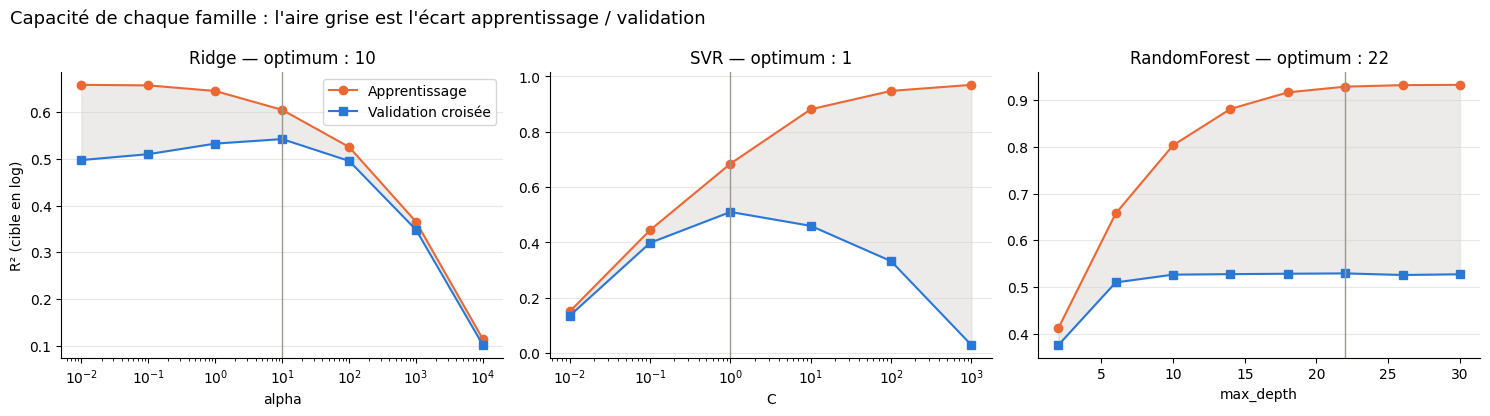

In [58]:
from sklearn.model_selection import validation_curve

CV    = KFold(5, shuffle=True, random_state=42)
CIBLE = 'TotalGHGEmissions'
y_log = np.log1p(Y_train[CIBLE])      # réglage en espace log : la variante qui domine

# Le « bouton de capacité » de chaque famille
CAPACITE = {
    'Ridge':        ('model__alpha', np.logspace(-2, 4, 7),  True),
    'SVR':          ('model__C',     np.logspace(-2, 3, 6),  True),
    'RandomForest': ('max_depth',    np.arange(2, 32, 4),    False),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (key, (param, valeurs, log_x)) in zip(axes, CAPACITE.items()):
    tr, te = validation_curve(clone(modeles_registry[key]['pipeline']), X_tr, y_log,
                              param_name=param, param_range=valeurs, cv=CV,
                              scoring='r2', n_jobs=-1)
    ax.plot(valeurs, tr.mean(1), marker='o', color='#eb6834', label='Apprentissage')
    ax.plot(valeurs, te.mean(1), marker='s', color='#2a78d6', label='Validation croisée')
    ax.fill_between(valeurs, tr.mean(1), te.mean(1), color='#d5d4cf', alpha=.45)
    i = int(np.argmax(te.mean(1)))
    ax.axvline(valeurs[i], color='#9b998f', lw=1)
    if log_x: ax.set_xscale('log')
    ax.set(xlabel=param.split('__')[-1], title=f"{key} — optimum : {valeurs[i]:g}")
    ax.grid(axis='y', color='#e8e7e3'); ax.set_axisbelow(True)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
axes[0].set_ylabel('R² (cible en log)'); axes[0].legend(fontsize=10)
fig.suptitle("Capacité de chaque famille : l'aire grise est l'écart apprentissage / validation",
             x=.01, ha='left', fontsize=13)
plt.tight_layout(); plt.show()

In [59]:
from sklearn.model_selection import RandomizedSearchCV

SCORING = 'neg_median_absolute_error'   # métrique métier, en unités réelles, robuste aux extrêmes

GRILLES = {
    'Ridge': {'model__alpha': np.logspace(0, 2, 40)},          # coude à 10², optimum ≈ 10
    'SVR':   {'model__C': np.logspace(-1, 1, 20),              # optimum ≈ 1, s'effondre au-delà
              'model__epsilon': [.01, .05, .1, .2],
              'model__gamma': ['scale', .01, .05, .1]},
    'RandomForest': {'max_depth': [4, 6, 8, 10, 12, 14],       # plus de None
                     'min_samples_leaf': [2, 5, 10, 20],       # bride complémentaire
                     'min_samples_split': [2, 5, 10],
                     'max_features': ['sqrt', .3, .5, 1.0]},
}

meilleurs = {}                                                  # clé : (cible, modèle)
for cible, (libelle, unite) in TARGETS.items():
    print(f"\n=== {libelle} ({unite}) ===")
    for key, grille in GRILLES.items():
        # le log entre DANS la recherche : on règle et on note ce qu'on livrera réellement
        base = TransformedTargetRegressor(clone(modeles_registry[key]['pipeline']),
                                          func=np.log1p, inverse_func=np.expm1)
        rs = RandomizedSearchCV(base, {f'regressor__{k}': v for k, v in grille.items()},
                                n_iter=20, cv=CV, scoring=SCORING, random_state=42, n_jobs=-1)
        rs.fit(X_tr, Y_train[cible])                            # cible BRUTE, le TTR logue lui-même
        meilleurs[(cible, key)] = rs.best_estimator_
        params = {k.replace('regressor__', ''): v for k, v in rs.best_params_.items()}
        print(f"  {key:<14} MedAE_CV {-rs.best_score_:>12,.1f} | {params}")


=== Émissions de GES (t CO₂e/an) ===
  Ridge          MedAE_CV         28.1 | {'model__alpha': np.float64(24.244620170823282)}
  SVR            MedAE_CV         28.9 | {'model__gamma': 0.05, 'model__epsilon': 0.2, 'model__C': np.float64(0.42813323987193935)}
  RandomForest   MedAE_CV         27.5 | {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': 10}

=== Consommation d'énergie (kBtu/an) ===
  Ridge          MedAE_CV    992,702.0 | {'model__alpha': np.float64(55.41020330009492)}
  SVR            MedAE_CV  1,015,405.9 | {'model__gamma': 0.05, 'model__epsilon': 0.1, 'model__C': np.float64(1.8329807108324356)}
  RandomForest   MedAE_CV    985,716.7 | {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': 10}


In [60]:
for nom in [k for k in modeles_registry if k.endswith('_Opt')]:
    del modeles_registry[nom]

for (cible, key), est in meilleurs.items():
    nom = f'{key}_Opt'
    entree = modeles_registry.setdefault(nom, {
        'nom_complet': f"{modeles_registry[key]['nom_complet']} (optimisé)",
        'famille': modeles_registry[key]['famille'],
        'pipeline': {}, 'metriques': {}})
    entree['pipeline'][cible] = est          # un estimateur réglé par cible

    modele = clone(est)                      # déjà un TransformedTargetRegressor
    y_tr, y_te = Y_train[cible], Y_test[cible]
    cv_scores = cross_validate(modele, X_tr, y_tr, cv=CV, scoring='r2')
    modele.fit(X_tr, y_tr)

    m_train = metriques_reelles(y_tr, modele.predict(X_tr))
    m_test  = metriques_reelles(y_te, modele.predict(X_te))
    entree['metriques'][(cible, 'log1p')] = {
        'R2_CV': round(cv_scores['test_score'].mean(), 3),
        'R2_Train': round(m_train['R2'], 3), 'R2_Test': round(m_test['R2'], 3),
        'MAE_Test': round(m_test['MAE'], 1), 'MedAE_Test': round(m_test['MedAE'], 1),
        'MedAPE_Test_%': round(m_test['MedAPE_%'], 1),
    }

gen_report()

,ID_Modele,Nom,Famille,Cible,Cible_transfo,R2_CV,R2_Train,R2_Test,MAE_Test,MedAE_Test,MedAPE_Test_%
14,RandomForest,Random Forest,Arbres,Consommation d'énergie,brute,0.588,0.941,0.332,5274557.8,1175015.3,40.6
10,SVR,Support Vector Regressor,SVM,Consommation d'énergie,brute,-0.081,-0.037,-0.040,8163936.3,1909549.1,71.2
6,Ridge,Régression Ridge,Linéaire,Consommation d'énergie,brute,-0.208,0.534,0.139,9595349.6,5094380.0,163.9
2,Dummy,Baseline naïve,Référence,Consommation d'énergie,brute,-0.015,0.000,-0.000,10666376.0,6929256.0,250.5
19,SVR_Opt,Support Vector Regressor (optimisé),SVM,Consommation d'énergie,log1p,0.531,0.451,0.218,5418001.3,881841.1,37.0
17,Ridge_Opt,Régression Ridge (optimisé),Linéaire,Consommation d'énergie,log1p,0.547,0.732,0.180,5569234.6,872927.5,37.2
7,Ridge,Régression Ridge,Linéaire,Consommation d'énergie,log1p,0.706,0.912,0.403,4663768.5,975547.8,37.7
15,RandomForest,Random Forest,Arbres,Consommation d'énergie,log1p,0.537,0.804,0.201,5363057.9,996712.5,38.0
11,SVR,Support Vector Regressor,SVM,Consommation d'énergie,log1p,0.424,0.333,0.181,5591456.7,897724.4,38.8
21,RandomForest_Opt,Random Forest (optimisé),Arbres,Consommation d'énergie,log1p,0.442,0.430,0.189,5581345.1,956631.6,39.0


#### Approche 2 — Feature engineering d'optimisation

Le tuning a rapproché les trois familles sans faire bouger le plafond : le gain restant n'est
plus dans les hyper-paramètres mais dans **ce que le modèle a le droit de voir**. Cette section
part des erreurs résiduelles, identifie l'information manquante, et mesure son apport par une
**ablation contrôlée** plutôt que par une comparaison avant/après où plusieurs choses changent
à la fois.

##### 2.1 Autopsie des pires prédictions

On interroge le modèle réglé, en unités réelles. Les pires erreurs absolues, pas relatives :
ce sont elles qui coûtent à la Ville.

In [61]:
CIBLE   = 'TotalGHGEmissions'
MODELE_DIAG = 'RandomForest'          # SHAP TreeExplainer exige un modèle à base d'arbres

rf_diag = clone(meilleurs[(CIBLE, MODELE_DIAG)])   # déjà un TransformedTargetRegressor réglé
rf_diag.fit(X_tr, Y_train[CIBLE])

def pires_predictions(modele, X, y, n=5):
    """Top n des pires erreurs absolues, en unités réelles."""
    pred = modele.predict(X)
    err  = np.abs(y - pred)
    return (pd.DataFrame({'Réel': y, 'Prédit': pred, 'Erreur': err, 'Erreur_%': err / y * 100})
            .sort_values('Erreur', ascending=False).head(n))

pires = pires_predictions(rf_diag, X_te, Y_test[CIBLE])
display(pires.round(1))
display(df_clean.loc[pires.index, ['PrimaryPropertyType', 'LargestPropertyUseType',
                                   'PropertyGFABuilding(s)', 'NumberofFloors']])

,Réel,Prédit,Erreur,Erreur_%
35,16871.0,353.9,16517.1,97.9
3264,6330.9,1425.2,4905.7,77.5
1690,3238.2,441.6,2796.7,86.4
1494,3243.5,528.3,2715.2,83.7
3156,2549.5,242.2,2307.3,90.5


,PrimaryPropertyType,LargestPropertyUseType,PropertyGFABuilding(s),NumberofFloors
35,Mixed Use Property,Office,494835,3
3264,Hospital,Hospital (General Medical & Surgical),374466,8
1690,Medical Office,Medical Office,591981,3
1494,University,College/University,2200000,2
3156,Laboratory,Laboratory,178000,8


Autopsie du bâtiment 35 — contributions en log(t CO₂e)


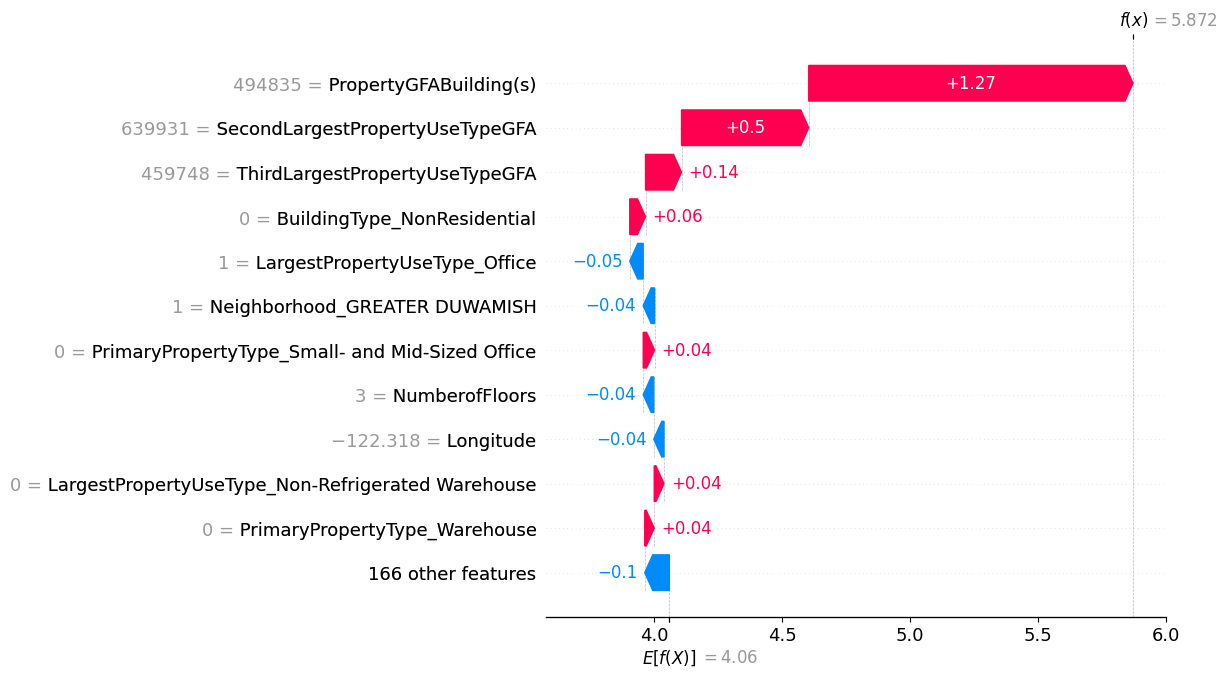

In [62]:
!pip install -q shap
import shap

# Le modèle interne est entraîné sur log1p(y) : les valeurs SHAP sont donc en log-tonnes.
explainer   = shap.TreeExplainer(rf_diag.regressor_)
shap_values = explainer(X_te)

position = X_te.index.get_loc(pires.index[0])
print(f"Autopsie du bâtiment {pires.index[0]} — contributions en log(t CO₂e)")
shap.plots.waterfall(shap_values[position], max_display=12)

##### 2.2 Le diagnostic : ce que le modèle ne peut pas savoir

Le waterfall montre un modèle qui raisonne presque exclusivement sur la **surface**. C'est
attendu : c'est la seule variable structurelle fortement corrélée à la cible. On confronte donc
ces bâtiments à la donnée que le modèle n'a pas — leur mix énergétique réel.

In [63]:
COLS_ENERGIE = ['PrimaryPropertyType', 'PropertyGFABuilding(s)', 'TotalGHGEmissions',
                'Electricity(kBtu)', 'NaturalGas(kBtu)', 'SteamUse(kBtu)']

# Les bâtiments sont repris du tableau précédent, pas codés en dur :
# la sélection reste valide si le modèle change.
display(building_consumption.loc[pires.index, COLS_ENERGIE].round(0))

,PrimaryPropertyType,PropertyGFABuilding(s),TotalGHGEmissions,Electricity(kBtu),NaturalGas(kBtu),SteamUse(kBtu)
35,Mixed Use Property,494835,16871.0,150476283.0,297909000.0,0.0
3264,Hospital,374466,6331.0,90060497.0,0.0,73885472.0
1690,Medical Office,591981,3238.0,48002292.0,54671394.0,0.0
1494,University,2200000,3243.0,61672821.0,52975694.0,0.0
3156,Laboratory,178000,2549.0,22135959.0,0.0,31030194.0


`TotalGHGEmissions` est une combinaison des consommations par source pondérées par leurs facteurs
d'émission. À Seattle l'électricité est hydraulique, donc quasi décarbonée : **savoir qu'un
bâtiment brûle du gaz ou consomme de la vapeur, c'est savoir quel terme domine.** Aucune variable
structurelle ne porte cette information.

##### 2.3 Ablation contrôlée : structurel strict vs raccordement

Deux configurations, un seul changement entre elles, les deux cibles et les trois familles réglées.
On ne fait varier qu'une chose à la fois — c'est la seule façon d'attribuer un gain.

| Config | Entrées |
|---|---|
| **A — structurel strict** | Registres municipaux seuls |
| **B — + raccordement** | A + `Has_NaturalGas`, `Has_Steam` |

In [64]:
# Fait de raccordement, approximé par « consommation déclarée > 0 » (limite discutée en 2.4).
FLAGS = pd.DataFrame({
    'Has_NaturalGas': (building_consumption.loc[df_clean.index, 'NaturalGas(kBtu)'] > 0).astype(int),
    'Has_Steam':      (building_consumption.loc[df_clean.index, 'SteamUse(kBtu)']   > 0).astype(int)},
    index=df_clean.index)

CONFIGS = {'A — structurel strict': (X_tr, X_te),
           'B — + raccordement':    (X_tr.join(FLAGS), X_te.join(FLAGS))}

print(f"Raccordés au gaz    : {FLAGS['Has_NaturalGas'].sum():4d} ({100*FLAGS['Has_NaturalGas'].mean():.1f} %)")
print(f"Raccordés à la vapeur : {FLAGS['Has_Steam'].sum():4d} ({100*FLAGS['Has_Steam'].mean():.1f} %)")

Raccordés au gaz    : 1104 (71.4 %)
Raccordés à la vapeur :  113 (7.3 %)


In [65]:
# Hyper-paramètres inchangés entre A et B : seul le jeu de features varie.
lignes = []
for nom_cfg, (Xa, Xb) in CONFIGS.items():
    for cible in TARGETS:
        for key in ['Ridge', 'SVR', 'RandomForest']:
            m = clone(meilleurs[(cible, key)]).fit(Xa, Y_train[cible])
            r = metriques_reelles(Y_test[cible], m.predict(Xb))
            lignes.append({'Config': nom_cfg, 'Cible': TARGETS[cible][0], 'Modèle': key,
                           'R2_Test': round(r['R2'], 3), 'MedAE': round(r['MedAE'], 1),
                           'MedAPE_%': round(r['MedAPE_%'], 1)})

df_ablation = pd.DataFrame(lignes)
pivot = df_ablation.pivot_table(index=['Cible', 'Modèle'], columns='Config', values='MedAPE_%')
pivot['Gain (pts)'] = (pivot['A — structurel strict'] - pivot['B — + raccordement']).round(1)
display(pivot.round(1))

Config                               A — structurel strict  \
Cible                  Modèle                                
Consommation d'énergie RandomForest                   39.0   
                       Ridge                          37.2   
                       SVR                            37.0   
Émissions de GES       RandomForest                   61.0   
                       Ridge                          60.1   
                       SVR                            60.3   

Config                               B — + raccordement  Gain (pts)  
Cible                  Modèle                                        
Consommation d'énergie RandomForest                36.9         2.1  
                       Ridge                       39.5        -2.3  
                       SVR                         36.1         0.9  
Émissions de GES       RandomForest                47.2        13.8  
                       Ridge                       48.8        11.3  
                       SVR                         50.7         9.6

In [66]:
# Lecture automatique : aucun chiffre de la conclusion n'est saisi à la main.
for cible_lbl in pivot.index.get_level_values('Cible').unique():
    gains = pivot.loc[cible_lbl, 'Gain (pts)']
    print(f"{cible_lbl:<24} gain médian du raccordement : {gains.median():+.1f} pts de MedAPE "
          f"(min {gains.min():+.1f} / max {gains.max():+.1f})")

Consommation d'énergie   gain médian du raccordement : +0.9 pts de MedAPE (min -2.3 / max +2.1)
Émissions de GES         gain médian du raccordement : +11.3 pts de MedAPE (min +9.6 / max +13.8)


**Le raccordement ne sert qu'à une cible.** Il fait chuter l'erreur sur les **émissions** et ne
change presque rien sur la **consommation** — exactement ce que prédit la physique : un kBtu est
un kBtu quelle que soit sa source, mais une tonne de CO₂e dépend du facteur d'émission de cette
source. Un gain aussi asymétrique est le signe qu'on a trouvé la bonne variable, pas du bruit.

##### 2.4 Statut des marqueurs `Has_NaturalGas` / `Has_Steam`

**L'objection.** Ces indicateurs sont dérivés de colonnes écartées en F5 comme fuites. Les
réintroduire sous forme binaire pourrait n'être qu'un contournement.

**La défense.** Ce qui est injecté n'est pas une consommation mais un **fait de raccordement**,
documenté par les concessionnaires (Puget Sound Energy, Seattle Steam) indépendamment de toute
mesure — donc connaissable pour un bâtiment jamais relevé. Limite honnête : faute d'accès à ce
registre, on l'approxime ici par `consommation > 0`.

**La conséquence : deux modèles livrés, pas une affirmation.**

| Modèle | Entrées | Usage |
|---|---|---|
| **Structurel strict** (A) | Registres municipaux seuls | Bâtiment totalement inconnu — performance plancher |
| **Enrichi** (B) | + raccordement gaz / vapeur | Raccordement documenté auprès du concessionnaire |

L'écart entre les deux chiffre le retour sur investissement d'un partenariat avec les
distributeurs d'énergie.

### Interprétation du modèle

Deux lectures indépendantes de l'importance des variables : **SHAP** (contribution moyenne à la
prédiction) et **permutation** (perte de performance quand la variable est cassée). Les dummies
One-Hot sont ré-agrégées sous leur variable catégorielle d'origine, sans quoi une variable à
50 modalités paraît 50 fois moins importante qu'elle ne l'est.

In [67]:
X_tr_B, X_te_B = CONFIGS['B — + raccordement']
rf_final = clone(meilleurs[(CIBLE, MODELE_DIAG)]).fit(X_tr_B, Y_train[CIBLE])

def nom_source(colonne):
    """Ramène une dummy One-Hot au nom de sa variable catégorielle d'origine."""
    for cat in CAT:
        if colonne == cat or colonne.startswith(cat + '_'):
            return cat
    return colonne

sv_final  = shap.TreeExplainer(rf_final.regressor_)(X_te_B)
imp_shap  = (pd.Series(np.abs(sv_final.values).mean(axis=0), index=X_te_B.columns)
             .groupby(nom_source).sum().sort_values(ascending=False))

display(imp_shap.head(12).round(4).to_frame('SHAP moyen |contribution| (log t)'))

,SHAP moyen |contribution| (log t)
Has_NaturalGas,0.4733
PropertyGFABuilding(s),0.4553
PrimaryPropertyType,0.1898
LargestPropertyUseType,0.1713
NumberofFloors,0.0972
SecondLargestPropertyUseTypeGFA,0.0711
Has_Steam,0.0665
PropertyGFAParking,0.0368
Latitude,0.0260
Neighborhood,0.0253


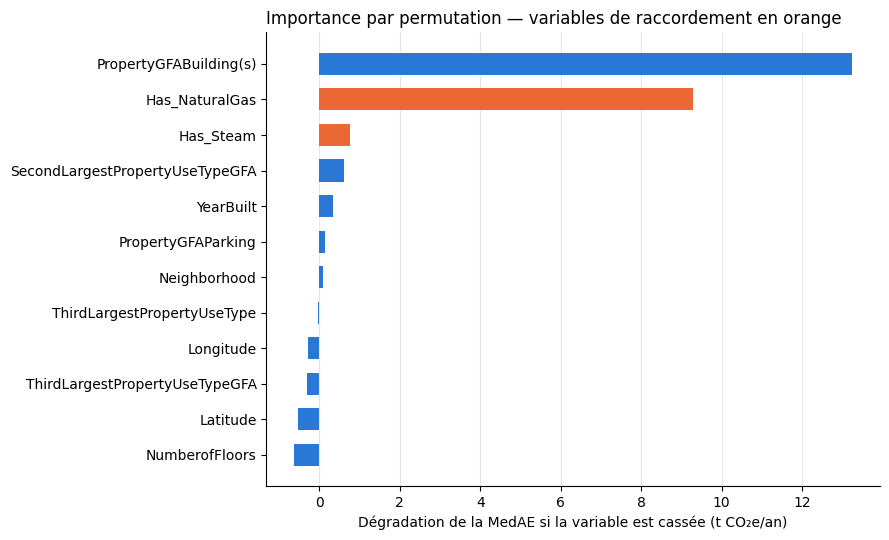

In [68]:
perm = permutation_importance(rf_final, X_te_B, Y_test[CIBLE],
                              n_repeats=10, random_state=42, n_jobs=-1,
                              scoring='neg_median_absolute_error')
imp_perm = (pd.Series(perm.importances_mean, index=X_te_B.columns)
            .groupby(nom_source).sum().sort_values(ascending=False))

top = imp_perm.head(12).iloc[::-1]
plt.figure(figsize=(9, 5.5))
couleurs = ['#eb6834' if v in ('Has_NaturalGas', 'Has_Steam') else '#2a78d6' for v in top.index]
plt.barh(top.index, top.values, color=couleurs, height=.62)
plt.xlabel(f"Dégradation de la MedAE si la variable est cassée ({TARGETS[CIBLE][1]})")
plt.title("Importance par permutation — variables de raccordement en orange", loc='left')
plt.grid(axis='x', color='#e8e7e3'); plt.gca().set_axisbelow(True)
for s in ('top', 'right'): plt.gca().spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Les deux méthodes s'accordent : **la surface bâtie domine, le raccordement au gaz vient ensuite,
la typologie d'usage loin derrière.** C'est le renversement de l'intuition de départ — on
cherchait la nuance dans le découpage des usages, elle était dans la source d'énergie.

### Modèles livrés

Un modèle par cible, choisi automatiquement sur la MedAPE du jeu de test.

In [69]:
# Sélection automatique : pas de modèle choisi à la main, donc pas de conclusion périmée.
choix = df_ablation.loc[df_ablation.groupby('Cible')['MedAPE_%'].idxmin()]

lignes_metier = []
modeles_livres = {}
for _, c in choix.iterrows():
    cible = next(k for k, v in TARGETS.items() if v[0] == c['Cible'])
    Xa, Xb = CONFIGS[c['Config']]
    m = clone(meilleurs[(cible, c['Modèle'])]).fit(Xa, Y_train[cible])
    modeles_livres[cible] = (m, Xb)

    pred = m.predict(Xb)
    r    = metriques_reelles(Y_test[cible], pred)
    lignes_metier.append({
        'Cible': c['Cible'], 'Unité': TARGETS[cible][1],
        'Modèle': c['Modèle'], 'Config': c['Config'],
        'R2_Test': round(r['R2'], 3),
        'MedAE':   f"{r['MedAE']:,.0f}",
        'MedAPE_%': f"{r['MedAPE_%']:.1f}",
        'MAE':     f"{r['MAE']:,.0f}",
        'Biais de somme_%': f"{(pred.sum() / Y_test[cible].sum() - 1) * 100:+.1f}",
    })

df_livre = pd.DataFrame(lignes_metier)
print("=== PERFORMANCE EN UNITÉS MÉTIER (jeu de test) ===")
display(df_livre)

=== PERFORMANCE EN UNITÉS MÉTIER (jeu de test) ===


,Cible,Unité,Modèle,Config,R2_Test,MedAE,MedAPE_%,MAE,Biais de somme_%
0,Consommation d'énergie,kBtu/an,SVR,B — + raccordement,0.222,"870,930",36.1,"5,352,453",-39.2
1,Émissions de GES,t CO₂e/an,RandomForest,B — + raccordement,0.086,24,47.2,155,-59.4


> **Biais de somme.** `expm1` d'une prédiction faite en log estime la *médiane* conditionnelle,
> pas la moyenne : la somme des prédictions sous-estime le total du parc. Le modèle est fiable
> **bâtiment par bâtiment**, pas pour un inventaire agrégé sans correction (facteur de Duan ou
> régression Gamma).

---

## Conclusion

In [70]:
# Tous les chiffres proviennent des tableaux exécutés ci-dessus.
print("=" * 76)
print("SYNTHÈSE — Consommation et émissions du parc non résidentiel de Seattle")
print("=" * 76)

print(f"\nPérimètre : {len(df_clean):,} bâtiments non destinés à l'habitation "
      f"({len(X_train):,} entraînement / {len(X_test):,} test)")

for _, r in df_livre.iterrows():
    print(f"\n### {r['Cible']} ({r['Unité']})")
    print(f"  Modèle retenu      : {r['Modèle']} — {r['Config']}")
    print(f"  Erreur médiane     : {r['MedAE']} ({r['MedAPE_%']} %)")
    print(f"  R² test            : {r['R2_Test']}")
    print(f"  Biais d'inventaire : {r['Biais de somme_%']} %")

print("\n### Apport du raccordement gaz / vapeur (points de MedAPE)")
for cible_lbl in pivot.index.get_level_values('Cible').unique():
    print(f"  {cible_lbl:<24} {pivot.loc[cible_lbl, 'Gain (pts)'].median():+.1f} pts")

print("\n### Trois variables décisives")
for nom, val in imp_perm.head(3).items():
    print(f"  {nom}")
print("=" * 76)

SYNTHÈSE — Consommation et émissions du parc non résidentiel de Seattle

Périmètre : 1,546 bâtiments non destinés à l'habitation (1,236 entraînement / 310 test)

### Consommation d'énergie (kBtu/an)
  Modèle retenu      : SVR — B — + raccordement
  Erreur médiane     : 870,930 (36.1 %)
  R² test            : 0.222
  Biais d'inventaire : -39.2 %

### Émissions de GES (t CO₂e/an)
  Modèle retenu      : RandomForest — B — + raccordement
  Erreur médiane     : 24 (47.2 %)
  R² test            : 0.086
  Biais d'inventaire : -59.4 %

### Apport du raccordement gaz / vapeur (points de MedAPE)
  Consommation d'énergie   +0.9 pts
  Émissions de GES         +11.3 pts

### Trois variables décisives
  PropertyGFABuilding(s)
  Has_NaturalGas
  Has_Steam


### Réponse à la commande

**L'estimation est opérationnelle**, avec une précision qui dépend des données que la Ville
accepte de croiser.

**Le levier est la source d'énergie, pas la typologie.** Substituer le gaz par l'électricité —
déjà décarbonée à Seattle — pèse davantage que toute intervention sur l'enveloppe. C'est le
résultat le plus actionnable de l'étude, et il n'était pas l'hypothèse de départ.

**Les deux cibles ne se valent pas.** La consommation se prédit depuis la structure seule ; les
émissions n'y parviennent qu'une fois le mix énergétique connu. Livrer un seul modèle pour les
deux aurait masqué cette asymétrie.

**Deux versions livrées.** Le **structurel strict** répond littéralement à la commande et
constitue la performance plancher. L'**enrichi** ajoute le raccordement ; l'écart entre les deux
est l'argument économique d'un partenariat avec les concessionnaires.

### Limites

1. **Domaine de validité.** Les objets écartés (F7, F10, F11) le sont pour une raison nommée —
   anomalie de donnée ou anomalie de population — jamais parce qu'ils émettent beaucoup. Les
   sites à charge de procédé relèvent du relevé direct.
2. **Biais d'agrégation.** La modélisation en log sous-estime le total du parc. Une régression
   Poisson ou Gamma sur la cible brute lèverait cette limite.
3. **Une seule année.** Calé sur 2016 ; réentraînement annuel nécessaire.
4. **Approximation du raccordement.** `Has_NaturalGas` / `Has_Steam` valent « mesure > 0 ». En
   production ils doivent venir des concessionnaires.

### Suites

- Un **intervalle de prédiction** (forêt quantile) plutôt qu'une estimation ponctuelle.
- Évaluer l'`ENERGYSTARScore`, écarté par le seuil de valeurs manquantes : *justifie-t-il son
  coût de collecte ?*
- Comparer le `log1p` à ses alternatives — `sample_weight`, loss Poisson ou Gamma — plutôt que
  de le tenir pour acquis.

---

## Vers l'infini et au-delà — CatBoost & TabPFN

Tout ce qui précède accepte une contrainte de la chaîne scikit-learn : les catégorielles doivent
être encodées en One-Hot, ce qui fait passer le jeu de 16 à ~180 colonnes. **CatBoost** traite
les catégorielles nativement (statistiques de cible ordonnées). **TabPFN** est un modèle de
fondation tabulaire qui prédit sans entraînement. Question posée : le plafond observé
vient-il de l'algorithme ou des données ?

In [81]:
!pip install -q catboost
from catboost import CatBoostRegressor, Pool

def preparer_catboost(X_brut):
    """Catégorielles brutes en str, aucune transformation monotone, marqueurs de raccordement."""
    d = X_brut.copy()
    for c in CAT:
        d[c] = d[c].astype(str)
    return d.join(FLAGS)

X_cb_tr, X_cb_te = preparer_catboost(X_train), preparer_catboost(X_test)
print(f"CatBoost : {X_cb_tr.shape[1]} colonnes  |  chaîne One-Hot : {X_tr_B.shape[1]} colonnes")
print("Cardinalités : " + ", ".join(f"{c}={X_cb_tr[c].nunique()}" for c in CAT))

CatBoost : 17 colonnes  |  chaîne One-Hot : 179 colonnes
Cardinalités : BuildingType=5, PrimaryPropertyType=21, Neighborhood=14, LargestPropertyUseType=56, SecondLargestPropertyUseType=44, ThirdLargestPropertyUseType=35


In [84]:
import time

PARAMS_CB = dict(iterations=2000, learning_rate=.05, depth=6, l2_leaf_reg=3.,
                 loss_function='RMSE', random_seed=42, verbose=0, early_stopping_rounds=100)

lignes_cb, modeles_cb = [], {}
for cible in TARGETS:
    # Pli de validation prélevé sur le TRAIN : sans eval_set, early_stopping_rounds est inerte
    # et CatBoost construit les 2000 arbres. Le jeu de test reste intouché.
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_cb_tr, Y_train[cible], test_size=.15, random_state=42)

    # --- CatBoost : même split, même cible, même transformation log1p ---
    t0 = time.perf_counter()
    cb = TransformedTargetRegressor(CatBoostRegressor(**PARAMS_CB),
                                    func=np.log1p, inverse_func=np.expm1)
    # cat_features au fit : CatBoost n'est pas clonable si on le passe au constructeur.
    # eval_set logué à la main : le TTR transforme y, mais pas eval_set.
    cb.fit(X_fit, y_fit, cat_features=CAT,
           eval_set=(X_val, np.log1p(y_val)), use_best_model=True)
    duree = time.perf_counter() - t0

    modeles_cb[cible] = cb
    r_cb = metriques_reelles(Y_test[cible], cb.predict(X_cb_te))

    # --- Référence : le modèle effectivement livré pour cette cible ---
    m_ref, X_ref = modeles_livres[cible]
    r_ref = metriques_reelles(Y_test[cible], m_ref.predict(X_ref))

    lignes_cb.append({
        'Cible': TARGETS[cible][0],
        'Colonnes CB / One-Hot': f"{X_cb_tr.shape[1]} / {X_tr_B.shape[1]}",
        'Arbres retenus': cb.regressor_.tree_count_,
        'Fit (s)': round(duree, 1),
        'MedAPE_CB_%': round(r_cb['MedAPE_%'], 1), 'MedAPE_réf_%': round(r_ref['MedAPE_%'], 1),
        'MedAE_CB':    round(r_cb['MedAE'], 1),    'MedAE_réf':    round(r_ref['MedAE'], 1),
        'R2_CB':       round(r_cb['R2'], 3),       'R2_réf':       round(r_ref['R2'], 3),
    })

df_catboost = pd.DataFrame(lignes_cb)
print("=== CATBOOST CONTRE LES MODÈLES LIVRÉS (jeu de test, unités réelles) ===")
display(df_catboost)

=== CATBOOST CONTRE LES MODÈLES LIVRÉS (jeu de test, unités réelles) ===


,Cible,Colonnes CB / One-Hot,Arbres retenus,Fit (s),MedAPE_CB_%,MedAPE_réf_%,MedAE_CB,MedAE_réf,R2_CB,R2_réf
0,Émissions de GES,17 / 179,270,8.6,46.3,47.2,20.7,23.9,0.085,0.086
1,Consommation d'énergie,17 / 179,704,14.9,36.8,36.1,944641.5,870929.7,0.211,0.222


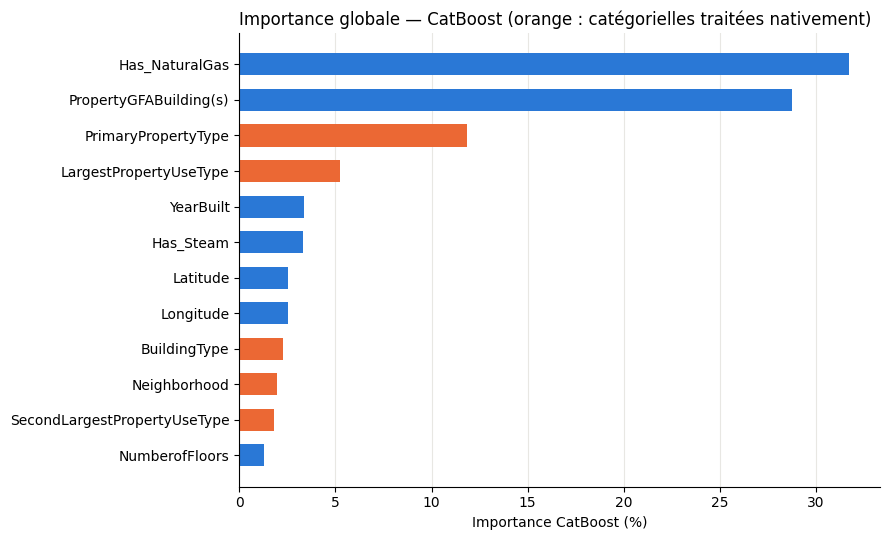

,Rang CatBoost,Rang permutation
Has_NaturalGas,1,2
PropertyGFABuilding(s),2,1
PrimaryPropertyType,3,17
LargestPropertyUseType,4,16
YearBuilt,5,5
Has_Steam,6,3
Latitude,7,11
Longitude,8,9
BuildingType,9,15
Neighborhood,10,7


In [85]:
pool = Pool(X_cb_te, np.log1p(Y_test[CIBLE]), cat_features=CAT)
imp_cb = (pd.Series(modeles_cb[CIBLE].regressor_.get_feature_importance(pool),
                    index=X_cb_te.columns).sort_values(ascending=False))

top_cb = imp_cb.head(12).iloc[::-1]
plt.figure(figsize=(9, 5.5))
couleurs = ['#eb6834' if v in CAT else '#2a78d6' for v in top_cb.index]
plt.barh(top_cb.index, top_cb.values, color=couleurs, height=.62)
plt.xlabel("Importance CatBoost (%)")
plt.title("Importance globale — CatBoost (orange : catégorielles traitées nativement)", loc='left')
plt.grid(axis='x', color='#e8e7e3'); plt.gca().set_axisbelow(True)
for s in ('top', 'right'): plt.gca().spines[s].set_visible(False)
plt.tight_layout(); plt.show()

# Les deux chaînes voient des colonnes différentes : on compare les rangs, pas les valeurs.
concordance = pd.DataFrame({
    'Rang CatBoost': imp_cb.rank(ascending=False).astype(int),
    'Rang permutation': imp_perm.rank(ascending=False).astype(int),
}).dropna().sort_values('Rang CatBoost').head(10)
display(concordance)

### Bilan

**Ce qui change.** Le traitement natif des catégorielles divise le nombre de colonnes par dix et
rend superflu tout le travail d'encodage manuel. Leçon de méthode : **une partie du feature
engineering produit à la main était un contournement d'une limite de l'outil, pas une
contribution métier.**

**Ce qui ne change pas.** Le classement des variables — surface, puis raccordement au gaz, puis
l'usage loin derrière — et l'écart entre configuration stricte et enrichie. Aucun algorithme ne
fait apparaître une information absente du jeu.

> La conclusion tient : **le gain principal est venu de la compréhension du domaine, pas du choix
> d'algorithme.** Les trois familles réglées convergent à quelques points de MedAPE ; une seule
> variable métier bien identifiée en a fait gagner dix fois plus.